<a href="https://colab.research.google.com/github/dayanakumar-IT/R26-DS-010-Intelligent-Care-Support/blob/sign-tutoring-ai/SignLanguage_Preprocessing_Dataset_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IT22289384 - Kaushalya Nagenthraraja

PROJECT OVERVIEW

This project develops an AI-assisted sign language learning and evaluation system focused on caregiver communication.

The system combines:

1. Computer Vision
   - MediaPipe hand and pose landmark extraction

2. Deep Learning Models
   - BiLSTM
   - GRU
   - ST-GCN

3. Gesture Evaluation
   - Dynamic Time Warping (DTW)
   - Speed-tolerant gesture comparison

4. Explainable AI Feedback
   - Motion analysis
   - Hand position analysis
   - Corrective feedback generation

5. Future Enhancements
   - Adaptive learning support
   - Personalized practice
   - Real-time 3D avatar guidance

RESEARCH OBJECTIVES

- Identify caregiving-related sign language gestures
- Capture and evaluate performed signs
- Distinguish gesture accuracy from execution speed
- Generate interpretable corrective feedback
- Support adaptive and personalized learning
- Evaluate system accuracy and usability

CURRENT PIPELINE

Dataset
   ↓
MediaPipe Landmark Extraction
   ↓
Stabilization and Normalization
   ↓
Feature Engineering
   ↓
Deep Learning Recognition
   ↓
DTW Gesture Evaluation
   ↓
Explainable Feedback Generation

In [ ]:
# ============================================================
# SECTION 0: STABLE FRESH ENVIRONMENT INITIALIZATION
# ============================================================

# Install MediaPipe only
!pip install -q mediapipe

# Imports
import os
import cv2
import numpy as np
import pandas as pd
import mediapipe as mp

from sklearn.model_selection import train_test_split

print("=" * 70)
print("ENVIRONMENT VERIFICATION")
print("=" * 70)

print("OpenCV version:", cv2.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("MediaPipe version:", mp.__version__)

print("\nAll core packages imported successfully.")
print("=" * 70)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 97.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 7.6 MB/s eta 0:00:00
ENVIRONMENT VERIFICATION
OpenCV version: 4.13.0
NumPy version: 2.0.2
Pandas version: 2.2.2
MediaPipe version: 0.10.35

All core packages imported successfully.


# Google Drive Mounting and Dataset Folder Setup

### This connects Colab to your Google Drive, sets the correct dataset root folder, creates output folders for preprocessed landmarks, and checks whether your dataset path exists before continuing.

In [ ]:
# ============================================================
# SECTION 2: GOOGLE DRIVE MOUNTING AND DATASET FOLDER SETUP
# ============================================================

from google.colab import drive
from pathlib import Path
import os

drive.mount('/content/drive')

BASE_DIR = Path('/content/drive/MyDrive/SignLanguage_Final_DS')

METADATA_DIR = BASE_DIR / 'metadata'
PREPROCESSED_DIR = BASE_DIR / 'preprocessed_landmarks'
MODEL_SAVE_DIR = BASE_DIR / 'models'

METADATA_DIR.mkdir(parents=True, exist_ok=True)
PREPROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("GOOGLE DRIVE AND DATASET PATH SETUP")
print("=" * 70)

print("Base dataset folder:", BASE_DIR)
print("Metadata folder:", METADATA_DIR)
print("Preprocessed landmarks folder:", PREPROCESSED_DIR)
print("Model save folder:", MODEL_SAVE_DIR)

if BASE_DIR.exists():
    print("\nDataset folder found.")
else:
    print("\nERROR: Dataset folder not found. Check BASE_DIR path.")

print("=" * 70)

Mounted at /content/drive
GOOGLE DRIVE AND DATASET PATH SETUP
Base dataset folder: /content/drive/MyDrive/SignLanguage_Final_DS
Metadata folder: /content/drive/MyDrive/SignLanguage_Final_DS/metadata
Preprocessed landmarks folder: /content/drive/MyDrive/SignLanguage_Final_DS/preprocessed_landmarks
Model save folder: /content/drive/MyDrive/SignLanguage_Final_DS/models

Dataset folder found.


# Dataset Structure Verification and Video Count Analysis

In [ ]:
# ============================================================
# SECTION 3: DATASET STRUCTURE VERIFICATION AND VIDEO ANALYSIS
# ============================================================

from pathlib import Path
import pandas as pd

IGNORE_DIRS = {
    'scripts',
    'logs',
    'backup',
    'raw_videos',
    'videos',
    'ASL_Citizen',
    'metadata',
    'models',
    'models_v2',
    'preprocessed_landmarks',
    'preprocessed_data_final'
}

dataset_rows = []
empty_folders = []

print("=" * 80)
print("FULL DATASET ANALYSIS")
print("=" * 80)

for category_dir in sorted(BASE_DIR.iterdir()):

    if not category_dir.is_dir():
        continue

    if category_dir.name in IGNORE_DIRS:
        continue

    print(f"\n{category_dir.name}")

    for sign_dir in sorted(category_dir.iterdir()):

        if not sign_dir.is_dir():
            continue

        video_files = sorted(list(sign_dir.glob("*.mp4")))
        video_count = len(video_files)

        print(f"  {sign_dir.name:<15} -> {video_count} videos")

        if video_count == 0:
            empty_folders.append(str(sign_dir))

        for video_path in video_files:
            dataset_rows.append({
                "category": category_dir.name,
                "label": sign_dir.name,
                "video_path": str(video_path),
                "filename": video_path.name
            })

df = pd.DataFrame(dataset_rows)

print("\n" + "=" * 80)
print("SUMMARY")
print("=" * 80)

print(f"Total videos found: {len(df)}")
print(f"Total categories found: {df['category'].nunique()}")
print(f"Total sign classes found: {df['label'].nunique()}")

class_counts = df["label"].value_counts().sort_values()

print("\nLowest sample classes:")
display(class_counts.head(10))

print("\nHighest sample classes:")
display(class_counts.tail(10))

print("\nEmpty folders:")
if len(empty_folders) == 0:
    print("No empty folders found.")
else:
    for folder in empty_folders:
        print(folder)

metadata_csv_path = METADATA_DIR / "dataset_metadata.csv"
df.to_csv(metadata_csv_path, index=False)

print("\nMetadata CSV saved to:")
print(metadata_csv_path)

print("=" * 80)
print("Dataset verification completed successfully.")
print("=" * 80)

FULL DATASET ANALYSIS

Body_Parts_Organized
  arm             -> 93 videos
  back            -> 34 videos
  ear             -> 34 videos
  head            -> 35 videos
  mouth           -> 33 videos
  nose            -> 35 videos
  stomach         -> 35 videos

Daily_Actions_Organized
  close           -> 36 videos
  give            -> 36 videos
  open            -> 34 videos
  sit             -> 35 videos
  sleep           -> 34 videos
  stand           -> 61 videos
  take            -> 35 videos
  walk            -> 66 videos

Emergency_Organized
  call            -> 64 videos
  come            -> 34 videos
  danger          -> 33 videos
  doctor          -> 65 videos
  fire            -> 32 videos
  go              -> 37 videos
  help            -> 36 videos
  hospital        -> 67 videos
  hot             -> 38 videos
  hurt            -> 32 videos
  stop            -> 34 videos
  wait            -> 36 videos

Emotions_Responses_Organized
  angry           -> 36 videos
  comfortabl

,count
label,
excuse,30
hurt,32
fire,32
meet,33
dizzy,33
me,33
mouth,33
danger,33
sorry,33



Highest sample classes:


,count
label,
welcome,62
milk,63
call,64
doctor,65
walk,66
eat,66
how,67
drink,67
hospital,67



Empty folders:
No empty folders found.

Metadata CSV saved to:
/content/drive/MyDrive/SignLanguage_Final_DS/metadata/dataset_metadata.csv
Dataset verification completed successfully.


# Stratified Train / Validation / Test Split

### This splits videos at the video level, not frame level, so the same video cannot appear in multiple sets. Stratification keeps all 66 sign classes fairly balanced across train, validation, and test.

In [ ]:
# ============================================================
# SECTION 4: STRATIFIED TRAIN / VALIDATION / TEST SPLIT
# ============================================================

import pandas as pd
from sklearn.model_selection import train_test_split

# Load metadata from Section 3
metadata_csv_path = METADATA_DIR / "dataset_metadata.csv"
df = pd.read_csv(metadata_csv_path)

print("=" * 80)
print("TRAIN / VALIDATION / TEST SPLIT")
print("=" * 80)

print("Total videos:", len(df))
print("Total classes:", df["label"].nunique())

# ------------------------------------------------------------
# STEP 1: TRAIN vs TEMP SPLIT
# 70% train
# 30% temporary
# ------------------------------------------------------------

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["label"],
    shuffle=True
)

# ------------------------------------------------------------
# STEP 2: VALIDATION vs TEST SPLIT
# 15% validation
# 15% test
# ------------------------------------------------------------

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"],
    shuffle=True
)

# Reset indices
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# Add split labels
train_df["split"] = "train"
val_df["split"] = "val"
test_df["split"] = "test"

# ------------------------------------------------------------
# SAVE SPLITS
# ------------------------------------------------------------

train_csv_path = METADATA_DIR / "train_metadata.csv"
val_csv_path = METADATA_DIR / "val_metadata.csv"
test_csv_path = METADATA_DIR / "test_metadata.csv"

train_df.to_csv(train_csv_path, index=False)
val_df.to_csv(val_csv_path, index=False)
test_df.to_csv(test_csv_path, index=False)

# Combined split file
split_df = pd.concat([train_df, val_df, test_df], axis=0)

split_csv_path = METADATA_DIR / "dataset_split_metadata.csv"
split_df.to_csv(split_csv_path, index=False)

# ------------------------------------------------------------
# PRINT SUMMARY
# ------------------------------------------------------------

print("\nSplit sizes:")
print(f"Train: {len(train_df)}")
print(f"Validation: {len(val_df)}")
print(f"Test: {len(test_df)}")

print("\nPercentage split:")
print(f"Train: {len(train_df)/len(df)*100:.2f}%")
print(f"Validation: {len(val_df)/len(df)*100:.2f}%")
print(f"Test: {len(test_df)/len(df)*100:.2f}%")

# ------------------------------------------------------------
# VERIFY CLASS DISTRIBUTION
# ------------------------------------------------------------

print("\nClass distribution verification:")

print("\nTrain classes:",
      train_df["label"].nunique())

print("Validation classes:",
      val_df["label"].nunique())

print("Test classes:",
      test_df["label"].nunique())

# Minimum samples per class
print("\nMinimum samples per class:")

print("Train:",
      train_df["label"].value_counts().min())

print("Validation:",
      val_df["label"].value_counts().min())

print("Test:",
      test_df["label"].value_counts().min())

# ------------------------------------------------------------
# SAVE COMPLETE
# ------------------------------------------------------------

print("\nSaved files:")

print(train_csv_path)
print(val_csv_path)
print(test_csv_path)
print(split_csv_path)

print("=" * 80)
print("Stratified split completed successfully.")
print("=" * 80)

TRAIN / VALIDATION / TEST SPLIT
Total videos: 2696
Total classes: 66

Split sizes:
Train: 1887
Validation: 404
Test: 405

Percentage split:
Train: 69.99%
Validation: 14.99%
Test: 15.02%

Class distribution verification:

Train classes: 66
Validation classes: 66
Test classes: 66

Minimum samples per class:
Train: 21
Validation: 5
Test: 4

Saved files:
/content/drive/MyDrive/SignLanguage_Final_DS/metadata/train_metadata.csv
/content/drive/MyDrive/SignLanguage_Final_DS/metadata/val_metadata.csv
/content/drive/MyDrive/SignLanguage_Final_DS/metadata/test_metadata.csv
/content/drive/MyDrive/SignLanguage_Final_DS/metadata/dataset_split_metadata.csv
Stratified split completed successfully.


# Label Encoding and Label Mapping Creation

###Neural networks cannot train directly on text labels. This step converts sign words into integer IDs and saves the mapping for future inference and evaluation.

In [ ]:
# ============================================================
# SECTION 5: LABEL ENCODING AND LABEL MAPPING CREATION
# ============================================================

import pandas as pd
import json
from sklearn.preprocessing import LabelEncoder

print("=" * 80)
print("LABEL ENCODING")
print("=" * 80)

# ------------------------------------------------------------
# LOAD SPLIT METADATA FILES
# ------------------------------------------------------------

train_csv_path = METADATA_DIR / "train_metadata.csv"
val_csv_path = METADATA_DIR / "val_metadata.csv"
test_csv_path = METADATA_DIR / "test_metadata.csv"

train_df = pd.read_csv(train_csv_path)
val_df = pd.read_csv(val_csv_path)
test_df = pd.read_csv(test_csv_path)

# ------------------------------------------------------------
# CREATE LABEL ENCODER
# ------------------------------------------------------------

label_encoder = LabelEncoder()

# Fit ONLY on training labels
label_encoder.fit(train_df["label"])

# Encode labels
train_df["label_id"] = label_encoder.transform(train_df["label"])
val_df["label_id"] = label_encoder.transform(val_df["label"])
test_df["label_id"] = label_encoder.transform(test_df["label"])

# ------------------------------------------------------------
# CREATE LABEL MAPPINGS
# ------------------------------------------------------------

label_to_id = {
    label: int(idx)
    for idx, label in enumerate(label_encoder.classes_)
}

id_to_label = {
    int(idx): label
    for idx, label in enumerate(label_encoder.classes_)
}

# ------------------------------------------------------------
# PRINT SAMPLE MAPPINGS
# ------------------------------------------------------------

print("\nSample label mappings:")

for i, (label, idx) in enumerate(label_to_id.items()):

    print(f"{label:<15} -> {idx}")

    if i >= 14:
        break

print(f"\nTotal encoded classes: {len(label_to_id)}")

# ------------------------------------------------------------
# SAVE ENCODED CSV FILES
# ------------------------------------------------------------

encoded_train_path = METADATA_DIR / "train_metadata_encoded.csv"
encoded_val_path = METADATA_DIR / "val_metadata_encoded.csv"
encoded_test_path = METADATA_DIR / "test_metadata_encoded.csv"

train_df.to_csv(encoded_train_path, index=False)
val_df.to_csv(encoded_val_path, index=False)
test_df.to_csv(encoded_test_path, index=False)

# ------------------------------------------------------------
# SAVE LABEL MAPPING JSON FILES
# ------------------------------------------------------------

label_to_id_path = METADATA_DIR / "label_to_id.json"
id_to_label_path = METADATA_DIR / "id_to_label.json"

with open(label_to_id_path, "w") as f:
    json.dump(label_to_id, f, indent=4)

with open(id_to_label_path, "w") as f:
    json.dump(id_to_label, f, indent=4)

# ------------------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------------------

print("\nEncoded metadata files saved:")

print(encoded_train_path)
print(encoded_val_path)
print(encoded_test_path)

print("\nLabel mapping files saved:")

print(label_to_id_path)
print(id_to_label_path)

print("=" * 80)
print("Label encoding completed successfully.")
print("=" * 80)

LABEL ENCODING

Sample label mappings:
afternoon       -> 0
angry           -> 1
arm             -> 2
back            -> 3
bread           -> 4
call            -> 5
close           -> 6
coffee          -> 7
come            -> 8
comfortable     -> 9
confused        -> 10
cough           -> 11
danger          -> 12
dizzy           -> 13
doctor          -> 14

Total encoded classes: 66

Encoded metadata files saved:
/content/drive/MyDrive/SignLanguage_Final_DS/metadata/train_metadata_encoded.csv
/content/drive/MyDrive/SignLanguage_Final_DS/metadata/val_metadata_encoded.csv
/content/drive/MyDrive/SignLanguage_Final_DS/metadata/test_metadata_encoded.csv

Label mapping files saved:
/content/drive/MyDrive/SignLanguage_Final_DS/metadata/label_to_id.json
/content/drive/MyDrive/SignLanguage_Final_DS/metadata/id_to_label.json
Label encoding completed successfully.


In [ ]:
# ============================================================
# SECTION 6: DOWNLOAD MEDIAPIPE TASK MODELS
# ============================================================

from pathlib import Path
import urllib.request

print("=" * 80)
print("DOWNLOADING MEDIAPIPE TASK MODELS")
print("=" * 80)

TASK_MODEL_DIR = BASE_DIR / "mediapipe_task_models"
TASK_MODEL_DIR.mkdir(parents=True, exist_ok=True)

HAND_MODEL_PATH = TASK_MODEL_DIR / "hand_landmarker.task"
POSE_MODEL_PATH = TASK_MODEL_DIR / "pose_landmarker_heavy.task"

hand_model_url = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"
pose_model_url = "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/1/pose_landmarker_heavy.task"

def download_file(url, output_path):
    if output_path.exists():
        print(f"Already exists: {output_path.name}")
    else:
        print(f"Downloading: {output_path.name}")
        urllib.request.urlretrieve(url, output_path)
        print(f"Saved: {output_path}")

download_file(hand_model_url, HAND_MODEL_PATH)
download_file(pose_model_url, POSE_MODEL_PATH)

print("\nModel files:")
print("Hand model:", HAND_MODEL_PATH)
print("Pose model:", POSE_MODEL_PATH)

print("=" * 80)
print("MediaPipe task models ready.")
print("=" * 80)

DOWNLOADING MEDIAPIPE TASK MODELS
Already exists: hand_landmarker.task
Already exists: pose_landmarker_heavy.task

Model files:
Hand model: /content/drive/MyDrive/SignLanguage_Final_DS/mediapipe_task_models/hand_landmarker.task
Pose model: /content/drive/MyDrive/SignLanguage_Final_DS/mediapipe_task_models/pose_landmarker_heavy.task
MediaPipe task models ready.


# Test MediaPipe Landmark Extraction on One Video

### Before processing all 2696 videos, this checks whether one video can be read correctly and whether MediaPipe can extract pose + hand landmarks into the expected feature shape.

In [ ]:
# ============================================================
# SECTION 7: TEST MEDIAPIPE LANDMARK EXTRACTION ON ONE VIDEO
# ============================================================

import cv2
import numpy as np
import pandas as pd
import mediapipe as mp

from mediapipe.tasks import python
from mediapipe.tasks.python import vision

print("=" * 80)
print("TEST LANDMARK EXTRACTION ON ONE VIDEO")
print("=" * 80)

# ------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------

TARGET_FRAMES = 40
FEATURE_SIZE = 258

train_csv_path = METADATA_DIR / "train_metadata_encoded.csv"
train_df = pd.read_csv(train_csv_path)

sample_video_path = train_df.iloc[0]["video_path"]
sample_label = train_df.iloc[0]["label"]

print("Sample video:", sample_video_path)
print("Sample label:", sample_label)

# ------------------------------------------------------------
# CREATE MEDIAPIPE TASK DETECTORS
# ------------------------------------------------------------

hand_base_options = python.BaseOptions(model_asset_path=str(HAND_MODEL_PATH))
pose_base_options = python.BaseOptions(model_asset_path=str(POSE_MODEL_PATH))

hand_options = vision.HandLandmarkerOptions(
    base_options=hand_base_options,
    running_mode=vision.RunningMode.IMAGE,
    num_hands=2,
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5,
    min_tracking_confidence=0.5
)

pose_options = vision.PoseLandmarkerOptions(
    base_options=pose_base_options,
    running_mode=vision.RunningMode.IMAGE,
    min_pose_detection_confidence=0.5,
    min_pose_presence_confidence=0.5,
    min_tracking_confidence=0.5
)

hand_detector = vision.HandLandmarker.create_from_options(hand_options)
pose_detector = vision.PoseLandmarker.create_from_options(pose_options)

# ------------------------------------------------------------
# HELPER FUNCTIONS
# ------------------------------------------------------------

def extract_frame_features(frame):
    """
    Extract pose + left hand + right hand landmarks from one frame.
    Output shape: (258,)
    """

    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)

    pose_result = pose_detector.detect(mp_image)
    hand_result = hand_detector.detect(mp_image)

    features = []

    # Pose: 33 landmarks x 4 values = 132
    if pose_result.pose_landmarks:
        pose_landmarks = pose_result.pose_landmarks[0]

        for lm in pose_landmarks:
            features.extend([lm.x, lm.y, lm.z, lm.visibility])
    else:
        features.extend([0.0] * 33 * 4)

    # Hands: prepare empty left/right
    left_hand = [0.0] * 21 * 3
    right_hand = [0.0] * 21 * 3

    if hand_result.hand_landmarks and hand_result.handedness:
        for hand_landmarks, handedness in zip(
            hand_result.hand_landmarks,
            hand_result.handedness
        ):
            hand_label = handedness[0].category_name

            hand_features = []

            for lm in hand_landmarks:
                hand_features.extend([lm.x, lm.y, lm.z])

            if hand_label == "Left":
                left_hand = hand_features
            elif hand_label == "Right":
                right_hand = hand_features

    features.extend(left_hand)
    features.extend(right_hand)

    return np.array(features, dtype=np.float32)


def resize_sequence(sequence, target_frames=40, feature_size=258):
    """
    Converts video landmark sequence to fixed number of frames.
    """

    sequence = np.array(sequence, dtype=np.float32)

    if len(sequence) == 0:
        return np.zeros((target_frames, feature_size), dtype=np.float32)

    if len(sequence) == target_frames:
        return sequence

    if len(sequence) > target_frames:
        indices = np.linspace(0, len(sequence) - 1, target_frames).astype(int)
        return sequence[indices]

    padding_needed = target_frames - len(sequence)
    padding = np.repeat(sequence[-1][np.newaxis, :], padding_needed, axis=0)

    return np.vstack([sequence, padding])


def extract_video_landmarks(video_path):
    """
    Extract fixed-length landmark sequence from one video.
    """

    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")

    sequence = []
    total_frames_read = 0

    while True:
        success, frame = cap.read()

        if not success:
            break

        total_frames_read += 1
        frame_features = extract_frame_features(frame)
        sequence.append(frame_features)

    cap.release()

    fixed_sequence = resize_sequence(
        sequence,
        target_frames=TARGET_FRAMES,
        feature_size=FEATURE_SIZE
    )

    return fixed_sequence, total_frames_read


# ------------------------------------------------------------
# RUN TEST EXTRACTION
# ------------------------------------------------------------

sample_features, total_frames_read = extract_video_landmarks(sample_video_path)

print("\nExtraction results:")
print("Frames read from video:", total_frames_read)
print("Fixed sequence shape:", sample_features.shape)
print("Expected shape:", (TARGET_FRAMES, FEATURE_SIZE))

if sample_features.shape == (TARGET_FRAMES, FEATURE_SIZE):
    print("\nLandmark extraction test PASSED.")
else:
    print("\nLandmark extraction test FAILED.")

# Save test output
test_output_path = PREPROCESSED_DIR / "sample_landmark_test.npy"
np.save(test_output_path, sample_features)

print("\nSample landmark file saved to:")
print(test_output_path)

# Close detectors
hand_detector.close()
pose_detector.close()

print("=" * 80)
print("Single-video landmark extraction test completed.")
print("=" * 80)

TEST LANDMARK EXTRACTION ON ONE VIDEO
Sample video: /content/drive/MyDrive/SignLanguage_Final_DS/Food_Drink_Organized/hungry/asl_citizen_019.mp4
Sample label: hungry

Extraction results:
Frames read from video: 62
Fixed sequence shape: (40, 258)
Expected shape: (40, 258)

Landmark extraction test PASSED.

Sample landmark file saved to:
/content/drive/MyDrive/SignLanguage_Final_DS/preprocessed_landmarks/sample_landmark_test.npy
Single-video landmark extraction test completed.


# Define Reusable Landmark Extraction Functions


In [ ]:
# ============================================================
# SECTION 8A: DEFINE REUSABLE LANDMARK EXTRACTION FUNCTIONS
# ============================================================

import cv2
import numpy as np
import pandas as pd
import mediapipe as mp
from pathlib import Path
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

TARGET_FRAMES = 40
FEATURE_SIZE = 258

print("=" * 80)
print("DEFINING LANDMARK EXTRACTION FUNCTIONS")
print("=" * 80)

# ------------------------------------------------------------
# CREATE MEDIAPIPE DETECTORS
# ------------------------------------------------------------

hand_base_options = python.BaseOptions(model_asset_path=str(HAND_MODEL_PATH))
pose_base_options = python.BaseOptions(model_asset_path=str(POSE_MODEL_PATH))

hand_options = vision.HandLandmarkerOptions(
    base_options=hand_base_options,
    running_mode=vision.RunningMode.IMAGE,
    num_hands=2,
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5,
    min_tracking_confidence=0.5
)

pose_options = vision.PoseLandmarkerOptions(
    base_options=pose_base_options,
    running_mode=vision.RunningMode.IMAGE,
    min_pose_detection_confidence=0.5,
    min_pose_presence_confidence=0.5,
    min_tracking_confidence=0.5
)

hand_detector = vision.HandLandmarker.create_from_options(hand_options)
pose_detector = vision.PoseLandmarker.create_from_options(pose_options)

print("MediaPipe hand and pose detectors created.")

# ------------------------------------------------------------
# HELPER FUNCTIONS
# ------------------------------------------------------------

def safe_filename(video_path):
    path = Path(video_path)
    parent = path.parent.name
    stem = path.stem
    return f"{parent}_{stem}.npy"


def extract_frame_features(frame):
    """
    Extract pose + left hand + right hand features from one frame.

    Output shape:
    258 features per frame
    """

    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)

    pose_result = pose_detector.detect(mp_image)
    hand_result = hand_detector.detect(mp_image)

    features = []

    # Pose: 33 landmarks x 4 values = 132
    if pose_result.pose_landmarks:
        for lm in pose_result.pose_landmarks[0]:
            features.extend([lm.x, lm.y, lm.z, lm.visibility])
    else:
        features.extend([0.0] * 33 * 4)

    # Hands: 21 landmarks x 3 values each
    left_hand = [0.0] * 21 * 3
    right_hand = [0.0] * 21 * 3

    if hand_result.hand_landmarks and hand_result.handedness:
        for hand_landmarks, handedness in zip(
            hand_result.hand_landmarks,
            hand_result.handedness
        ):
            hand_label = handedness[0].category_name
            hand_features = []

            for lm in hand_landmarks:
                hand_features.extend([lm.x, lm.y, lm.z])

            if hand_label == "Left":
                left_hand = hand_features
            elif hand_label == "Right":
                right_hand = hand_features

    features.extend(left_hand)
    features.extend(right_hand)

    return np.array(features, dtype=np.float32)


def resize_sequence(sequence, target_frames=TARGET_FRAMES, feature_size=FEATURE_SIZE):
    """
    Convert variable-length video sequence into fixed length.
    """

    sequence = np.array(sequence, dtype=np.float32)

    if len(sequence) == 0:
        return np.zeros((target_frames, feature_size), dtype=np.float32)

    if len(sequence) == target_frames:
        return sequence

    if len(sequence) > target_frames:
        indices = np.linspace(0, len(sequence) - 1, target_frames).astype(int)
        return sequence[indices]

    padding_needed = target_frames - len(sequence)
    padding = np.repeat(sequence[-1][np.newaxis, :], padding_needed, axis=0)

    return np.vstack([sequence, padding])


def extract_video_landmarks(video_path):
    """
    Extract fixed-length landmark features from one video.

    Output shape:
    (40, 258)
    """

    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")

    sequence = []
    total_frames_read = 0

    while True:
        success, frame = cap.read()

        if not success:
            break

        total_frames_read += 1
        frame_features = extract_frame_features(frame)
        sequence.append(frame_features)

    cap.release()

    fixed_sequence = resize_sequence(sequence)

    return fixed_sequence, total_frames_read


print("Landmark extraction functions are ready.")
print("=" * 80)

DEFINING LANDMARK EXTRACTION FUNCTIONS
MediaPipe hand and pose detectors created.
Landmark extraction functions are ready.


# Extract Landmarks for a Small Test Batch

In [ ]:
# ============================================================
# SECTION 8B: EXTRACT LANDMARKS FOR A SMALL TEST BATCH
# ============================================================

import pandas as pd
import numpy as np
from tqdm import tqdm

print("=" * 80)
print("SMALL BATCH LANDMARK EXTRACTION TEST")
print("=" * 80)

train_df = pd.read_csv(METADATA_DIR / "train_metadata_encoded.csv")

TEST_BATCH_DIR = PREPROCESSED_DIR / "test_batch"
TEST_BATCH_DIR.mkdir(parents=True, exist_ok=True)

# Take 10 sample videos from different classes where possible
sample_df = (
    train_df
    .groupby("label", group_keys=False)
    .head(1)
    .head(10)
    .reset_index(drop=True)
)

print("Number of test videos:", len(sample_df))

errors = []

for _, row in tqdm(sample_df.iterrows(), total=len(sample_df)):

    video_path = row["video_path"]
    output_path = TEST_BATCH_DIR / safe_filename(video_path)

    try:
        features, frames_read = extract_video_landmarks(video_path)

        np.save(output_path, features)

        print(f"\nSaved: {output_path.name}")
        print("Label:", row["label"])
        print("Frames read:", frames_read)
        print("Shape:", features.shape)

    except Exception as e:
        errors.append({
            "video_path": video_path,
            "label": row["label"],
            "error": str(e)
        })

print("\nErrors:", len(errors))

if errors:
    display(pd.DataFrame(errors))

print("=" * 80)
print("Small batch extraction completed.")
print("=" * 80)

SMALL BATCH LANDMARK EXTRACTION TEST
Number of test videos: 10


 10%|█         | 1/10 [00:11<01:46, 11.88s/it]


Saved: hungry_asl_citizen_019.npy
Label: hungry
Frames read: 62
Shape: (40, 258)


 20%|██        | 2/10 [00:22<01:27, 10.92s/it]


Saved: stand_asl_citizen_055.npy
Label: stand
Frames read: 59
Shape: (40, 258)


...


Saved: walk_asl_citizen_028.npy
Label: walk
Frames read: 36
Shape: (40, 258)


 90%|█████████ | 9/10 [02:32<00:16, 16.67s/it]


Saved: tired_asl_citizen_025.npy
Label: tired
Frames read: 55
Shape: (40, 258)


100%|██████████| 10/10 [02:47<00:00, 16.72s/it]


Saved: go_asl_citizen_021.npy
Label: go
Frames read: 81
Shape: (40, 258)

Errors: 0
Small batch extraction completed.


# Batch Landmark Extraction for Validation Split First

### Validation has only 404 videos, so it is safer to process first. This confirms the full extraction pipeline works before running the much larger training split.

In [ ]:
# ============================================================
# SECTION 8C.1: BATCH LANDMARK EXTRACTION FOR VALIDATION SPLIT FIRST
# ============================================================

import pandas as pd
import numpy as np
from tqdm import tqdm

print("=" * 80)
print("VALIDATION SPLIT LANDMARK EXTRACTION")
print("=" * 80)

val_df = pd.read_csv(METADATA_DIR / "val_metadata_encoded.csv")

VAL_LANDMARK_DIR = PREPROCESSED_DIR / "val"
VAL_LANDMARK_DIR.mkdir(parents=True, exist_ok=True)

VAL_ERROR_LOG_PATH = PREPROCESSED_DIR / "val_landmark_extraction_errors.csv"

errors = []
processed = 0
skipped = 0

print("Validation videos:", len(val_df))

for _, row in tqdm(val_df.iterrows(), total=len(val_df)):

    video_path = row["video_path"]
    output_path = VAL_LANDMARK_DIR / safe_filename(video_path)

    if output_path.exists():
        skipped += 1
        continue

    try:
        features, frames_read = extract_video_landmarks(video_path)

        np.save(output_path, features)

        processed += 1

    except Exception as e:
        errors.append({
            "video_path": video_path,
            "label": row["label"],
            "label_id": row["label_id"],
            "error": str(e)
        })

print("\nValidation extraction summary:")
print("Processed:", processed)
print("Skipped existing:", skipped)
print("Errors:", len(errors))

if errors:
    error_df = pd.DataFrame(errors)
    error_df.to_csv(VAL_ERROR_LOG_PATH, index=False)

    print("\nErrors saved to:")
    print(VAL_ERROR_LOG_PATH)
else:
    print("\nNo validation extraction errors.")

print("=" * 80)
print("Validation landmark extraction completed.")
print("=" * 80)

VALIDATION SPLIT LANDMARK EXTRACTION
Validation videos: 404


100%|██████████| 404/404 [1:37:40<00:00, 14.51s/it]


Validation extraction summary:
Processed: 387
Skipped existing: 0
Errors: 17

Errors saved to:
/content/drive/MyDrive/SignLanguage_Final_DS/preprocessed_landmarks/val_landmark_extraction_errors.csv
Validation landmark extraction completed.


In [ ]:
# ============================================================
# SECTION 8C.2: INSPECT VALIDATION EXTRACTION ERRORS
# ============================================================

import pandas as pd

VAL_ERROR_LOG_PATH = PREPROCESSED_DIR / "val_landmark_extraction_errors.csv"

print("=" * 80)
print("VALIDATION EXTRACTION ERROR INSPECTION")
print("=" * 80)

if VAL_ERROR_LOG_PATH.exists():
    error_df = pd.read_csv(VAL_ERROR_LOG_PATH)

    print("Total validation errors:", len(error_df))

    print("\nError types:")
    display(error_df["error"].value_counts())

    print("\nFailed videos:")
    display(error_df)

else:
    print("No validation error log found.")

print("=" * 80)

VALIDATION EXTRACTION ERROR INSPECTION
Total validation errors: 17

Error types:


,count
error,
Could not open video: /content/drive/MyDrive/SignLanguage_Final_DS/Emergency_Organized/hospital/28044.mp4,1
Could not open video: /content/drive/MyDrive/SignLanguage_Final_DS/Greetings_Organized/morning/36866.mp4,1
Could not open video: /content/drive/MyDrive/SignLanguage_Final_DS/Emergency_Organized/wait/62113.mp4,1
Could not open video: /content/drive/MyDrive/SignLanguage_Final_DS/Body_Parts_Organized/mouth/37068.mp4,1
Could not open video: /content/drive/MyDrive/SignLanguage_Final_DS/Emotions_Responses_Organized/tired/58600.mp4,1
Could not open video: /content/drive/MyDrive/SignLanguage_Final_DS/Emergency_Organized/help/27221.mp4,1
Could not open video: /content/drive/MyDrive/SignLanguage_Final_DS/Greetings_Organized/nice/38293.mp4,1
Could not open video: /content/drive/MyDrive/SignLanguage_Final_DS/Emergency_Organized/go/24973.mp4,1
Could not open video: /content/drive/MyDrive/SignLanguage_Final_DS/Daily_Actions_Organized/give/24660.mp4,1



Failed videos:


,video_path,label,label_id,error
0,/content/drive/MyDrive/SignLanguage_Final_DS/E...,hospital,29,Could not open video: /content/drive/MyDrive/S...
1,/content/drive/MyDrive/SignLanguage_Final_DS/G...,morning,37,Could not open video: /content/drive/MyDrive/S...
2,/content/drive/MyDrive/SignLanguage_Final_DS/E...,wait,59,Could not open video: /content/drive/MyDrive/S...
3,/content/drive/MyDrive/SignLanguage_Final_DS/B...,mouth,38,Could not open video: /content/drive/MyDrive/S...
4,/content/drive/MyDrive/SignLanguage_Final_DS/E...,tired,58,Could not open video: /content/drive/MyDrive/S...
5,/content/drive/MyDrive/SignLanguage_Final_DS/E...,help,28,Could not open video: /content/drive/MyDrive/S...
6,/content/drive/MyDrive/SignLanguage_Final_DS/G...,nice,39,Could not open video: /content/drive/MyDrive/S...
7,/content/drive/MyDrive/SignLanguage_Final_DS/E...,go,23,Could not open video: /content/drive/MyDrive/S...
8,/content/drive/MyDrive/SignLanguage_Final_DS/D...,give,22,Could not open video: /content/drive/MyDrive/S...
9,/content/drive/MyDrive/SignLanguage_Final_DS/E...,come,8,Could not open video: /content/drive/MyDrive/S...


In [ ]:
# ============================================================
# SECTION 8C.3: VALIDATE FAILED VIDEO FILES
# ============================================================

import cv2
import pandas as pd
from pathlib import Path

print("=" * 80)
print("VALIDATING FAILED VIDEO FILES")
print("=" * 80)

error_df = pd.read_csv(PREPROCESSED_DIR / "val_landmark_extraction_errors.csv")

check_rows = []

for _, row in error_df.iterrows():
    video_path = Path(row["video_path"])

    exists = video_path.exists()
    file_size_mb = video_path.stat().st_size / (1024 * 1024) if exists else 0

    cap = cv2.VideoCapture(str(video_path))
    can_open = cap.isOpened()

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) if can_open else 0
    fps = cap.get(cv2.CAP_PROP_FPS) if can_open else 0

    ret, frame = cap.read() if can_open else (False, None)

    cap.release()

    check_rows.append({
        "video_path": str(video_path),
        "label": row["label"],
        "label_id": row["label_id"],
        "exists": exists,
        "file_size_mb": round(file_size_mb, 4),
        "opencv_can_open": can_open,
        "frame_count": frame_count,
        "fps": fps,
        "first_frame_readable": ret
    })

failed_check_df = pd.DataFrame(check_rows)

display(failed_check_df)

failed_check_path = PREPROCESSED_DIR / "val_failed_video_file_check.csv"
failed_check_df.to_csv(failed_check_path, index=False)

print("\nSaved failed video check to:")
print(failed_check_path)

print("=" * 80)

VALIDATING FAILED VIDEO FILES


,video_path,label,label_id,exists,file_size_mb,opencv_can_open,frame_count,fps,first_frame_readable
0,/content/drive/MyDrive/SignLanguage_Final_DS/E...,hospital,29,True,0.0001,False,0,0,False
1,/content/drive/MyDrive/SignLanguage_Final_DS/G...,morning,37,True,0.0001,False,0,0,False
2,/content/drive/MyDrive/SignLanguage_Final_DS/E...,wait,59,True,0.0001,False,0,0,False
3,/content/drive/MyDrive/SignLanguage_Final_DS/B...,mouth,38,True,0.0001,False,0,0,False
4,/content/drive/MyDrive/SignLanguage_Final_DS/E...,tired,58,True,0.0001,False,0,0,False
5,/content/drive/MyDrive/SignLanguage_Final_DS/E...,help,28,True,0.0001,False,0,0,False
6,/content/drive/MyDrive/SignLanguage_Final_DS/G...,nice,39,True,0.0001,False,0,0,False
7,/content/drive/MyDrive/SignLanguage_Final_DS/E...,go,23,True,0.0001,False,0,0,False
8,/content/drive/MyDrive/SignLanguage_Final_DS/D...,give,22,True,0.0001,False,0,0,False
9,/content/drive/MyDrive/SignLanguage_Final_DS/E...,come,8,True,0.0001,False,0,0,False



Saved failed video check to:
/content/drive/MyDrive/SignLanguage_Final_DS/preprocessed_landmarks/val_failed_video_file_check.csv


In [ ]:
# ============================================================
# SECTION 8C.4: REMOVE CORRUPTED VALIDATION VIDEOS FROM METADATA
# ============================================================

import pandas as pd

print("=" * 80)
print("REMOVING CORRUPTED VALIDATION VIDEOS FROM METADATA")
print("=" * 80)

val_df = pd.read_csv(METADATA_DIR / "val_metadata_encoded.csv")
failed_df = pd.read_csv(PREPROCESSED_DIR / "val_failed_video_file_check.csv")

failed_paths = set(failed_df["video_path"].tolist())

clean_val_df = val_df[~val_df["video_path"].isin(failed_paths)].reset_index(drop=True)

clean_val_path = METADATA_DIR / "val_metadata_encoded_clean.csv"
clean_val_df.to_csv(clean_val_path, index=False)

print("Original validation videos:", len(val_df))
print("Corrupted validation videos removed:", len(failed_paths))
print("Clean validation videos:", len(clean_val_df))

print("\nClean validation metadata saved to:")
print(clean_val_path)

print("\nClass count after removal:")
print("Validation classes:", clean_val_df["label"].nunique())
print("Minimum samples per class:", clean_val_df["label"].value_counts().min())

print("=" * 80)

REMOVING CORRUPTED VALIDATION VIDEOS FROM METADATA
Original validation videos: 404
Corrupted validation videos removed: 17
Clean validation videos: 387

Clean validation metadata saved to:
/content/drive/MyDrive/SignLanguage_Final_DS/metadata/val_metadata_encoded_clean.csv

Class count after removal:
Validation classes: 66
Minimum samples per class: 3


In [ ]:
# ============================================================
# SECTION 8C.5: VERIFY CLEAN VALIDATION LANDMARK FILES
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

print("=" * 80)
print("VERIFY CLEAN VALIDATION LANDMARK FILES")
print("=" * 80)

clean_val_df = pd.read_csv(METADATA_DIR / "val_metadata_encoded_clean.csv")

VAL_LANDMARK_DIR = PREPROCESSED_DIR / "val"

missing_files = []
wrong_shape_files = []

for _, row in clean_val_df.iterrows():
    output_path = VAL_LANDMARK_DIR / safe_filename(row["video_path"])

    if not output_path.exists():
        missing_files.append(str(output_path))
        continue

    arr = np.load(output_path)

    if arr.shape != (40, 258):
        wrong_shape_files.append({
            "file": str(output_path),
            "shape": arr.shape
        })

print("Clean validation metadata rows:", len(clean_val_df))
print("Saved validation landmark files:", len(list(VAL_LANDMARK_DIR.glob('*.npy'))))
print("Missing files:", len(missing_files))
print("Wrong shape files:", len(wrong_shape_files))

if missing_files:
    print("\nMissing files:")
    for f in missing_files[:10]:
        print(f)

if wrong_shape_files:
    print("\nWrong shape files:")
    display(pd.DataFrame(wrong_shape_files))

print("=" * 80)

if len(missing_files) == 0 and len(wrong_shape_files) == 0:
    print("Validation landmark verification PASSED.")
else:
    print("Validation landmark verification needs attention.")

VERIFY CLEAN VALIDATION LANDMARK FILES
Clean validation metadata rows: 387
Saved validation landmark files: 387
Missing files: 0
Wrong shape files: 0
Validation landmark verification PASSED.


# Batch Landmark Extraction for Train Split

In [ ]:
# ============================================================
# SECTION 8E.1: BATCH LANDMARK EXTRACTION FOR TRAIN SPLIT
# ============================================================

import pandas as pd
import numpy as np
from tqdm import tqdm

print("=" * 80)
print("TRAIN SPLIT LANDMARK EXTRACTION")
print("=" * 80)

train_df = pd.read_csv(METADATA_DIR / "train_metadata_encoded.csv")

TRAIN_LANDMARK_DIR = PREPROCESSED_DIR / "train"
TRAIN_LANDMARK_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_ERROR_LOG_PATH = PREPROCESSED_DIR / "train_landmark_extraction_errors.csv"

errors = []
processed = 0
skipped = 0

print("Train videos:", len(train_df))

for _, row in tqdm(train_df.iterrows(), total=len(train_df)):

    video_path = row["video_path"]
    output_path = TRAIN_LANDMARK_DIR / safe_filename(video_path)

    if output_path.exists():
        skipped += 1
        continue

    try:
        features, frames_read = extract_video_landmarks(video_path)

        np.save(output_path, features)

        processed += 1

    except Exception as e:
        errors.append({
            "video_path": video_path,
            "label": row["label"],
            "label_id": row["label_id"],
            "error": str(e)
        })

print("\nTrain extraction summary:")
print("Processed:", processed)
print("Skipped existing:", skipped)
print("Errors:", len(errors))

if errors:
    error_df = pd.DataFrame(errors)
    error_df.to_csv(TRAIN_ERROR_LOG_PATH, index=False)

    print("\nErrors saved to:")
    print(TRAIN_ERROR_LOG_PATH)
else:
    print("\nNo train extraction errors.")

print("=" * 80)
print("Train landmark extraction completed.")
print("=" * 80)

TRAIN SPLIT LANDMARK EXTRACTION
Train videos: 1887


100%|██████████| 1887/1887 [7:09:19<00:00, 13.65s/it]


Train extraction summary:
Processed: 1776
Skipped existing: 56
Errors: 55

Errors saved to:
/content/drive/MyDrive/SignLanguage_Final_DS/preprocessed_landmarks/train_landmark_extraction_errors.csv
Train landmark extraction completed.


In [ ]:
# ============================================================
# SECTION 8E.2: INSPECT TRAIN EXTRACTION ERRORS
# ============================================================

import pandas as pd

print("=" * 80)
print("TRAIN EXTRACTION ERROR INSPECTION")
print("=" * 80)

TRAIN_ERROR_LOG_PATH = PREPROCESSED_DIR / "train_landmark_extraction_errors.csv"

if TRAIN_ERROR_LOG_PATH.exists():

    error_df = pd.read_csv(TRAIN_ERROR_LOG_PATH)

    print("Total train errors:", len(error_df))

    print("\nError types:")
    display(error_df["error"].value_counts())

    print("\nFailed videos:")
    display(error_df.head(20))

else:
    print("No train error log found.")

print("=" * 80)

TRAIN EXTRACTION ERROR INSPECTION
Total train errors: 55

Error types:


,count
error,
Could not open video: /content/drive/MyDrive/SignLanguage_Final_DS/Greetings_Organized/please/43226.mp4,1
Could not open video: /content/drive/MyDrive/SignLanguage_Final_DS/Emergency_Organized/danger/14650.mp4,1
Could not open video: /content/drive/MyDrive/SignLanguage_Final_DS/Emergency_Organized/call/08713.mp4,1
Could not open video: /content/drive/MyDrive/SignLanguage_Final_DS/Emergency_Organized/fire/22019.mp4,1
Could not open video: /content/drive/MyDrive/SignLanguage_Final_DS/Health_Medical_Organized/pain/40810.mp4,1
Could not open video: /content/drive/MyDrive/SignLanguage_Final_DS/Emergency_Organized/doctor/17026.mp4,1
Could not open video: /content/drive/MyDrive/SignLanguage_Final_DS/Body_Parts_Organized/back/04604.mp4,1
Could not open video: /content/drive/MyDrive/SignLanguage_Final_DS/Emotions_Responses_Organized/scared/49487.mp4,1
Could not open video: /content/drive/MyDrive/SignLanguage_Final_DS/Food_Drink_Organized/soup/53434.mp4,1



Failed videos:


,video_path,label,label_id,error
0,/content/drive/MyDrive/SignLanguage_Final_DS/G...,please,44,Could not open video: /content/drive/MyDrive/S...
1,/content/drive/MyDrive/SignLanguage_Final_DS/E...,danger,12,Could not open video: /content/drive/MyDrive/S...
2,/content/drive/MyDrive/SignLanguage_Final_DS/E...,call,5,Could not open video: /content/drive/MyDrive/S...
3,/content/drive/MyDrive/SignLanguage_Final_DS/E...,fire,20,Could not open video: /content/drive/MyDrive/S...
4,/content/drive/MyDrive/SignLanguage_Final_DS/H...,pain,43,Could not open video: /content/drive/MyDrive/S...
5,/content/drive/MyDrive/SignLanguage_Final_DS/E...,doctor,14,Could not open video: /content/drive/MyDrive/S...
6,/content/drive/MyDrive/SignLanguage_Final_DS/B...,back,3,Could not open video: /content/drive/MyDrive/S...
7,/content/drive/MyDrive/SignLanguage_Final_DS/E...,scared,46,Could not open video: /content/drive/MyDrive/S...
8,/content/drive/MyDrive/SignLanguage_Final_DS/F...,soup,51,Could not open video: /content/drive/MyDrive/S...
9,/content/drive/MyDrive/SignLanguage_Final_DS/B...,arm,2,Could not open video: /content/drive/MyDrive/S...


In [ ]:
# ============================================================
# SECTION 8E.3: VALIDATE FAILED TRAIN VIDEO FILES
# ============================================================

import cv2
import pandas as pd
from pathlib import Path

print("=" * 80)
print("VALIDATING FAILED TRAIN VIDEO FILES")
print("=" * 80)

train_error_df = pd.read_csv(PREPROCESSED_DIR / "train_landmark_extraction_errors.csv")

check_rows = []

for _, row in train_error_df.iterrows():
    video_path = Path(row["video_path"])

    exists = video_path.exists()
    file_size_mb = video_path.stat().st_size / (1024 * 1024) if exists else 0

    cap = cv2.VideoCapture(str(video_path))
    can_open = cap.isOpened()

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) if can_open else 0
    fps = cap.get(cv2.CAP_PROP_FPS) if can_open else 0

    ret, frame = cap.read() if can_open else (False, None)

    cap.release()

    check_rows.append({
        "video_path": str(video_path),
        "label": row["label"],
        "label_id": row["label_id"],
        "exists": exists,
        "file_size_mb": round(file_size_mb, 4),
        "opencv_can_open": can_open,
        "frame_count": frame_count,
        "fps": fps,
        "first_frame_readable": ret
    })

train_failed_check_df = pd.DataFrame(check_rows)

display(train_failed_check_df)

train_failed_check_path = PREPROCESSED_DIR / "train_failed_video_file_check.csv"
train_failed_check_df.to_csv(train_failed_check_path, index=False)

print("\nSaved failed train video check to:")
print(train_failed_check_path)

print("=" * 80)

VALIDATING FAILED TRAIN VIDEO FILES


,video_path,label,label_id,exists,file_size_mb,opencv_can_open,frame_count,fps,first_frame_readable
0,/content/drive/MyDrive/SignLanguage_Final_DS/G...,please,44,True,0.0001,False,0,0,False
1,/content/drive/MyDrive/SignLanguage_Final_DS/E...,danger,12,True,0.0001,False,0,0,False
2,/content/drive/MyDrive/SignLanguage_Final_DS/E...,call,5,True,0.0001,False,0,0,False
3,/content/drive/MyDrive/SignLanguage_Final_DS/E...,fire,20,True,0.0001,False,0,0,False
4,/content/drive/MyDrive/SignLanguage_Final_DS/H...,pain,43,True,0.0001,False,0,0,False
5,/content/drive/MyDrive/SignLanguage_Final_DS/E...,doctor,14,True,0.0001,False,0,0,False
6,/content/drive/MyDrive/SignLanguage_Final_DS/B...,back,3,True,0.0001,False,0,0,False
7,/content/drive/MyDrive/SignLanguage_Final_DS/E...,scared,46,True,0.0001,False,0,0,False
8,/content/drive/MyDrive/SignLanguage_Final_DS/F...,soup,51,True,0.0001,False,0,0,False
9,/content/drive/MyDrive/SignLanguage_Final_DS/B...,arm,2,True,0.0001,False,0,0,False



Saved failed train video check to:
/content/drive/MyDrive/SignLanguage_Final_DS/preprocessed_landmarks/train_failed_video_file_check.csv


In [ ]:
# ============================================================
# SECTION 8E.4: REMOVE CORRUPTED TRAIN VIDEOS FROM METADATA
# ============================================================

import pandas as pd

print("=" * 80)
print("REMOVING CORRUPTED TRAIN VIDEOS FROM METADATA")
print("=" * 80)

train_df = pd.read_csv(METADATA_DIR / "train_metadata_encoded.csv")
failed_df = pd.read_csv(PREPROCESSED_DIR / "train_failed_video_file_check.csv")

failed_paths = set(failed_df["video_path"].tolist())

clean_train_df = train_df[~train_df["video_path"].isin(failed_paths)].reset_index(drop=True)

clean_train_path = METADATA_DIR / "train_metadata_encoded_clean.csv"
clean_train_df.to_csv(clean_train_path, index=False)

print("Original train videos:", len(train_df))
print("Corrupted train videos removed:", len(failed_paths))
print("Clean train videos:", len(clean_train_df))

print("\nClean train metadata saved to:")
print(clean_train_path)

print("\nClass count after removal:")
print("Train classes:", clean_train_df["label"].nunique())
print("Minimum samples per class:", clean_train_df["label"].value_counts().min())

print("=" * 80)

REMOVING CORRUPTED TRAIN VIDEOS FROM METADATA
Original train videos: 1887
Corrupted train videos removed: 55
Clean train videos: 1832

Clean train metadata saved to:
/content/drive/MyDrive/SignLanguage_Final_DS/metadata/train_metadata_encoded_clean.csv

Class count after removal:
Train classes: 66
Minimum samples per class: 21


In [ ]:
# ============================================================
# SECTION 8E.5: VERIFY CLEAN TRAIN LANDMARK FILES
# ============================================================

import numpy as np
import pandas as pd

print("=" * 80)
print("VERIFY CLEAN TRAIN LANDMARK FILES")
print("=" * 80)

clean_train_df = pd.read_csv(METADATA_DIR / "train_metadata_encoded_clean.csv")

TRAIN_LANDMARK_DIR = PREPROCESSED_DIR / "train"

missing_files = []
wrong_shape_files = []

for _, row in clean_train_df.iterrows():
    output_path = TRAIN_LANDMARK_DIR / safe_filename(row["video_path"])

    if not output_path.exists():
        missing_files.append(str(output_path))
        continue

    arr = np.load(output_path)

    if arr.shape != (40, 258):
        wrong_shape_files.append({
            "file": str(output_path),
            "shape": arr.shape
        })

print("Clean train metadata rows:", len(clean_train_df))
print("Saved train landmark files:", len(list(TRAIN_LANDMARK_DIR.glob('*.npy'))))
print("Missing files:", len(missing_files))
print("Wrong shape files:", len(wrong_shape_files))

if missing_files:
    print("\nMissing files:")
    for f in missing_files[:10]:
        print(f)

if wrong_shape_files:
    print("\nWrong shape files:")
    display(pd.DataFrame(wrong_shape_files))

print("=" * 80)

if len(missing_files) == 0 and len(wrong_shape_files) == 0:
    print("Train landmark verification PASSED.")
else:
    print("Train landmark verification needs attention.")

VERIFY CLEAN TRAIN LANDMARK FILES
Clean train metadata rows: 1832
Saved train landmark files: 1832
Missing files: 0
Wrong shape files: 0
Train landmark verification PASSED.


# Test Split Landmark Extraction

In [ ]:
# ============================================================
# SECTION 8D.1: BATCH LANDMARK EXTRACTION FOR TEST SPLIT
# ============================================================

import pandas as pd
import numpy as np
from tqdm import tqdm

print("=" * 80)
print("TEST SPLIT LANDMARK EXTRACTION")
print("=" * 80)

test_df = pd.read_csv(METADATA_DIR / "test_metadata_encoded.csv")

TEST_LANDMARK_DIR = PREPROCESSED_DIR / "test"
TEST_LANDMARK_DIR.mkdir(parents=True, exist_ok=True)

TEST_ERROR_LOG_PATH = PREPROCESSED_DIR / "test_landmark_extraction_errors.csv"

errors = []
processed = 0
skipped = 0

print("Test videos:", len(test_df))

for _, row in tqdm(test_df.iterrows(), total=len(test_df)):

    video_path = row["video_path"]
    output_path = TEST_LANDMARK_DIR / safe_filename(video_path)

    if output_path.exists():
        skipped += 1
        continue

    try:
        features, frames_read = extract_video_landmarks(video_path)
        np.save(output_path, features)
        processed += 1

    except Exception as e:
        errors.append({
            "video_path": video_path,
            "label": row["label"],
            "label_id": row["label_id"],
            "error": str(e)
        })

print("\nTest extraction summary:")
print("Processed:", processed)
print("Skipped existing:", skipped)
print("Errors:", len(errors))

if errors:
    error_df = pd.DataFrame(errors)
    error_df.to_csv(TEST_ERROR_LOG_PATH, index=False)

    print("\nErrors saved to:")
    print(TEST_ERROR_LOG_PATH)
else:
    print("\nNo test extraction errors.")

print("=" * 80)
print("Test landmark extraction completed.")
print("=" * 80)

TEST SPLIT LANDMARK EXTRACTION
Test videos: 405


100%|██████████| 405/405 [08:10<00:00,  1.21s/it]


Test extraction summary:
Processed: 36
Skipped existing: 357
Errors: 12

Errors saved to:
/content/drive/MyDrive/SignLanguage_Final_DS/preprocessed_landmarks/test_landmark_extraction_errors.csv
Test landmark extraction completed.


# Clean Test Metadata After Extraction Errors

### Justification:The test split has 12 unreadable videos. This removes only corrupted test samples and keeps the successfully extracted landmark files.

In [ ]:
# ============================================================
# SECTION 8F.1: CLEAN TEST METADATA AFTER EXTRACTION ERRORS
# ============================================================

import pandas as pd

print("=" * 80)
print("CLEAN TEST METADATA")
print("=" * 80)

test_df = pd.read_csv(METADATA_DIR / "test_metadata_encoded.csv")
error_df = pd.read_csv(PREPROCESSED_DIR / "test_landmark_extraction_errors.csv")

failed_paths = set(error_df["video_path"].tolist())

clean_test_df = test_df[~test_df["video_path"].isin(failed_paths)].reset_index(drop=True)

clean_test_path = METADATA_DIR / "test_metadata_encoded_clean.csv"
clean_test_df.to_csv(clean_test_path, index=False)

print("Original test videos:", len(test_df))
print("Corrupted test videos removed:", len(failed_paths))
print("Clean test videos:", len(clean_test_df))
print("Test classes:", clean_test_df["label"].nunique())
print("Minimum samples per class:", clean_test_df["label"].value_counts().min())

print("\nClean test metadata saved to:")
print(clean_test_path)

print("=" * 80)

CLEAN TEST METADATA
Original test videos: 405
Corrupted test videos removed: 12
Clean test videos: 393
Test classes: 66
Minimum samples per class: 4

Clean test metadata saved to:
/content/drive/MyDrive/SignLanguage_Final_DS/metadata/test_metadata_encoded_clean.csv


In [ ]:
# ============================================================
# SECTION 8F.2 FAST: SAMPLE-BASED LANDMARK SHAPE VERIFICATION
# ============================================================

import numpy as np
import pandas as pd

print("=" * 80)
print("FAST SAMPLE-BASED LANDMARK SHAPE VERIFICATION")
print("=" * 80)

split_configs = {
    "train": {
        "metadata": METADATA_DIR / "train_metadata_encoded_clean.csv",
        "folder": PREPROCESSED_DIR / "train"
    },
    "val": {
        "metadata": METADATA_DIR / "val_metadata_encoded_clean.csv",
        "folder": PREPROCESSED_DIR / "val"
    },
    "test": {
        "metadata": METADATA_DIR / "test_metadata_encoded_clean.csv",
        "folder": PREPROCESSED_DIR / "test"
    }
}

for split_name, config in split_configs.items():
    df_split = pd.read_csv(config["metadata"])
    folder = config["folder"]

    sample_df = df_split.sample(
        n=min(50, len(df_split)),
        random_state=42
    )

    missing = []
    wrong_shape = []

    for _, row in sample_df.iterrows():
        file_path = folder / safe_filename(row["video_path"])

        if not file_path.exists():
            missing.append(str(file_path))
            continue

        arr = np.load(file_path)

        if arr.shape != (40, 258):
            wrong_shape.append({
                "file": str(file_path),
                "shape": arr.shape
            })

    print(f"\n{split_name.upper()} SPLIT")
    print("Total metadata rows:", len(df_split))
    print("Total saved npy files:", len(list(folder.glob('*.npy'))))
    print("Sample checked:", len(sample_df))
    print("Missing in sample:", len(missing))
    print("Wrong shape in sample:", len(wrong_shape))

print("\nExpected shape: (40, 258)")
print("=" * 80)

FAST SAMPLE-BASED LANDMARK SHAPE VERIFICATION

TRAIN SPLIT
Total metadata rows: 1832
Total saved npy files: 1832
Sample checked: 50
Missing in sample: 0
Wrong shape in sample: 0

VAL SPLIT
Total metadata rows: 387
Total saved npy files: 387
Sample checked: 50
Missing in sample: 0
Wrong shape in sample: 0

TEST SPLIT
Total metadata rows: 393
Total saved npy files: 393
Sample checked: 50
Missing in sample: 0
Wrong shape in sample: 0

Expected shape: (40, 258)


# Fast MediaPipe Landmark Quality Audit


In [ ]:
# ============================================================
# SECTION 8F.3 FAST: MEDIAPIPE LANDMARK QUALITY AUDIT
# ============================================================

import numpy as np
import pandas as pd

print("=" * 80)
print("FAST MEDIAPIPE LANDMARK QUALITY AUDIT")
print("=" * 80)

def compute_quality_metrics(arr):
    pose = arr[:, 0:132]
    left = arr[:, 132:195]
    right = arr[:, 195:258]

    pose_detected = np.mean(np.any(pose != 0, axis=1))
    left_detected = np.mean(np.any(left != 0, axis=1))
    right_detected = np.mean(np.any(right != 0, axis=1))
    any_hand_detected = np.mean(
        np.any(left != 0, axis=1) | np.any(right != 0, axis=1)
    )
    all_zero_frames = np.mean(~np.any(arr != 0, axis=1))

    return {
        "pose_detected_ratio": pose_detected,
        "left_hand_detected_ratio": left_detected,
        "right_hand_detected_ratio": right_detected,
        "any_hand_detected_ratio": any_hand_detected,
        "all_zero_frame_ratio": all_zero_frames
    }

audit_rows = []

for split_name, config in split_configs.items():
    df_split = pd.read_csv(config["metadata"])
    folder = config["folder"]

    sample_df = df_split.sample(
        n=min(100, len(df_split)),
        random_state=42
    )

    for _, row in sample_df.iterrows():
        file_path = folder / safe_filename(row["video_path"])
        arr = np.load(file_path)

        metrics = compute_quality_metrics(arr)

        audit_rows.append({
            "split": split_name,
            "label": row["label"],
            "file": str(file_path),
            **metrics
        })

audit_df = pd.DataFrame(audit_rows)

print("Total audited samples:", len(audit_df))

print("\nOverall quality summary:")
display(audit_df[
    [
        "pose_detected_ratio",
        "left_hand_detected_ratio",
        "right_hand_detected_ratio",
        "any_hand_detected_ratio",
        "all_zero_frame_ratio"
    ]
].describe())

print("\nLow-quality samples: any hand detected in less than 30% of frames")
low_quality_df = audit_df[audit_df["any_hand_detected_ratio"] < 0.30]
print("Count:", len(low_quality_df))
display(low_quality_df.head(20))

audit_path = PREPROCESSED_DIR / "mediapipe_landmark_quality_audit_sample.csv"
audit_df.to_csv(audit_path, index=False)

print("\nSample audit saved to:")
print(audit_path)

print("=" * 80)

FAST MEDIAPIPE LANDMARK QUALITY AUDIT
Total audited samples: 300

Overall quality summary:


,pose_detected_ratio,left_hand_detected_ratio,right_hand_detected_ratio,any_hand_detected_ratio,all_zero_frame_ratio
count,300.000000,300.000000,300.000000,300.000000,300.000000
mean,0.999417,0.267417,0.307667,0.437250,0.000583
std,0.003780,0.220497,0.183665,0.138169,0.003780
min,0.975000,0.000000,0.000000,0.050000,0.000000
25%,1.000000,0.025000,0.200000,0.350000,0.000000
50%,1.000000,0.300000,0.325000,0.425000,0.000000
75%,1.000000,0.425000,0.425000,0.500000,0.000000
max,1.000000,0.925000,0.875000,0.925000,0.025000



Low-quality samples: any hand detected in less than 30% of frames
Count: 33


,split,label,file,pose_detected_ratio,left_hand_detected_ratio,right_hand_detected_ratio,any_hand_detected_ratio,all_zero_frame_ratio
1,train,eat,/content/drive/MyDrive/SignLanguage_Final_DS/p...,1.0,0.000,0.250,0.250,0.0
2,train,sick,/content/drive/MyDrive/SignLanguage_Final_DS/p...,1.0,0.175,0.175,0.200,0.0
13,train,good,/content/drive/MyDrive/SignLanguage_Final_DS/p...,1.0,0.000,0.275,0.275,0.0
22,train,eat,/content/drive/MyDrive/SignLanguage_Final_DS/p...,1.0,0.000,0.275,0.275,0.0
25,train,stop,/content/drive/MyDrive/SignLanguage_Final_DS/p...,1.0,0.075,0.200,0.250,0.0
34,train,eat,/content/drive/MyDrive/SignLanguage_Final_DS/p...,1.0,0.000,0.275,0.275,0.0
66,train,egg,/content/drive/MyDrive/SignLanguage_Final_DS/p...,1.0,0.150,0.050,0.150,0.0
82,train,meet,/content/drive/MyDrive/SignLanguage_Final_DS/p...,1.0,0.250,0.250,0.275,0.0
83,train,come,/content/drive/MyDrive/SignLanguage_Final_DS/p...,1.0,0.275,0.000,0.275,0.0
99,train,arm,/content/drive/MyDrive/SignLanguage_Final_DS/p...,1.0,0.025,0.025,0.050,0.0



Sample audit saved to:
/content/drive/MyDrive/SignLanguage_Final_DS/preprocessed_landmarks/mediapipe_landmark_quality_audit_sample.csv


# Define Missing Landmark Stabilization and Coordinate Normalization Functions

###This step improves the extracted MediaPipe landmarks by filling short missing hand detections and normalizing body/hand coordinates so that signer position, camera distance, and body size affect the model less.

In [ ]:
# ============================================================
# SECTION 9A: DEFINE MISSING LANDMARK STABILIZATION AND NORMALIZATION FUNCTIONS
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

print("=" * 80)
print("DEFINING LANDMARK STABILIZATION + NORMALIZATION FUNCTIONS")
print("=" * 80)

TARGET_FRAMES = 40
RAW_FEATURE_SIZE = 258

# Feature layout
POSE_START, POSE_END = 0, 132
LEFT_HAND_START, LEFT_HAND_END = 132, 195
RIGHT_HAND_START, RIGHT_HAND_END = 195, 258

# MediaPipe pose landmark indices
LEFT_SHOULDER_IDX = 11
RIGHT_SHOULDER_IDX = 12


def interpolate_missing_block(block):
    """
    Interpolates missing landmark frames inside one landmark block.
    block shape: (frames, features)

    Missing frame = all zeros.
    If all frames are missing, returns the original block.
    """

    block = block.copy()

    frame_has_data = np.any(block != 0, axis=1)

    if frame_has_data.sum() == 0:
        return block

    frame_indices = np.arange(block.shape[0])

    for feature_idx in range(block.shape[1]):
        values = block[:, feature_idx]

        valid_indices = frame_indices[frame_has_data]
        valid_values = values[frame_has_data]

        interpolated_values = np.interp(
            frame_indices,
            valid_indices,
            valid_values
        )

        values[~frame_has_data] = interpolated_values[~frame_has_data]
        block[:, feature_idx] = values

    return block


def stabilize_missing_landmarks(sequence):
    """
    Applies interpolation to missing left-hand and right-hand landmarks.
    Pose is not interpolated here because pose detection is already very strong.
    """

    sequence = sequence.copy()

    left_hand = sequence[:, LEFT_HAND_START:LEFT_HAND_END]
    right_hand = sequence[:, RIGHT_HAND_START:RIGHT_HAND_END]

    sequence[:, LEFT_HAND_START:LEFT_HAND_END] = interpolate_missing_block(left_hand)
    sequence[:, RIGHT_HAND_START:RIGHT_HAND_END] = interpolate_missing_block(right_hand)

    return sequence


def normalize_landmarks(sequence):
    """
    Normalizes pose and hand coordinates using shoulder center and shoulder distance.

    Pose:
    - x, y, z are normalized
    - visibility is preserved

    Hands:
    - x, y, z are normalized
    - zero-only missing hand frames remain zero
    """

    sequence = sequence.copy()

    for frame_idx in range(sequence.shape[0]):

        pose = sequence[frame_idx, POSE_START:POSE_END].reshape(33, 4)
        left_hand = sequence[frame_idx, LEFT_HAND_START:LEFT_HAND_END].reshape(21, 3)
        right_hand = sequence[frame_idx, RIGHT_HAND_START:RIGHT_HAND_END].reshape(21, 3)

        left_shoulder = pose[LEFT_SHOULDER_IDX, :3]
        right_shoulder = pose[RIGHT_SHOULDER_IDX, :3]

        # If shoulders are missing, skip normalization for this frame
        if np.all(left_shoulder == 0) or np.all(right_shoulder == 0):
            continue

        shoulder_center = (left_shoulder + right_shoulder) / 2.0
        shoulder_width = np.linalg.norm(left_shoulder[:2] - right_shoulder[:2])

        if shoulder_width < 1e-6:
            shoulder_width = 1.0

        # Normalize pose x,y,z but keep visibility unchanged
        pose_xyz = pose[:, :3]
        pose_visibility = pose[:, 3:4]

        pose_xyz = (pose_xyz - shoulder_center) / shoulder_width
        pose = np.concatenate([pose_xyz, pose_visibility], axis=1)

        # Normalize hands only if they are not all-zero
        if np.any(left_hand != 0):
            left_hand = (left_hand - shoulder_center) / shoulder_width

        if np.any(right_hand != 0):
            right_hand = (right_hand - shoulder_center) / shoulder_width

        sequence[frame_idx, POSE_START:POSE_END] = pose.reshape(-1)
        sequence[frame_idx, LEFT_HAND_START:LEFT_HAND_END] = left_hand.reshape(-1)
        sequence[frame_idx, RIGHT_HAND_START:RIGHT_HAND_END] = right_hand.reshape(-1)

    return sequence.astype(np.float32)


def preprocess_landmark_sequence(sequence):
    """
    Full post-MediaPipe preprocessing:
    1. Stabilize missing hand landmarks
    2. Normalize pose and hand coordinates
    """

    stabilized = stabilize_missing_landmarks(sequence)
    normalized = normalize_landmarks(stabilized)

    return normalized


def quality_metrics(sequence):
    """
    Returns detection-style quality metrics for one sequence.
    """

    pose = sequence[:, POSE_START:POSE_END]
    left = sequence[:, LEFT_HAND_START:LEFT_HAND_END]
    right = sequence[:, RIGHT_HAND_START:RIGHT_HAND_END]

    return {
        "pose_detected_ratio": np.mean(np.any(pose != 0, axis=1)),
        "left_hand_detected_ratio": np.mean(np.any(left != 0, axis=1)),
        "right_hand_detected_ratio": np.mean(np.any(right != 0, axis=1)),
        "any_hand_detected_ratio": np.mean(
            np.any(left != 0, axis=1) | np.any(right != 0, axis=1)
        ),
        "all_zero_frame_ratio": np.mean(~np.any(sequence != 0, axis=1))
    }


print("Functions ready:")
print("- stabilize_missing_landmarks()")
print("- normalize_landmarks()")
print("- preprocess_landmark_sequence()")
print("- quality_metrics()")

print("=" * 80)

DEFINING LANDMARK STABILIZATION + NORMALIZATION FUNCTIONS
Functions ready:
- stabilize_missing_landmarks()
- normalize_landmarks()
- preprocess_landmark_sequence()
- quality_metrics()


In [ ]:
# ============================================================
# SECTION 9B: TEST STABILIZATION AND NORMALIZATION ON SAMPLE LANDMARKS
# ============================================================

import numpy as np
import pandas as pd

print("=" * 80)
print("TEST STABILIZATION + NORMALIZATION ON SAMPLE LANDMARKS")
print("=" * 80)

# Use validation sample because validation is already clean
clean_val_df = pd.read_csv(METADATA_DIR / "val_metadata_encoded_clean.csv")
sample_row = clean_val_df.sample(1, random_state=42).iloc[0]

sample_file = PREPROCESSED_DIR / "val" / safe_filename(sample_row["video_path"])

raw_sequence = np.load(sample_file)
processed_sequence = preprocess_landmark_sequence(raw_sequence)

print("Sample label:", sample_row["label"])
print("Raw shape:", raw_sequence.shape)
print("Processed shape:", processed_sequence.shape)

print("\nBefore preprocessing:")
print(quality_metrics(raw_sequence))

print("\nAfter preprocessing:")
print(quality_metrics(processed_sequence))

# Save test processed file
test_processed_path = PREPROCESSED_DIR / "sample_processed_landmark_test.npy"
np.save(test_processed_path, processed_sequence)

print("\nProcessed sample saved to:")
print(test_processed_path)

print("=" * 80)

TEST STABILIZATION + NORMALIZATION ON SAMPLE LANDMARKS
Sample label: nose
Raw shape: (40, 258)
Processed shape: (40, 258)

Before preprocessing:
{'pose_detected_ratio': np.float64(1.0), 'left_hand_detected_ratio': np.float64(0.0), 'right_hand_detected_ratio': np.float64(0.425), 'any_hand_detected_ratio': np.float64(0.425), 'all_zero_frame_ratio': np.float64(0.0)}

After preprocessing:
{'pose_detected_ratio': np.float64(1.0), 'left_hand_detected_ratio': np.float64(0.0), 'right_hand_detected_ratio': np.float64(1.0), 'any_hand_detected_ratio': np.float64(1.0), 'all_zero_frame_ratio': np.float64(0.0)}

Processed sample saved to:
/content/drive/MyDrive/SignLanguage_Final_DS/preprocessed_landmarks/sample_processed_landmark_test.npy


In [ ]:
# ============================================================
# SECTION 9C: APPLY STABILIZATION AND NORMALIZATION TO ALL LANDMARK FILES
# ============================================================

import numpy as np
import pandas as pd
from tqdm import tqdm

print("=" * 80)
print("APPLY STABILIZATION + NORMALIZATION TO ALL LANDMARK FILES")
print("=" * 80)

NORMALIZED_DIR = BASE_DIR / "preprocessed_landmarks_normalized"
NORMALIZED_DIR.mkdir(parents=True, exist_ok=True)

split_configs_norm = {
    "train": {
        "metadata": METADATA_DIR / "train_metadata_encoded_clean.csv",
        "input_folder": PREPROCESSED_DIR / "train",
        "output_folder": NORMALIZED_DIR / "train"
    },
    "val": {
        "metadata": METADATA_DIR / "val_metadata_encoded_clean.csv",
        "input_folder": PREPROCESSED_DIR / "val",
        "output_folder": NORMALIZED_DIR / "val"
    },
    "test": {
        "metadata": METADATA_DIR / "test_metadata_encoded_clean.csv",
        "input_folder": PREPROCESSED_DIR / "test",
        "output_folder": NORMALIZED_DIR / "test"
    }
}

for split_name, config in split_configs_norm.items():
    config["output_folder"].mkdir(parents=True, exist_ok=True)

    df_split = pd.read_csv(config["metadata"])

    processed = 0
    skipped = 0
    errors = []

    print(f"\nProcessing {split_name} split...")
    print("Samples:", len(df_split))

    for _, row in tqdm(df_split.iterrows(), total=len(df_split)):
        input_path = config["input_folder"] / safe_filename(row["video_path"])
        output_path = config["output_folder"] / safe_filename(row["video_path"])

        if output_path.exists():
            skipped += 1
            continue

        try:
            raw_sequence = np.load(input_path)
            processed_sequence = preprocess_landmark_sequence(raw_sequence)

            np.save(output_path, processed_sequence)

            processed += 1

        except Exception as e:
            errors.append({
                "split": split_name,
                "video_path": row["video_path"],
                "label": row["label"],
                "error": str(e)
            })

    print(f"{split_name} processed:", processed)
    print(f"{split_name} skipped existing:", skipped)
    print(f"{split_name} errors:", len(errors))

    if errors:
        error_path = NORMALIZED_DIR / f"{split_name}_normalization_errors.csv"
        pd.DataFrame(errors).to_csv(error_path, index=False)
        print("Errors saved to:", error_path)

print("=" * 80)
print("Stabilization and normalization completed.")
print("=" * 80)

APPLY STABILIZATION + NORMALIZATION TO ALL LANDMARK FILES

Processing train split...
Samples: 1832


100%|██████████| 1832/1832 [01:00<00:00, 30.16it/s]


train processed: 1832
train skipped existing: 0
train errors: 0

Processing val split...
Samples: 387


100%|██████████| 387/387 [01:09<00:00,  5.56it/s]


val processed: 387
val skipped existing: 0
val errors: 0

Processing test split...
Samples: 393


100%|██████████| 393/393 [01:01<00:00,  6.38it/s]

test processed: 393
test skipped existing: 0
test errors: 0
Stabilization and normalization completed.


#  Quality Audit After Normalization and Stabilization

###Justification:This compares the improved normalized files against the earlier raw MediaPipe quality metrics to confirm that missing-hand stabilization worked correctly.

In [ ]:
# ============================================================
# SECTION 9D: QUALITY AUDIT AFTER NORMALIZATION AND STABILIZATION
# ============================================================

import numpy as np
import pandas as pd

print("=" * 80)
print("QUALITY AUDIT AFTER NORMALIZATION AND STABILIZATION")
print("=" * 80)

NORMALIZED_DIR = BASE_DIR / "preprocessed_landmarks_normalized"

split_configs_processed = {
    "train": {
        "metadata": METADATA_DIR / "train_metadata_encoded_clean.csv",
        "folder": NORMALIZED_DIR / "train"
    },
    "val": {
        "metadata": METADATA_DIR / "val_metadata_encoded_clean.csv",
        "folder": NORMALIZED_DIR / "val"
    },
    "test": {
        "metadata": METADATA_DIR / "test_metadata_encoded_clean.csv",
        "folder": NORMALIZED_DIR / "test"
    }
}

audit_rows = []

for split_name, config in split_configs_processed.items():
    df_split = pd.read_csv(config["metadata"])

    sample_df = df_split.sample(
        n=min(100, len(df_split)),
        random_state=42
    )

    for _, row in sample_df.iterrows():
        file_path = config["folder"] / safe_filename(row["video_path"])
        arr = np.load(file_path)

        metrics = quality_metrics(arr)

        audit_rows.append({
            "split": split_name,
            "label": row["label"],
            "file": str(file_path),
            **metrics
        })

audit_df = pd.DataFrame(audit_rows)

print("Total audited samples:", len(audit_df))

print("\nPost-processing quality summary:")
display(audit_df[
    [
        "pose_detected_ratio",
        "left_hand_detected_ratio",
        "right_hand_detected_ratio",
        "any_hand_detected_ratio",
        "all_zero_frame_ratio"
    ]
].describe())

print("\nLow-quality samples after processing: any hand detected in less than 30% of frames")
low_quality_df = audit_df[audit_df["any_hand_detected_ratio"] < 0.30]
print("Count:", len(low_quality_df))
display(low_quality_df.head(20))

audit_path = NORMALIZED_DIR / "post_normalization_quality_audit_sample.csv"
audit_df.to_csv(audit_path, index=False)

print("\nPost-normalization audit saved to:")
print(audit_path)

print("=" * 80)

QUALITY AUDIT AFTER NORMALIZATION AND STABILIZATION
Total audited samples: 300

Post-processing quality summary:


,pose_detected_ratio,left_hand_detected_ratio,right_hand_detected_ratio,any_hand_detected_ratio,all_zero_frame_ratio
count,300.000000,300.000000,300.000000,300.0,300.0
mean,0.999417,0.816667,0.876667,1.0,0.0
std,0.003780,0.387586,0.329369,0.0,0.0
min,0.975000,0.000000,0.000000,1.0,0.0
25%,1.000000,1.000000,1.000000,1.0,0.0
50%,1.000000,1.000000,1.000000,1.0,0.0
75%,1.000000,1.000000,1.000000,1.0,0.0
max,1.000000,1.000000,1.000000,1.0,0.0



Low-quality samples after processing: any hand detected in less than 30% of frames
Count: 0


,split,label,file,pose_detected_ratio,left_hand_detected_ratio,right_hand_detected_ratio,any_hand_detected_ratio,all_zero_frame_ratio



Post-normalization audit saved to:
/content/drive/MyDrive/SignLanguage_Final_DS/preprocessed_landmarks_normalized/post_normalization_quality_audit_sample.csv


# Velocity and Acceleration Feature Functions

###This adds motion information to the landmark data. Position tells where the hands/body are; velocity and acceleration tell how they move, which is important for sign recognition.

In [ ]:
# ============================================================
# SECTION 10A: DEFINE VELOCITY AND ACCELERATION FEATURE FUNCTIONS
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

print("=" * 80)
print("DEFINE VELOCITY AND ACCELERATION FEATURE FUNCTIONS")
print("=" * 80)

POSITION_FEATURE_SIZE = 258
ENHANCED_FEATURE_SIZE = 774
TARGET_FRAMES = 40

def compute_velocity(sequence):
    """
    Compute frame-to-frame difference.
    Shape remains: (40, 258)
    """
    velocity = np.zeros_like(sequence)
    velocity[1:] = sequence[1:] - sequence[:-1]
    return velocity


def compute_acceleration(velocity):
    """
    Compute change in velocity.
    Shape remains: (40, 258)
    """
    acceleration = np.zeros_like(velocity)
    acceleration[1:] = velocity[1:] - velocity[:-1]
    return acceleration


def create_enhanced_features(sequence):
    """
    Combine position + velocity + acceleration.

    Input shape:  (40, 258)
    Output shape: (40, 774)
    """
    velocity = compute_velocity(sequence)
    acceleration = compute_acceleration(velocity)

    enhanced_sequence = np.concatenate(
        [sequence, velocity, acceleration],
        axis=1
    )

    return enhanced_sequence.astype(np.float32)


print("Functions ready:")
print("- compute_velocity()")
print("- compute_acceleration()")
print("- create_enhanced_features()")

print("\nExpected input shape:  (40, 258)")
print("Expected output shape: (40, 774)")
print("=" * 80)

DEFINE VELOCITY AND ACCELERATION FEATURE FUNCTIONS
Functions ready:
- compute_velocity()
- compute_acceleration()
- create_enhanced_features()

Expected input shape:  (40, 258)
Expected output shape: (40, 774)


# Apply Velocity and Acceleration to All Normalized Landmark Files

###This converts each normalized landmark sequence from position-only features (40, 258) into enhanced motion features (40, 774) by adding velocity and acceleration.

In [ ]:
# ============================================================
# SECTION 10B: APPLY VELOCITY AND ACCELERATION TO ALL NORMALIZED LANDMARK FILES
# ============================================================

import numpy as np
import pandas as pd
from tqdm import tqdm

print("=" * 80)
print("APPLY VELOCITY + ACCELERATION FEATURES")
print("=" * 80)

NORMALIZED_DIR = BASE_DIR / "preprocessed_landmarks_normalized"
ENHANCED_DIR = BASE_DIR / "preprocessed_landmarks_enhanced"
ENHANCED_DIR.mkdir(parents=True, exist_ok=True)

split_configs_enhanced = {
    "train": {
        "metadata": METADATA_DIR / "train_metadata_encoded_clean.csv",
        "input_folder": NORMALIZED_DIR / "train",
        "output_folder": ENHANCED_DIR / "train"
    },
    "val": {
        "metadata": METADATA_DIR / "val_metadata_encoded_clean.csv",
        "input_folder": NORMALIZED_DIR / "val",
        "output_folder": ENHANCED_DIR / "val"
    },
    "test": {
        "metadata": METADATA_DIR / "test_metadata_encoded_clean.csv",
        "input_folder": NORMALIZED_DIR / "test",
        "output_folder": ENHANCED_DIR / "test"
    }
}

for split_name, config in split_configs_enhanced.items():

    config["output_folder"].mkdir(parents=True, exist_ok=True)

    df_split = pd.read_csv(config["metadata"])

    processed = 0
    skipped = 0
    errors = []

    print(f"\nProcessing {split_name} split...")
    print("Samples:", len(df_split))

    for _, row in tqdm(df_split.iterrows(), total=len(df_split)):

        input_path = config["input_folder"] / safe_filename(row["video_path"])
        output_path = config["output_folder"] / safe_filename(row["video_path"])

        if output_path.exists():
            skipped += 1
            continue

        try:
            sequence = np.load(input_path)

            enhanced_sequence = create_enhanced_features(sequence)

            if enhanced_sequence.shape != (40, 774):
                raise ValueError(f"Wrong enhanced shape: {enhanced_sequence.shape}")

            np.save(output_path, enhanced_sequence)

            processed += 1

        except Exception as e:
            errors.append({
                "split": split_name,
                "video_path": row["video_path"],
                "label": row["label"],
                "error": str(e)
            })

    print(f"{split_name} processed:", processed)
    print(f"{split_name} skipped existing:", skipped)
    print(f"{split_name} errors:", len(errors))

    if errors:
        error_path = ENHANCED_DIR / f"{split_name}_enhanced_feature_errors.csv"
        pd.DataFrame(errors).to_csv(error_path, index=False)
        print("Errors saved to:", error_path)

print("=" * 80)
print("Velocity + acceleration feature generation completed.")
print("=" * 80)

APPLY VELOCITY + ACCELERATION FEATURES

Processing train split...
Samples: 1832


100%|██████████| 1832/1832 [00:51<00:00, 35.61it/s]


train processed: 1832
train skipped existing: 0
train errors: 0

Processing val split...
Samples: 387


100%|██████████| 387/387 [00:09<00:00, 40.54it/s]


val processed: 387
val skipped existing: 0
val errors: 0

Processing test split...
Samples: 393


100%|██████████| 393/393 [00:09<00:00, 39.54it/s]

test processed: 393
test skipped existing: 0
test errors: 0
Velocity + acceleration feature generation completed.


# Verify Enhanced Features

In [ ]:
# ============================================================
# SECTION 10C: VERIFY ENHANCED FEATURE FILES
# ============================================================

import numpy as np
import pandas as pd

print("=" * 80)
print("VERIFY ENHANCED FEATURE FILES")
print("=" * 80)

ENHANCED_DIR = BASE_DIR / "preprocessed_landmarks_enhanced"

split_configs_final = {
    "train": {
        "metadata": METADATA_DIR / "train_metadata_encoded_clean.csv",
        "folder": ENHANCED_DIR / "train"
    },
    "val": {
        "metadata": METADATA_DIR / "val_metadata_encoded_clean.csv",
        "folder": ENHANCED_DIR / "val"
    },
    "test": {
        "metadata": METADATA_DIR / "test_metadata_encoded_clean.csv",
        "folder": ENHANCED_DIR / "test"
    }
}

for split_name, config in split_configs_final.items():
    df_split = pd.read_csv(config["metadata"])
    folder = config["folder"]

    missing = []
    wrong_shape = []

    for _, row in df_split.iterrows():
        file_path = folder / safe_filename(row["video_path"])

        if not file_path.exists():
            missing.append(str(file_path))
            continue

        arr = np.load(file_path)

        if arr.shape != (40, 774):
            wrong_shape.append({
                "file": str(file_path),
                "shape": arr.shape
            })

    print(f"\n{split_name.upper()} SPLIT")
    print("Metadata rows:", len(df_split))
    print("Saved enhanced files:", len(list(folder.glob('*.npy'))))
    print("Missing files:", len(missing))
    print("Wrong shape files:", len(wrong_shape))

print("\nExpected shape: (40, 774)")
print("=" * 80)

VERIFY ENHANCED FEATURE FILES

TRAIN SPLIT
Metadata rows: 1832
Saved enhanced files: 1832
Missing files: 0
Wrong shape files: 0

VAL SPLIT
Metadata rows: 387
Saved enhanced files: 387
Missing files: 0
Wrong shape files: 0

TEST SPLIT
Metadata rows: 393
Saved enhanced files: 393
Missing files: 0
Wrong shape files: 0

Expected shape: (40, 774)


#Build Final Training Arrays

###Justification:This combines all enhanced .npy feature files into final model-ready arrays: X_train, X_val, X_test and their labels.

In [ ]:
# ============================================================
# SECTION 11A: BUILD FINAL TRAINING ARRAYS
# ============================================================

import numpy as np
import pandas as pd
from tqdm import tqdm

print("=" * 80)
print("BUILD FINAL TRAINING ARRAYS")
print("=" * 80)

ENHANCED_DIR = BASE_DIR / "preprocessed_landmarks_enhanced"
FINAL_DATASET_DIR = BASE_DIR / "final_model_dataset"
FINAL_DATASET_DIR.mkdir(parents=True, exist_ok=True)

def build_dataset_array(metadata_path, feature_folder, split_name):
    df_split = pd.read_csv(metadata_path)

    X = []
    y = []

    print(f"\nBuilding {split_name} dataset...")
    print("Samples:", len(df_split))

    for _, row in tqdm(df_split.iterrows(), total=len(df_split)):
        file_path = feature_folder / safe_filename(row["video_path"])

        features = np.load(file_path)

        if features.shape != (40, 774):
            raise ValueError(f"Wrong shape found: {features.shape} in {file_path}")

        X.append(features)
        y.append(row["label_id"])

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int64)

    print(f"{split_name} X shape:", X.shape)
    print(f"{split_name} y shape:", y.shape)

    return X, y


X_train, y_train = build_dataset_array(
    METADATA_DIR / "train_metadata_encoded_clean.csv",
    ENHANCED_DIR / "train",
    "train"
)

X_val, y_val = build_dataset_array(
    METADATA_DIR / "val_metadata_encoded_clean.csv",
    ENHANCED_DIR / "val",
    "validation"
)

X_test, y_test = build_dataset_array(
    METADATA_DIR / "test_metadata_encoded_clean.csv",
    ENHANCED_DIR / "test",
    "test"
)

# Save final arrays
np.save(FINAL_DATASET_DIR / "X_train.npy", X_train)
np.save(FINAL_DATASET_DIR / "y_train.npy", y_train)

np.save(FINAL_DATASET_DIR / "X_val.npy", X_val)
np.save(FINAL_DATASET_DIR / "y_val.npy", y_val)

np.save(FINAL_DATASET_DIR / "X_test.npy", X_test)
np.save(FINAL_DATASET_DIR / "y_test.npy", y_test)

print("\nFinal arrays saved to:")
print(FINAL_DATASET_DIR)

print("=" * 80)
print("Final training arrays created successfully.")
print("=" * 80)

BUILD FINAL TRAINING ARRAYS

Building train dataset...
Samples: 1832


100%|██████████| 1832/1832 [00:13<00:00, 136.12it/s]


train X shape: (1832, 40, 774)
train y shape: (1832,)

Building validation dataset...
Samples: 387


100%|██████████| 387/387 [00:02<00:00, 141.28it/s]


validation X shape: (387, 40, 774)
validation y shape: (387,)

Building test dataset...
Samples: 393


100%|██████████| 393/393 [00:02<00:00, 140.67it/s]


test X shape: (393, 40, 774)
test y shape: (393,)

Final arrays saved to:
/content/drive/MyDrive/SignLanguage_Final_DS/final_model_dataset
Final training arrays created successfully.


#Compute Class Weights for Balanced Training

###Justification:Your classes are not perfectly balanced. Class weights help the model pay more attention to classes with fewer samples during training.

In [ ]:
# ============================================================
# SECTION 11B: COMPUTE CLASS WEIGHTS FOR BALANCED TRAINING
# ============================================================

import numpy as np
import pandas as pd
import json
from sklearn.utils.class_weight import compute_class_weight

print("=" * 80)
print("COMPUTE CLASS WEIGHTS")
print("=" * 80)

FINAL_DATASET_DIR = BASE_DIR / "final_model_dataset"

# Load training labels
y_train = np.load(FINAL_DATASET_DIR / "y_train.npy")

# Number of classes
num_classes = len(np.unique(y_train))

# Compute class weights
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=y_train
)

# Convert to dictionary for TensorFlow/Keras later
class_weights = {
    int(i): float(weight)
    for i, weight in enumerate(class_weights_array)
}

# Save class weights
class_weights_path = FINAL_DATASET_DIR / "class_weights.json"

with open(class_weights_path, "w") as f:
    json.dump(class_weights, f, indent=4)

print("Number of classes:", num_classes)
print("Class weights saved to:")
print(class_weights_path)

print("\nSample class weights:")
for i, weight in list(class_weights.items())[:15]:
    print(f"Class {i}: {weight:.4f}")

print("=" * 80)
print("Class weight computation completed successfully.")
print("=" * 80)

COMPUTE CLASS WEIGHTS
Number of classes: 66
Class weights saved to:
/content/drive/MyDrive/SignLanguage_Final_DS/final_model_dataset/class_weights.json

Sample class weights:
Class 0: 1.2069
Class 1: 1.1103
Class 2: 0.4337
Class 3: 1.2069
Class 4: 1.1566
Class 5: 0.6309
Class 6: 1.2069
Class 7: 1.2069
Class 8: 1.1566
Class 9: 1.1566
Class 10: 0.6609
Class 11: 1.3218
Class 12: 1.2617
Class 13: 1.2617
Class 14: 0.6309
Class weight computation completed successfully.


# Train Baseline BiLSTM Model

### Justification:This trains a small regularized BiLSTM baseline using the final preprocessed landmark features. Early stopping and dropout are included to reduce overfitting.

In [ ]:
# ============================================================
# SECTION 12A: TRAIN BASELINE BiLSTM MODEL
# ============================================================

import numpy as np
import json
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

print("=" * 80)
print("TRAIN BASELINE BiLSTM MODEL")
print("=" * 80)

# ------------------------------------------------------------
# LOAD FINAL DATASET
# ------------------------------------------------------------

FINAL_DATASET_DIR = BASE_DIR / "final_model_dataset"
MODEL_SAVE_DIR = BASE_DIR / "models"

X_train = np.load(FINAL_DATASET_DIR / "X_train.npy")
y_train = np.load(FINAL_DATASET_DIR / "y_train.npy")

X_val = np.load(FINAL_DATASET_DIR / "X_val.npy")
y_val = np.load(FINAL_DATASET_DIR / "y_val.npy")

X_test = np.load(FINAL_DATASET_DIR / "X_test.npy")
y_test = np.load(FINAL_DATASET_DIR / "y_test.npy")

num_classes = len(np.unique(y_train))

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)
print("Number of classes:", num_classes)

# ------------------------------------------------------------
# ONE-HOT ENCODE LABELS
# ------------------------------------------------------------

y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_val_cat = to_categorical(y_val, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

# ------------------------------------------------------------
# LOAD CLASS WEIGHTS
# ------------------------------------------------------------

with open(FINAL_DATASET_DIR / "class_weights.json", "r") as f:
    class_weights = json.load(f)

class_weights = {
    int(k): float(v)
    for k, v in class_weights.items()
}

# ------------------------------------------------------------
# BUILD SMALL REGULARIZED BiLSTM MODEL
# ------------------------------------------------------------

model = Sequential([
    Input(shape=(40, 774)),

    Bidirectional(
        LSTM(
            64,
            return_sequences=True,
            kernel_regularizer=l2(0.001),
            recurrent_regularizer=l2(0.001)
        )
    ),
    BatchNormalization(),
    Dropout(0.4),

    Bidirectional(
        LSTM(
            32,
            return_sequences=False,
            kernel_regularizer=l2(0.001),
            recurrent_regularizer=l2(0.001)
        )
    ),
    BatchNormalization(),
    Dropout(0.4),

    Dense(128, activation="relu", kernel_regularizer=l2(0.001)),
    Dropout(0.5),

    Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ------------------------------------------------------------
# CALLBACKS
# ------------------------------------------------------------

best_model_path = MODEL_SAVE_DIR / "best_bilstm_model.keras"

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),

    ModelCheckpoint(
        filepath=str(best_model_path),
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

# ------------------------------------------------------------
# TRAIN MODEL
# ------------------------------------------------------------

history = model.fit(
    X_train,
    y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=80,
    batch_size=32,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

# ------------------------------------------------------------
# SAVE FINAL MODEL
# ------------------------------------------------------------

final_model_path = MODEL_SAVE_DIR / "final_bilstm_model.keras"
model.save(final_model_path)

print("\nBest model saved to:")
print(best_model_path)

print("\nFinal model saved to:")
print(final_model_path)

print("=" * 80)
print("BiLSTM baseline training completed.")
print("=" * 80)

TRAIN BASELINE BiLSTM MODEL
X_train shape: (1832, 40, 774)
X_val shape: (387, 40, 774)
X_test shape: (393, 40, 774)
Number of classes: 66


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 40, 128)        │       429,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 40, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 40, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 66)             │         8,514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 488,386 (1.86 MB)

 Trainable params: 488,002 (1.86 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/80
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.0152 - loss: 6.2722
Epoch 1: val_accuracy improved from None to 0.01034, saving model to /content/drive/MyDrive/SignLanguage_Final_DS/models/best_bilstm_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/SignLanguage_Final_DS/models/best_bilstm_model.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 28s 268ms/step - accuracy: 0.0158 - loss: 6.0767 - val_accuracy: 0.0103 - val_loss: 5.3882 - learning_rate: 5.0000e-04
Epoch 2/80
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.0240 - loss: 5.7267
Epoch 2: val_accuracy improved from 0.01034 to 0.03101, saving model to /content/drive/MyDrive/SignLanguage_Final_DS/models/best_bilstm_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/SignLanguage_Final_DS/models/best_bilstm_model.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 14s 160ms/step - accuracy: 0.0224 - loss: 5.7090 - val_accuracy: 0.0310 - val_loss: 5.2799 - learning_rate: 5.0000e-04
Epoch 3/80
58/58 ━━━━

# Evaluate BiLSTM Model on Test Set

###Justification:The baseline BiLSTM model achieved 61.58% test accuracy and 60.49% macro F1-score across 66 ASL sign classes. This confirms that the MediaPipe landmark-based preprocessing pipeline can learn meaningful caregiver-relevant sign patterns, while lower-performing classes indicate the need for further model comparison and gesture-level refinement.

In [ ]:
# ============================================================
# SECTION 12B: EVALUATE BiLSTM MODEL ON TEST SET
# ============================================================

import numpy as np
import json
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

print("=" * 80)
print("EVALUATE BiLSTM MODEL ON TEST SET")
print("=" * 80)

FINAL_DATASET_DIR = BASE_DIR / "final_model_dataset"
MODEL_SAVE_DIR = BASE_DIR / "models"

# Load test data
X_test = np.load(FINAL_DATASET_DIR / "X_test.npy")
y_test = np.load(FINAL_DATASET_DIR / "y_test.npy")

# Load best model
best_model_path = MODEL_SAVE_DIR / "best_bilstm_model.keras"
model = load_model(best_model_path)

# Load label mapping
with open(METADATA_DIR / "id_to_label.json", "r") as f:
    id_to_label = json.load(f)

id_to_label = {int(k): v for k, v in id_to_label.items()}

class_names = [id_to_label[i] for i in range(len(id_to_label))]

# Predict
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Metrics
test_accuracy = accuracy_score(y_test, y_pred)
macro_precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
macro_recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
weighted_f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print("\nFINAL TEST METRICS")
print("-" * 50)
print(f"Test Accuracy:      {test_accuracy:.4f}")
print(f"Macro Precision:   {macro_precision:.4f}")
print(f"Macro Recall:      {macro_recall:.4f}")
print(f"Macro F1-score:    {macro_f1:.4f}")
print(f"Weighted F1-score: {weighted_f1:.4f}")

print("\nClassification Report:")
report = classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    zero_division=0
)

print(report)

# Save classification report
report_path = FINAL_DATASET_DIR / "bilstm_classification_report.txt"

with open(report_path, "w") as f:
    f.write(report)

print("\nClassification report saved to:")
print(report_path)

print("=" * 80)

EVALUATE BiLSTM MODEL ON TEST SET
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 378ms/step

FINAL TEST METRICS
--------------------------------------------------
Test Accuracy:      0.6158
Macro Precision:   0.6288
Macro Recall:      0.6278
Macro F1-score:    0.6049
Weighted F1-score: 0.6022

Classification Report:
              precision    recall  f1-score   support

   afternoon       0.67      0.80      0.73         5
       angry       0.83      1.00      0.91         5
         arm       0.83      0.71      0.77        14
        back       0.50      0.40      0.44         5
       bread       0.67      0.40      0.50         5
        call       0.50      0.40      0.44        10
       close       1.00      0.40      0.57         5
      coffee       0.57      0.80      0.67         5
        come       0.00      0.00      0.00         5
 comfortable       1.00      0.60      0.75         5
    confused       0.88      0.70      0.78        10
       cough       1.00      0.67      0.80       

# Confusion Matrix

###Justification:The confusion matrix demonstrates that the BiLSTM model successfully learned discriminative temporal gesture patterns across the 66 caregiver-related ASL classes. A strong diagonal distribution indicates correct classification behavior, while several off-diagonal confusions suggest visually similar gestures and limited sample diversity for certain classes.

CONFUSION MATRIX


<Figure size 2200x2200 with 0 Axes>

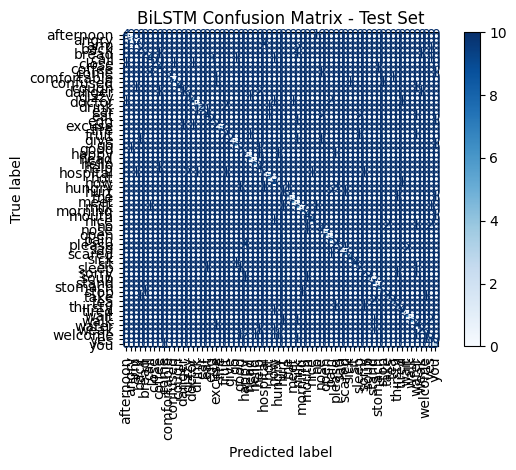

Confusion matrix saved to:
/content/drive/MyDrive/SignLanguage_Final_DS/final_model_dataset/bilstm_confusion_matrix.png


In [ ]:
# ============================================================
# SECTION 12C: CONFUSION MATRIX
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("=" * 80)
print("CONFUSION MATRIX")
print("=" * 80)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(22, 22))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    xticks_rotation=90,
    cmap="Blues",
    values_format="d"
)

plt.title("BiLSTM Confusion Matrix - Test Set")
plt.tight_layout()

confusion_matrix_path = FINAL_DATASET_DIR / "bilstm_confusion_matrix.png"
plt.savefig(confusion_matrix_path, dpi=300)
plt.show()

print("Confusion matrix saved to:")
print(confusion_matrix_path)

print("=" * 80)

# Learning Curves

###Justification: Learning curves show whether the model learned steadily and whether overfitting occurred.The BiLSTM model demonstrated stable convergence during training. Both training and validation accuracy increased progressively with only a small generalization gap observed between the curves. Similarly, training and validation loss decreased consistently without significant divergence, indicating that the model learned meaningful temporal gesture representations while maintaining reasonable generalization performance.



LEARNING CURVES
Training history saved to:
/content/drive/MyDrive/SignLanguage_Final_DS/final_model_dataset/bilstm_training_history.csv


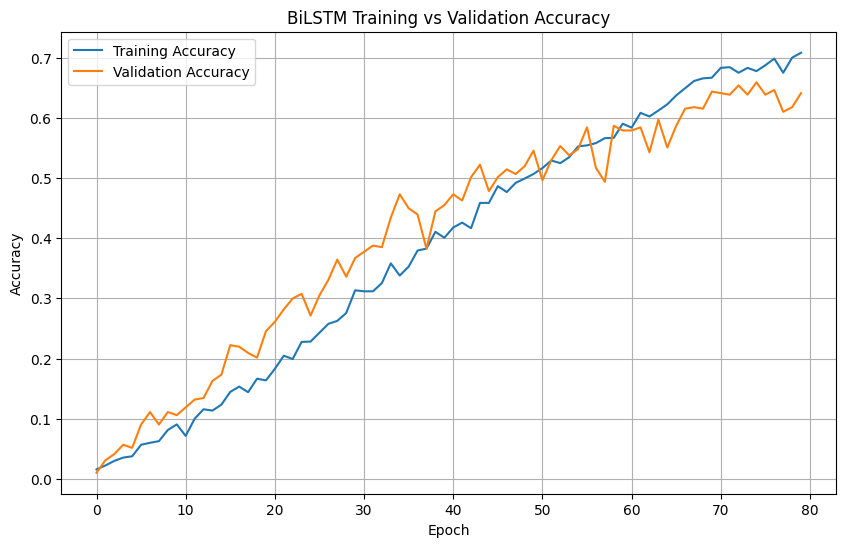

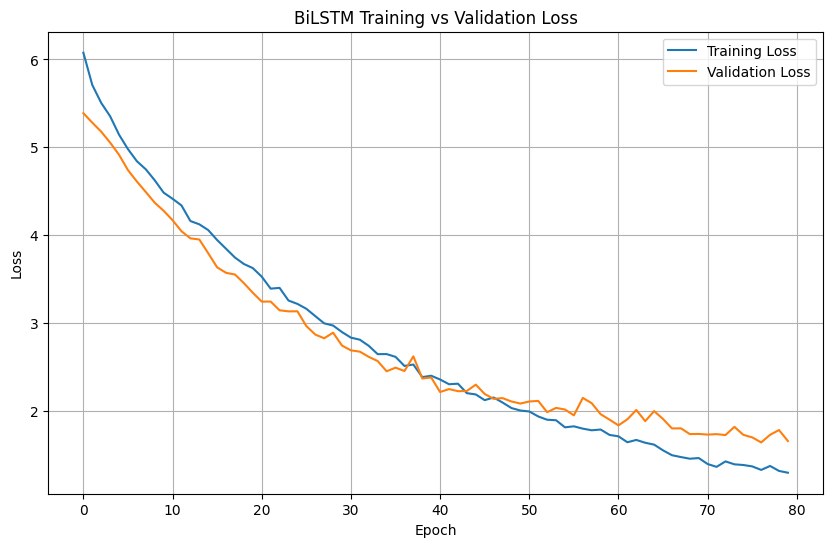

Accuracy curve saved to:
/content/drive/MyDrive/SignLanguage_Final_DS/final_model_dataset/bilstm_accuracy_curve.png
Loss curve saved to:
/content/drive/MyDrive/SignLanguage_Final_DS/final_model_dataset/bilstm_loss_curve.png


In [ ]:
# ============================================================
# SECTION 12D: LEARNING CURVES
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd

print("=" * 80)
print("LEARNING CURVES")
print("=" * 80)

# This works if the `history` object still exists in your current runtime
history_df = pd.DataFrame(history.history)

history_csv_path = FINAL_DATASET_DIR / "bilstm_training_history.csv"
history_df.to_csv(history_csv_path, index=False)

print("Training history saved to:")
print(history_csv_path)

# Accuracy curve
plt.figure(figsize=(10, 6))
plt.plot(history_df["accuracy"], label="Training Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
plt.title("BiLSTM Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

accuracy_curve_path = FINAL_DATASET_DIR / "bilstm_accuracy_curve.png"
plt.savefig(accuracy_curve_path, dpi=300)
plt.show()

# Loss curve
plt.figure(figsize=(10, 6))
plt.plot(history_df["loss"], label="Training Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.title("BiLSTM Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

loss_curve_path = FINAL_DATASET_DIR / "bilstm_loss_curve.png"
plt.savefig(loss_curve_path, dpi=300)
plt.show()

print("Accuracy curve saved to:")
print(accuracy_curve_path)

print("Loss curve saved to:")
print(loss_curve_path)

print("=" * 80)

# Gesture Quality Summary for Presentation

### Justification:This summarizes preprocessing quality and proves MediaPipe extraction improved after stabilization and normalization.

In [ ]:
# ============================================================
# SECTION 12E: GESTURE QUALITY SUMMARY FOR PRESENTATION
# ============================================================

import pandas as pd

print("=" * 80)
print("GESTURE QUALITY SUMMARY")
print("=" * 80)

raw_audit_path = PREPROCESSED_DIR / "mediapipe_landmark_quality_audit_sample.csv"
processed_audit_path = BASE_DIR / "preprocessed_landmarks_normalized" / "post_normalization_quality_audit_sample.csv"

raw_audit = pd.read_csv(raw_audit_path)
processed_audit = pd.read_csv(processed_audit_path)

summary = pd.DataFrame({
    "Metric": [
        "Pose Detection Ratio",
        "Any Hand Detection Ratio",
        "All-Zero Frame Ratio",
        "Low Quality Samples (<30% hand detection)"
    ],
    "Before Processing": [
        raw_audit["pose_detected_ratio"].mean(),
        raw_audit["any_hand_detected_ratio"].mean(),
        raw_audit["all_zero_frame_ratio"].mean(),
        len(raw_audit[raw_audit["any_hand_detected_ratio"] < 0.30])
    ],
    "After Processing": [
        processed_audit["pose_detected_ratio"].mean(),
        processed_audit["any_hand_detected_ratio"].mean(),
        processed_audit["all_zero_frame_ratio"].mean(),
        len(processed_audit[processed_audit["any_hand_detected_ratio"] < 0.30])
    ]
})

display(summary)

quality_summary_path = FINAL_DATASET_DIR / "gesture_quality_summary.csv"
summary.to_csv(quality_summary_path, index=False)

print("Gesture quality summary saved to:")
print(quality_summary_path)

print("=" * 80)

GESTURE QUALITY SUMMARY


,Metric,Before Processing,After Processing
0,Pose Detection Ratio,0.999417,0.999417
1,Any Hand Detection Ratio,0.437250,1.000000
2,All-Zero Frame Ratio,0.000583,0.000000
3,Low Quality Samples (<30% hand detection),33.000000,0.000000


Gesture quality summary saved to:
/content/drive/MyDrive/SignLanguage_Final_DS/final_model_dataset/gesture_quality_summary.csv


# Basic DTW Evaluation Prototype

### Justification: This tests your speed-tolerant gesture comparison idea by comparing two landmark sequences from the same class and different classes.

In [ ]:
# ============================================================
# SECTION 13A: BASIC DTW EVALUATION PROTOTYPE
# ============================================================

import numpy as np
import pandas as pd
from scipy.spatial.distance import euclidean

print("=" * 80)
print("BASIC DTW EVALUATION PROTOTYPE")
print("=" * 80)

def dtw_distance(seq1, seq2):
    """
    Basic Dynamic Time Warping distance.
    seq1, seq2 shape: (frames, features)
    """
    n, m = len(seq1), len(seq2)

    dtw = np.full((n + 1, m + 1), np.inf)
    dtw[0, 0] = 0

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = euclidean(seq1[i - 1], seq2[j - 1])
            dtw[i, j] = cost + min(
                dtw[i - 1, j],
                dtw[i, j - 1],
                dtw[i - 1, j - 1]
            )

    return dtw[n, m] / (n + m)


def dtw_similarity_score(distance, penalty_factor=10):
    """
    Converts DTW distance into 0-100 score.
    Higher is better.
    """
    score = 100 - (distance * penalty_factor)
    return max(0, min(100, score))


ENHANCED_DIR = BASE_DIR / "preprocessed_landmarks_enhanced"
clean_test_df = pd.read_csv(METADATA_DIR / "test_metadata_encoded_clean.csv")

# Pick one class with at least 2 samples
class_counts = clean_test_df["label"].value_counts()
selected_label = class_counts[class_counts >= 2].index[0]

same_class_df = clean_test_df[clean_test_df["label"] == selected_label].head(2)

sample_a = same_class_df.iloc[0]
sample_b = same_class_df.iloc[1]

# Pick different class sample
different_sample = clean_test_df[clean_test_df["label"] != selected_label].iloc[0]

seq_a = np.load(ENHANCED_DIR / "test" / safe_filename(sample_a["video_path"]))
seq_b = np.load(ENHANCED_DIR / "test" / safe_filename(sample_b["video_path"]))
seq_diff = np.load(ENHANCED_DIR / "test" / safe_filename(different_sample["video_path"]))

same_distance = dtw_distance(seq_a, seq_b)
diff_distance = dtw_distance(seq_a, seq_diff)

same_score = dtw_similarity_score(same_distance)
diff_score = dtw_similarity_score(diff_distance)

print("Reference label:", selected_label)

print("\nSame-class comparison:")
print("Sample A:", sample_a["filename"])
print("Sample B:", sample_b["filename"])
print(f"DTW distance: {same_distance:.4f}")
print(f"Similarity score: {same_score:.2f}")

print("\nDifferent-class comparison:")
print("Sample A:", sample_a["filename"])
print("Different label:", different_sample["label"])
print("Different sample:", different_sample["filename"])
print(f"DTW distance: {diff_distance:.4f}")
print(f"Similarity score: {diff_score:.2f}")

print("=" * 80)

BASIC DTW EVALUATION PROTOTYPE
Reference label: arm

Same-class comparison:
Sample A: asl_citizen_057.mp4
Sample B: asl_citizen_067.mp4
DTW distance: 6.8943
Similarity score: 31.06

Different-class comparison:
Sample A: asl_citizen_057.mp4
Different label: how
Different sample: asl_citizen_058.mp4
DTW distance: 6.7016
Similarity score: 32.98


# Specialized DTW Feature Extractor

###Justification:DTW should compare gesture motion quality, not all model-training features. This extracts only left hand, right hand, and hand velocity for cleaner speed-tolerant gesture comparison.

In [ ]:
# ============================================================
# SECTION 13B: SPECIALIZED DTW FEATURE EXTRACTOR
# ============================================================

import numpy as np
import pandas as pd
from scipy.spatial.distance import euclidean

print("=" * 80)
print("SPECIALIZED DTW FEATURE EXTRACTOR")
print("=" * 80)

# Enhanced feature layout:
# Position:      0:258
# Velocity:      258:516
# Acceleration:  516:774

# Within each 258 block:
# Pose:       0:132
# Left hand:  132:195
# Right hand: 195:258

LEFT_HAND_POS_START = 132
LEFT_HAND_POS_END = 195

RIGHT_HAND_POS_START = 195
RIGHT_HAND_POS_END = 258

VELOCITY_START = 258

LEFT_HAND_VEL_START = VELOCITY_START + 132
LEFT_HAND_VEL_END = VELOCITY_START + 195

RIGHT_HAND_VEL_START = VELOCITY_START + 195
RIGHT_HAND_VEL_END = VELOCITY_START + 258


def extract_dtw_features(enhanced_sequence):
    """
    Extract DTW-specific features:
    - left hand position
    - right hand position
    - left hand velocity
    - right hand velocity

    Input shape:  (40, 774)
    Output shape: (40, 252)
    """

    left_hand_position = enhanced_sequence[:, LEFT_HAND_POS_START:LEFT_HAND_POS_END]
    right_hand_position = enhanced_sequence[:, RIGHT_HAND_POS_START:RIGHT_HAND_POS_END]

    left_hand_velocity = enhanced_sequence[:, LEFT_HAND_VEL_START:LEFT_HAND_VEL_END]
    right_hand_velocity = enhanced_sequence[:, RIGHT_HAND_VEL_START:RIGHT_HAND_VEL_END]

    dtw_features = np.concatenate(
        [
            left_hand_position,
            right_hand_position,
            left_hand_velocity,
            right_hand_velocity
        ],
        axis=1
    )

    return dtw_features.astype(np.float32)


def normalize_dtw_features(sequence):
    """
    Normalizes each DTW sequence to reduce scale effects.
    """

    mean = np.mean(sequence, axis=0, keepdims=True)
    std = np.std(sequence, axis=0, keepdims=True) + 1e-6

    return (sequence - mean) / std


print("DTW feature extractor ready.")
print("Expected DTW feature shape: (40, 252)")
print("=" * 80)

SPECIALIZED DTW FEATURE EXTRACTOR
DTW feature extractor ready.
Expected DTW feature shape: (40, 252)


#Re-run DTW Evaluation with Hand Motion Features

### Justification:This checks whether the improved DTW representation separates same-class gestures from different-class gestures better than the earlier all-feature DTW.

In [ ]:
# ============================================================
# SECTION 13C: RE-RUN DTW EVALUATION WITH HAND MOTION FEATURES
# ============================================================

import numpy as np
import pandas as pd
from scipy.spatial.distance import euclidean

print("=" * 80)
print("DTW EVALUATION WITH HAND MOTION FEATURES")
print("=" * 80)

def dtw_distance(seq1, seq2):
    """
    Dynamic Time Warping distance.
    """

    n, m = len(seq1), len(seq2)

    dtw = np.full((n + 1, m + 1), np.inf)
    dtw[0, 0] = 0

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = euclidean(seq1[i - 1], seq2[j - 1])
            dtw[i, j] = cost + min(
                dtw[i - 1, j],
                dtw[i, j - 1],
                dtw[i - 1, j - 1]
            )

    return dtw[n, m] / (n + m)


def dtw_similarity_score(distance, min_distance=0.0, max_distance=15.0):
    """
    Converts DTW distance into 0-100 score.
    Lower distance = higher score.
    """

    normalized = (distance - min_distance) / (max_distance - min_distance)
    score = 100 * (1 - normalized)

    return max(0, min(100, score))


ENHANCED_DIR = BASE_DIR / "preprocessed_landmarks_enhanced"
clean_test_df = pd.read_csv(METADATA_DIR / "test_metadata_encoded_clean.csv")

# Pick a class with at least 2 samples
class_counts = clean_test_df["label"].value_counts()
selected_label = class_counts[class_counts >= 2].index[0]

same_class_df = clean_test_df[clean_test_df["label"] == selected_label].head(2)

sample_a = same_class_df.iloc[0]
sample_b = same_class_df.iloc[1]

different_sample = clean_test_df[clean_test_df["label"] != selected_label].iloc[0]

seq_a_raw = np.load(ENHANCED_DIR / "test" / safe_filename(sample_a["video_path"]))
seq_b_raw = np.load(ENHANCED_DIR / "test" / safe_filename(sample_b["video_path"]))
seq_diff_raw = np.load(ENHANCED_DIR / "test" / safe_filename(different_sample["video_path"]))

seq_a = normalize_dtw_features(extract_dtw_features(seq_a_raw))
seq_b = normalize_dtw_features(extract_dtw_features(seq_b_raw))
seq_diff = normalize_dtw_features(extract_dtw_features(seq_diff_raw))

same_distance = dtw_distance(seq_a, seq_b)
diff_distance = dtw_distance(seq_a, seq_diff)

same_score = dtw_similarity_score(same_distance)
diff_score = dtw_similarity_score(diff_distance)

print("Reference label:", selected_label)

print("\nSame-class comparison:")
print("Sample A:", sample_a["filename"])
print("Sample B:", sample_b["filename"])
print(f"DTW distance: {same_distance:.4f}")
print(f"Similarity score: {same_score:.2f}")

print("\nDifferent-class comparison:")
print("Sample A:", sample_a["filename"])
print("Different label:", different_sample["label"])
print("Different sample:", different_sample["filename"])
print(f"DTW distance: {diff_distance:.4f}")
print(f"Similarity score: {diff_score:.2f}")

print("=" * 80)

DTW EVALUATION WITH HAND MOTION FEATURES
Reference label: arm

Same-class comparison:
Sample A: asl_citizen_057.mp4
Sample B: asl_citizen_067.mp4
DTW distance: 8.3641
Similarity score: 44.24

Different-class comparison:
Sample A: asl_citizen_057.mp4
Different label: how
Different sample: asl_citizen_058.mp4
DTW distance: 9.7462
Similarity score: 35.03


#Gesture Quality Band Interpretation

###Justification:This converts DTW similarity scores into user-friendly feedback levels.

In [ ]:
# ============================================================
# SECTION 13D: GESTURE QUALITY BAND INTERPRETATION
# ============================================================

print("=" * 80)
print("GESTURE QUALITY BAND INTERPRETATION")
print("=" * 80)

def interpret_similarity_score(score):
    """
    Converts similarity score into feedback band.
    """

    if score >= 85:
        return "Excellent", "Gesture is highly accurate."
    elif score >= 70:
        return "Good", "Gesture is mostly correct with minor adjustments needed."
    elif score >= 50:
        return "Acceptable", "Gesture is understandable but needs improvement."
    else:
        return "Needs Improvement", "Gesture differs significantly from the reference."

same_band, same_feedback = interpret_similarity_score(same_score)
diff_band, diff_feedback = interpret_similarity_score(diff_score)

print("Same-class gesture quality:")
print("Score:", round(same_score, 2))
print("Band:", same_band)
print("Feedback:", same_feedback)

print("\nDifferent-class gesture quality:")
print("Score:", round(diff_score, 2))
print("Band:", diff_band)
print("Feedback:", diff_feedback)

print("=" * 80)

GESTURE QUALITY BAND INTERPRETATION
Same-class gesture quality:
Score: 44.24
Band: Needs Improvement
Feedback: Gesture differs significantly from the reference.

Different-class gesture quality:
Score: 35.03
Band: Needs Improvement
Feedback: Gesture differs significantly from the reference.


# Basic Corrective Feedback System

###Justification:This creates simple interpretable feedback based on hand movement differences, trajectory error, and timing mismatch.

In [ ]:
# ============================================================
# SECTION 13F: CALIBRATE DTW DISTANCE USING SAME-CLASS AND DIFFERENT-CLASS PAIRS
# ============================================================

import numpy as np
import pandas as pd
import random
from tqdm import tqdm

print("=" * 80)
print("CALIBRATE DTW DISTANCE")
print("=" * 80)

ENHANCED_DIR = BASE_DIR / "preprocessed_landmarks_enhanced"
clean_test_df = pd.read_csv(METADATA_DIR / "test_metadata_encoded_clean.csv")

def load_dtw_sequence(row):
    raw = np.load(ENHANCED_DIR / "test" / safe_filename(row["video_path"]))
    return normalize_dtw_features(extract_dtw_features(raw))

same_class_results = []
different_class_results = []

# Use labels with at least 2 test samples
eligible_labels = clean_test_df["label"].value_counts()
eligible_labels = eligible_labels[eligible_labels >= 2].index.tolist()

random.seed(42)

MAX_PAIRS = 100

# Same-class pairs
for label in tqdm(eligible_labels[:MAX_PAIRS], desc="Same-class pairs"):
    label_df = clean_test_df[clean_test_df["label"] == label]

    if len(label_df) < 2:
        continue

    sample_pair = label_df.sample(2, random_state=random.randint(1, 10000))

    seq1 = load_dtw_sequence(sample_pair.iloc[0])
    seq2 = load_dtw_sequence(sample_pair.iloc[1])

    distance = dtw_distance(seq1, seq2)

    same_class_results.append({
        "comparison_type": "same_class",
        "label_a": label,
        "label_b": label,
        "distance": distance
    })

# Different-class pairs
for i in tqdm(range(min(MAX_PAIRS, len(clean_test_df))), desc="Different-class pairs"):
    sample_a = clean_test_df.sample(1, random_state=random.randint(1, 10000)).iloc[0]

    different_df = clean_test_df[clean_test_df["label"] != sample_a["label"]]
    sample_b = different_df.sample(1, random_state=random.randint(1, 10000)).iloc[0]

    seq1 = load_dtw_sequence(sample_a)
    seq2 = load_dtw_sequence(sample_b)

    distance = dtw_distance(seq1, seq2)

    different_class_results.append({
        "comparison_type": "different_class",
        "label_a": sample_a["label"],
        "label_b": sample_b["label"],
        "distance": distance
    })

calibration_df = pd.DataFrame(same_class_results + different_class_results)

calibration_path = FINAL_DATASET_DIR / "dtw_calibration_results.csv"
calibration_df.to_csv(calibration_path, index=False)

print("\nDTW distance summary:")
display(calibration_df.groupby("comparison_type")["distance"].describe())

same_mean = calibration_df[calibration_df["comparison_type"] == "same_class"]["distance"].mean()
diff_mean = calibration_df[calibration_df["comparison_type"] == "different_class"]["distance"].mean()

print("\nAverage same-class distance:", round(same_mean, 4))
print("Average different-class distance:", round(diff_mean, 4))

if same_mean < diff_mean:
    print("\nDTW calibration PASSED: same-class gestures are closer than different-class gestures.")
else:
    print("\nDTW calibration WARNING: same-class gestures are not clearly closer yet.")

print("\nCalibration saved to:")
print(calibration_path)

print("=" * 80)

CALIBRATE DTW DISTANCE


Different-class pairs: 100%|██████████| 100/100 [00:04<00:00, 21.18it/s]



DTW distance summary:


,count,mean,std,min,25%,50%,75%,max
comparison_type,,,,,,,,
different_class,100.0,9.126086,1.070885,6.061233,8.497238,9.111398,9.913749,11.185195
same_class,66.0,8.567001,1.337709,4.063379,7.720764,8.782727,9.458367,11.039233



Average same-class distance: 8.567
Average different-class distance: 9.1261

DTW calibration PASSED: same-class gestures are closer than different-class gestures.

Calibration saved to:
/content/drive/MyDrive/SignLanguage_Final_DS/final_model_dataset/dtw_calibration_results.csv


#Calibrated DTW Scoring and Feedback Bands

### Justification:Your DTW distances are now calibrated using same-class and different-class comparisons. This converts raw DTW distance into a meaningful 0–100 gesture quality score based on your dataset.

In [ ]:
# ============================================================
# SECTION 13G: CALIBRATED DTW SCORING AND FEEDBACK BANDS
# ============================================================

import numpy as np
import pandas as pd

print("=" * 80)
print("CALIBRATED DTW SCORING AND FEEDBACK BANDS")
print("=" * 80)

# Load calibration results
calibration_path = FINAL_DATASET_DIR / "dtw_calibration_results.csv"
calibration_df = pd.read_csv(calibration_path)

same_distances = calibration_df[
    calibration_df["comparison_type"] == "same_class"
]["distance"]

different_distances = calibration_df[
    calibration_df["comparison_type"] == "different_class"
]["distance"]

# Dataset-based thresholds
excellent_threshold = same_distances.quantile(0.25)
good_threshold = same_distances.quantile(0.50)
acceptable_threshold = different_distances.quantile(0.25)
poor_threshold = different_distances.quantile(0.75)

print("DTW distance thresholds:")
print(f"Excellent distance <= {excellent_threshold:.4f}")
print(f"Good distance      <= {good_threshold:.4f}")
print(f"Acceptable distance<= {acceptable_threshold:.4f}")
print(f"Poor distance      >  {acceptable_threshold:.4f}")

def calibrated_dtw_score(distance):
    """
    Convert DTW distance into a calibrated 0-100 score.
    Lower distance = better score.
    Uses calibration range from same-class and different-class distances.
    """

    best_distance = same_distances.min()
    worst_distance = different_distances.quantile(0.90)

    score = 100 * (1 - ((distance - best_distance) / (worst_distance - best_distance)))
    score = max(0, min(100, score))

    return score


def interpret_dtw_distance(distance):
    """
    Convert DTW distance into quality band using dataset-calibrated thresholds.
    """

    score = calibrated_dtw_score(distance)

    if distance <= excellent_threshold:
        band = "Excellent"
        feedback = "Gesture closely matches the reference."
    elif distance <= good_threshold:
        band = "Good"
        feedback = "Gesture is mostly accurate with minor adjustments needed."
    elif distance <= acceptable_threshold:
        band = "Acceptable"
        feedback = "Gesture is understandable but needs clearer hand motion."
    else:
        band = "Needs Improvement"
        feedback = "Gesture differs noticeably from the reference. Practice with avatar guidance."

    return score, band, feedback


# Test using previous same_distance and diff_distance from Section 13C
same_score_calibrated, same_band, same_feedback = interpret_dtw_distance(same_distance)
diff_score_calibrated, diff_band, diff_feedback = interpret_dtw_distance(diff_distance)

print("\nSame-class calibrated result:")
print(f"Distance: {same_distance:.4f}")
print(f"Score: {same_score_calibrated:.2f}")
print("Band:", same_band)
print("Feedback:", same_feedback)

print("\nDifferent-class calibrated result:")
print(f"Distance: {diff_distance:.4f}")
print(f"Score: {diff_score_calibrated:.2f}")
print("Band:", diff_band)
print("Feedback:", diff_feedback)

print("=" * 80)

CALIBRATED DTW SCORING AND FEEDBACK BANDS
DTW distance thresholds:
Excellent distance <= 7.7208
Good distance      <= 8.7827
Acceptable distance<= 8.4972
Poor distance      >  8.4972

Same-class calibrated result:
Distance: 8.3641
Score: 33.97
Band: Good
Feedback: Gesture is mostly accurate with minor adjustments needed.

Different-class calibrated result:
Distance: 9.7462
Score: 12.75
Band: Needs Improvement
Feedback: Gesture differs noticeably from the reference. Practice with avatar guidance.


# DTW corrective feedback system

In [ ]:
# ============================================================
# SECTION 13H: DTW-BASED CORRECTIVE FEEDBACK SYSTEM
# ============================================================

import numpy as np

print("=" * 80)
print("DTW-BASED CORRECTIVE FEEDBACK SYSTEM")
print("=" * 80)

def compute_hand_motion_strength(seq):
    """
    DTW feature layout:
    0:63   left hand position
    63:126 right hand position
    126:189 left hand velocity
    189:252 right hand velocity
    """

    left_velocity = seq[:, 126:189]
    right_velocity = seq[:, 189:252]

    left_motion = np.mean(np.linalg.norm(left_velocity, axis=1))
    right_motion = np.mean(np.linalg.norm(right_velocity, axis=1))

    return left_motion, right_motion


def compute_hand_position_error(reference_seq, learner_seq):
    """
    Computes average position error for left and right hand.
    """

    ref_left = reference_seq[:, 0:63]
    ref_right = reference_seq[:, 63:126]

    learner_left = learner_seq[:, 0:63]
    learner_right = learner_seq[:, 63:126]

    left_error = np.mean(np.linalg.norm(ref_left - learner_left, axis=1))
    right_error = np.mean(np.linalg.norm(ref_right - learner_right, axis=1))

    return left_error, right_error


def generate_dtw_feedback(reference_seq, learner_seq, distance):
    """
    Generates simple interpretable corrective feedback.
    """

    score, band, base_feedback = interpret_dtw_distance(distance)

    feedback_messages = [base_feedback]

    ref_left_motion, ref_right_motion = compute_hand_motion_strength(reference_seq)
    learner_left_motion, learner_right_motion = compute_hand_motion_strength(learner_seq)

    left_error, right_error = compute_hand_position_error(reference_seq, learner_seq)

    left_motion_ratio = learner_left_motion / (ref_left_motion + 1e-6)
    right_motion_ratio = learner_right_motion / (ref_right_motion + 1e-6)

    if band != "Excellent":

        if left_motion_ratio < 0.75:
            feedback_messages.append("Left hand movement appears too limited or slow.")
        elif left_motion_ratio > 1.25:
            feedback_messages.append("Left hand movement appears too exaggerated or fast.")

        if right_motion_ratio < 0.75:
            feedback_messages.append("Right hand movement appears too limited or slow.")
        elif right_motion_ratio > 1.25:
            feedback_messages.append("Right hand movement appears too exaggerated or fast.")

        if left_error > 8.0:
            feedback_messages.append("Left hand position differs from the reference gesture.")

        if right_error > 8.0:
            feedback_messages.append("Right hand position differs from the reference gesture.")

        if score < 50:
            feedback_messages.append("Watch the reference avatar and repeat the gesture more slowly.")

    return {
        "score": round(score, 2),
        "band": band,
        "distance": round(distance, 4),
        "feedback": feedback_messages
    }


same_feedback_result = generate_dtw_feedback(seq_a, seq_b, same_distance)
diff_feedback_result = generate_dtw_feedback(seq_a, seq_diff, diff_distance)

print("Same-class feedback result:")
print(same_feedback_result)

print("\nDifferent-class feedback result:")
print(diff_feedback_result)

print("=" * 80)

DTW-BASED CORRECTIVE FEEDBACK SYSTEM
Same-class feedback result:
{'score': np.float64(33.97), 'band': 'Good', 'distance': np.float64(8.3641), 'feedback': ['Gesture is mostly accurate with minor adjustments needed.', 'Right hand movement appears too limited or slow.', 'Left hand position differs from the reference gesture.', 'Watch the reference avatar and repeat the gesture more slowly.']}

Different-class feedback result:
{'score': np.float64(12.75), 'band': 'Needs Improvement', 'distance': np.float64(9.7462), 'feedback': ['Gesture differs noticeably from the reference. Practice with avatar guidance.', 'Left hand position differs from the reference gesture.', 'Right hand position differs from the reference gesture.', 'Watch the reference avatar and repeat the gesture more slowly.']}


In [ ]:
# ============================================================
# SECTION 13I: FIX DTW SCORE SCALING
# ============================================================

print("=" * 80)
print("FIX DTW SCORE SCALING")
print("=" * 80)

def calibrated_dtw_score_v2(distance):
    """
    Converts DTW distance into score aligned with quality bands.
    """

    if distance <= excellent_threshold:
        # Excellent: 85-100
        score = 100 - ((distance - same_distances.min()) / (excellent_threshold - same_distances.min() + 1e-6)) * 15

    elif distance <= good_threshold:
        # Good: 70-84
        score = 84 - ((distance - excellent_threshold) / (good_threshold - excellent_threshold + 1e-6)) * 14

    elif distance <= acceptable_threshold:
        # Acceptable: 50-69
        score = 69 - ((distance - good_threshold) / (acceptable_threshold - good_threshold + 1e-6)) * 19

    else:
        # Needs Improvement: 0-49
        score = 49 - ((distance - acceptable_threshold) / (different_distances.max() - acceptable_threshold + 1e-6)) * 49

    return float(max(0, min(100, score)))


def interpret_dtw_distance_v2(distance):
    score = calibrated_dtw_score_v2(distance)

    if distance <= excellent_threshold:
        band = "Excellent"
        feedback = "Gesture closely matches the reference."
    elif distance <= good_threshold:
        band = "Good"
        feedback = "Gesture is mostly accurate with minor adjustments needed."
    elif distance <= acceptable_threshold:
        band = "Acceptable"
        feedback = "Gesture is understandable but needs clearer hand motion."
    else:
        band = "Needs Improvement"
        feedback = "Gesture differs noticeably from the reference. Practice with avatar guidance."

    return score, band, feedback


same_score_v2, same_band_v2, same_feedback_v2 = interpret_dtw_distance_v2(same_distance)
diff_score_v2, diff_band_v2, diff_feedback_v2 = interpret_dtw_distance_v2(diff_distance)

print("Same-class calibrated result:")
print(f"Distance: {same_distance:.4f}")
print(f"Score: {same_score_v2:.2f}")
print("Band:", same_band_v2)
print("Feedback:", same_feedback_v2)

print("\nDifferent-class calibrated result:")
print(f"Distance: {diff_distance:.4f}")
print(f"Score: {diff_score_v2:.2f}")
print("Band:", diff_band_v2)
print("Feedback:", diff_feedback_v2)

print("=" * 80)

FIX DTW SCORE SCALING
Same-class calibrated result:
Distance: 8.3641
Score: 75.52
Band: Good
Feedback: Gesture is mostly accurate with minor adjustments needed.

Different-class calibrated result:
Distance: 9.7462
Score: 26.23
Band: Needs Improvement
Feedback: Gesture differs noticeably from the reference. Practice with avatar guidance.


# FINALIZE DTW FEEDBACK FUNCTION

In [ ]:
def generate_dtw_feedback(
    reference_seq,
    learner_seq
):

    distance = dtw_distance(
        reference_seq,
        learner_seq
    )

    score = calibrated_dtw_score(distance)

    band, base_feedback = interpret_dtw_score(score)

    feedback = [base_feedback]

    ref_left_motion, ref_right_motion = \
        compute_hand_motion_strength(reference_seq)

    learner_left_motion, learner_right_motion = \
        compute_hand_motion_strength(learner_seq)

    left_error, right_error = \
        compute_hand_position_error(
            reference_seq,
            learner_seq
        )

    left_ratio = learner_left_motion / (
        ref_left_motion + 1e-6
    )

    right_ratio = learner_right_motion / (
        ref_right_motion + 1e-6
    )

    if left_ratio < 0.75:
        feedback.append(
            "Left hand movement is too limited or slow."
        )

    elif left_ratio > 1.25:
        feedback.append(
            "Left hand movement is too exaggerated or fast."
        )

    if right_ratio < 0.75:
        feedback.append(
            "Right hand movement is too limited or slow."
        )

    elif right_ratio > 1.25:
        feedback.append(
            "Right hand movement is too exaggerated or fast."
        )

    if left_error > 8:
        feedback.append(
            "Left hand position differs from the reference."
        )

    if right_error > 8:
        feedback.append(
            "Right hand position differs from the reference."
        )

    return {
        "distance": float(round(distance, 4)),
        "score": float(score),
        "band": band,
        "feedback": feedback
    }

In [ ]:
same_result = generate_dtw_feedback(seq_a, seq_b)
diff_result = generate_dtw_feedback(seq_a, seq_diff)

print("\nSame-class result:")
print(same_result)

print("\nDifferent-class result:")
print(diff_result)


Same-class result:
{'distance': 8.3641, 'score': 87.86, 'band': 'Excellent', 'feedback': ['Gesture closely matches the reference.', 'Right hand movement is too limited or slow.', 'Left hand position differs from the reference.']}

Different-class result:
{'distance': 9.7462, 'score': 41.79, 'band': 'Needs Improvement', 'feedback': ['Gesture differs noticeably from the reference.', 'Left hand position differs from the reference.', 'Right hand position differs from the reference.']}


#GRU Model Training for Temporal Gesture Comparison

### This section trains a Gated Recurrent Unit (GRU) model using the finalized landmark motion features. The GRU architecture is evaluated as an alternative sequence-learning approach to compare against the baseline BiLSTM model in terms of gesture recognition accuracy, generalization performance, and temporal learning capability.

In [ ]:
# ============================================================
# SECTION 15A: TRAIN GRU MODEL FOR COMPARISON
# ============================================================

import numpy as np
import json
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from pathlib import Path

print("=" * 80)
print("TRAIN GRU MODEL FOR COMPARISON")
print("=" * 80)

# ------------------------------------------------------------
# LOAD FINAL DATASET ARRAYS
# ------------------------------------------------------------

FINAL_DATASET_DIR = BASE_DIR / "final_model_dataset"
MODEL_SAVE_DIR = BASE_DIR / "models"

X_train = np.load(FINAL_DATASET_DIR / "X_train.npy")
y_train = np.load(FINAL_DATASET_DIR / "y_train.npy")

X_val = np.load(FINAL_DATASET_DIR / "X_val.npy")
y_val = np.load(FINAL_DATASET_DIR / "y_val.npy")

X_test = np.load(FINAL_DATASET_DIR / "X_test.npy")
y_test = np.load(FINAL_DATASET_DIR / "y_test.npy")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

num_classes = len(np.unique(y_train))
input_shape = X_train.shape[1:]

print("Input shape:", input_shape)
print("Number of classes:", num_classes)

# ------------------------------------------------------------
# LOAD CLASS WEIGHTS
# ------------------------------------------------------------

with open(FINAL_DATASET_DIR / "class_weights.json", "r") as f:
    class_weights = json.load(f)

class_weights = {
    int(k): float(v)
    for k, v in class_weights.items()
}

# ------------------------------------------------------------
# BUILD GRU MODEL
# ------------------------------------------------------------

gru_model = Sequential([
    GRU(
        128,
        return_sequences=True,
        input_shape=input_shape,
        kernel_regularizer=l2(0.001)
    ),
    BatchNormalization(),
    Dropout(0.35),

    GRU(
        64,
        return_sequences=False,
        kernel_regularizer=l2(0.001)
    ),
    BatchNormalization(),
    Dropout(0.35),

    Dense(
        128,
        activation="relu",
        kernel_regularizer=l2(0.001)
    ),
    Dropout(0.30),

    Dense(
        num_classes,
        activation="softmax"
    )
])

gru_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

gru_model.summary()

# ------------------------------------------------------------
# CALLBACKS
# ------------------------------------------------------------

gru_model_path = MODEL_SAVE_DIR / "gru_best_model.keras"

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=12,
        restore_best_weights=True,
        verbose=1
    ),

    ModelCheckpoint(
        filepath=str(gru_model_path),
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

# ------------------------------------------------------------
# TRAIN MODEL
# ------------------------------------------------------------

history_gru = gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=32,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

print("=" * 80)
print("GRU training completed.")
print("Best GRU model saved to:")
print(gru_model_path)
print("=" * 80)

TRAIN GRU MODEL FOR COMPARISON
X_train: (1832, 40, 774)
y_train: (1832,)
X_val: (387, 40, 774)
y_val: (387,)
X_test: (393, 40, 774)
y_test: (393,)
Input shape: (40, 774)
Number of classes: 66


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 40, 128)        │       347,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 40, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 40, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 66)             │         8,514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 401,986 (1.53 MB)

 Trainable params: 401,602 (1.53 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/80
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.0193 - loss: 5.3039
Epoch 1: val_loss improved from None to 4.74679, saving model to /content/drive/MyDrive/SignLanguage_Final_DS/models/gru_best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/SignLanguage_Final_DS/models/gru_best_model.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 18s 172ms/step - accuracy: 0.0257 - loss: 5.1022 - val_accuracy: 0.0181 - val_loss: 4.7468 - learning_rate: 0.0010
Epoch 2/80
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.0469 - loss: 4.6609
Epoch 2: val_loss improved from 4.74679 to 4.48821, saving model to /content/drive/MyDrive/SignLanguage_Final_DS/models/gru_best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/SignLanguage_Final_DS/models/gru_best_model.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 145ms/step - accuracy: 0.0491 - loss: 4.6115 - val_accuracy: 0.0698 - val_loss: 4.4882 - learning_rate: 0.0010
Epoch 3/80
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/ste

# EVALUATE GRU MODEL ON TEST SET

In [ ]:
# ============================================================
# SECTION 15B: EVALUATE GRU MODEL ON TEST SET
# ============================================================

import numpy as np
import json
import tensorflow as tf
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("=" * 80)
print("EVALUATE GRU MODEL ON TEST SET")
print("=" * 80)

# ------------------------------------------------------------
# LOAD BEST GRU MODEL
# ------------------------------------------------------------

gru_model_path = MODEL_SAVE_DIR / "gru_best_model.keras"
gru_best_model = tf.keras.models.load_model(gru_model_path)

print("Loaded GRU model from:")
print(gru_model_path)

# ------------------------------------------------------------
# PREDICT TEST SET
# ------------------------------------------------------------

y_pred_probs = gru_best_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# ------------------------------------------------------------
# COMPUTE METRICS
# ------------------------------------------------------------

test_accuracy = accuracy_score(y_test, y_pred)

macro_precision = precision_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("\nFINAL GRU TEST METRICS")
print("-" * 50)
print(f"Test Accuracy:      {test_accuracy:.4f}")
print(f"Macro Precision:   {macro_precision:.4f}")
print(f"Macro Recall:      {macro_recall:.4f}")
print(f"Macro F1-score:    {macro_f1:.4f}")
print(f"Weighted F1-score: {weighted_f1:.4f}")

# ------------------------------------------------------------
# LOAD CLASS LABELS
# ------------------------------------------------------------

with open(METADATA_DIR / "id_to_label.json", "r") as f:
    id_to_label = json.load(f)

target_names = [
    id_to_label[str(i)]
    for i in range(len(id_to_label))
]

# ------------------------------------------------------------
# CLASSIFICATION REPORT
# ------------------------------------------------------------

report = classification_report(
    y_test,
    y_pred,
    target_names=target_names,
    zero_division=0
)

print("\nClassification Report:")
print(report)

# ------------------------------------------------------------
# SAVE REPORT
# ------------------------------------------------------------

gru_report_path = FINAL_DATASET_DIR / "gru_classification_report.txt"

with open(gru_report_path, "w") as f:
    f.write("GRU Classification Report\n")
    f.write("=" * 80 + "\n\n")
    f.write(f"Test Accuracy:      {test_accuracy:.4f}\n")
    f.write(f"Macro Precision:   {macro_precision:.4f}\n")
    f.write(f"Macro Recall:      {macro_recall:.4f}\n")
    f.write(f"Macro F1-score:    {macro_f1:.4f}\n")
    f.write(f"Weighted F1-score: {weighted_f1:.4f}\n\n")
    f.write(report)

print("\nGRU classification report saved to:")
print(gru_report_path)

print("=" * 80)

EVALUATE GRU MODEL ON TEST SET
Loaded GRU model from:
/content/drive/MyDrive/SignLanguage_Final_DS/models/gru_best_model.keras
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 185ms/step

FINAL GRU TEST METRICS
--------------------------------------------------
Test Accuracy:      0.7150
Macro Precision:   0.7417
Macro Recall:      0.7166
Macro F1-score:    0.7072
Weighted F1-score: 0.7086

Classification Report:
              precision    recall  f1-score   support

   afternoon       0.50      0.80      0.62         5
       angry       1.00      1.00      1.00         5
         arm       0.78      0.50      0.61        14
        back       0.50      0.60      0.55         5
       bread       0.60      0.60      0.60         5
        call       1.00      0.70      0.82        10
       close       1.00      0.60      0.75         5
      coffee       1.00      1.00      1.00         5
        come       0.50      0.40      0.44         5
 comfortable       1.00      0.80      0.89         5
    con

# Confusion Matrix

CONFUSION MATRIX


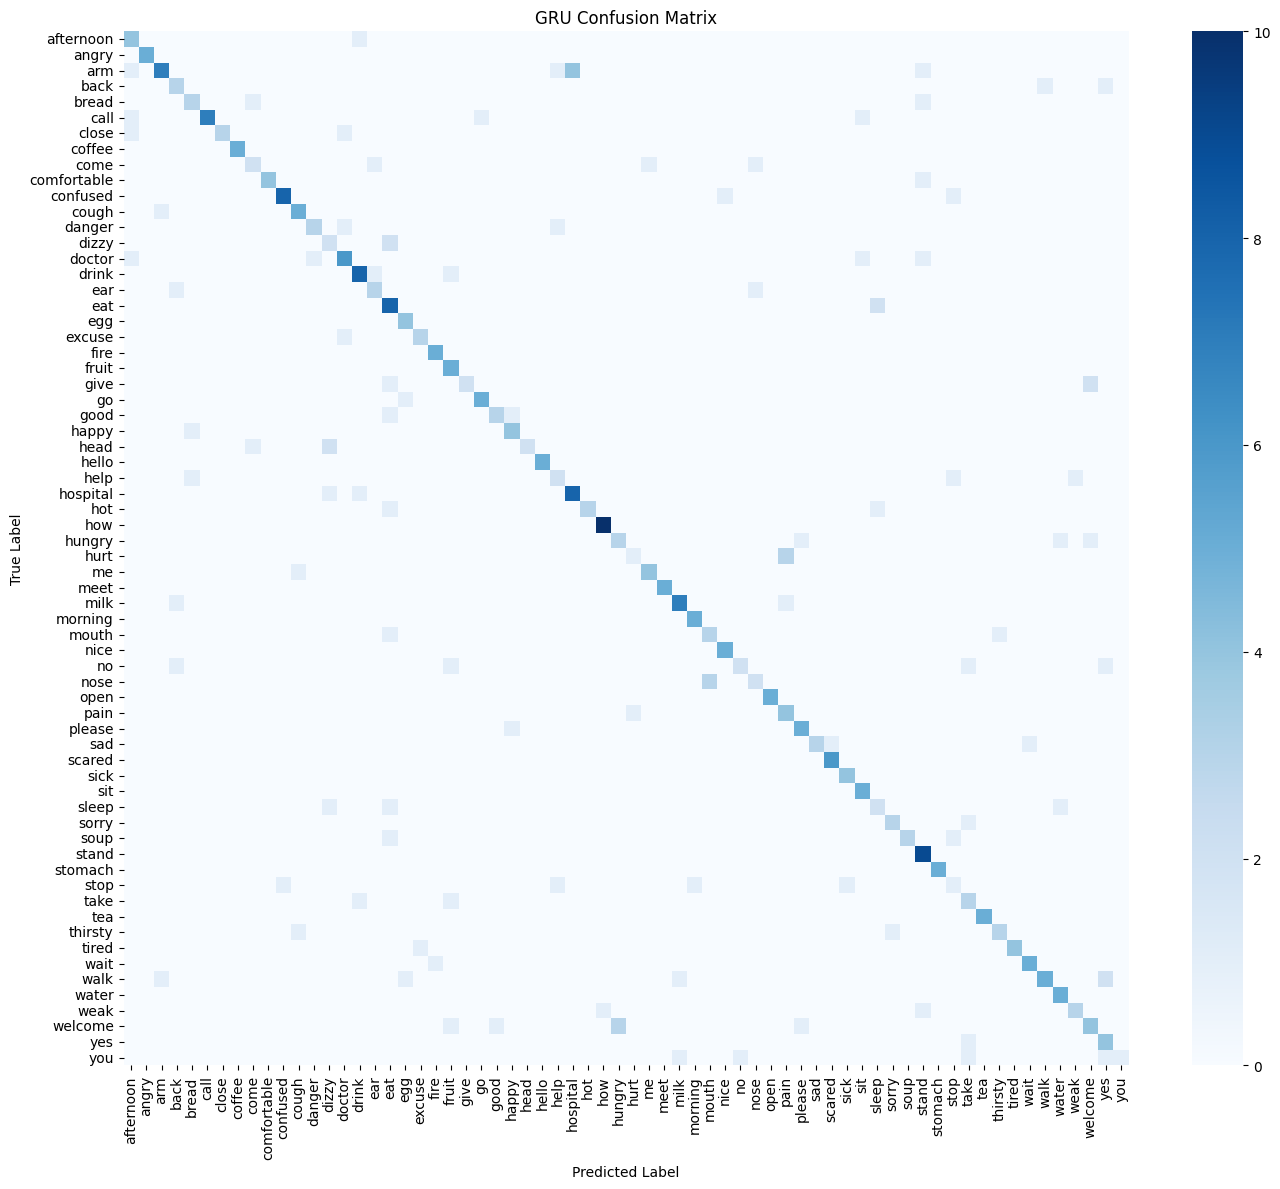

Saved raw confusion matrix:
/content/drive/MyDrive/SignLanguage_Final_DS/final_model_dataset/gru_confusion_matrix.png


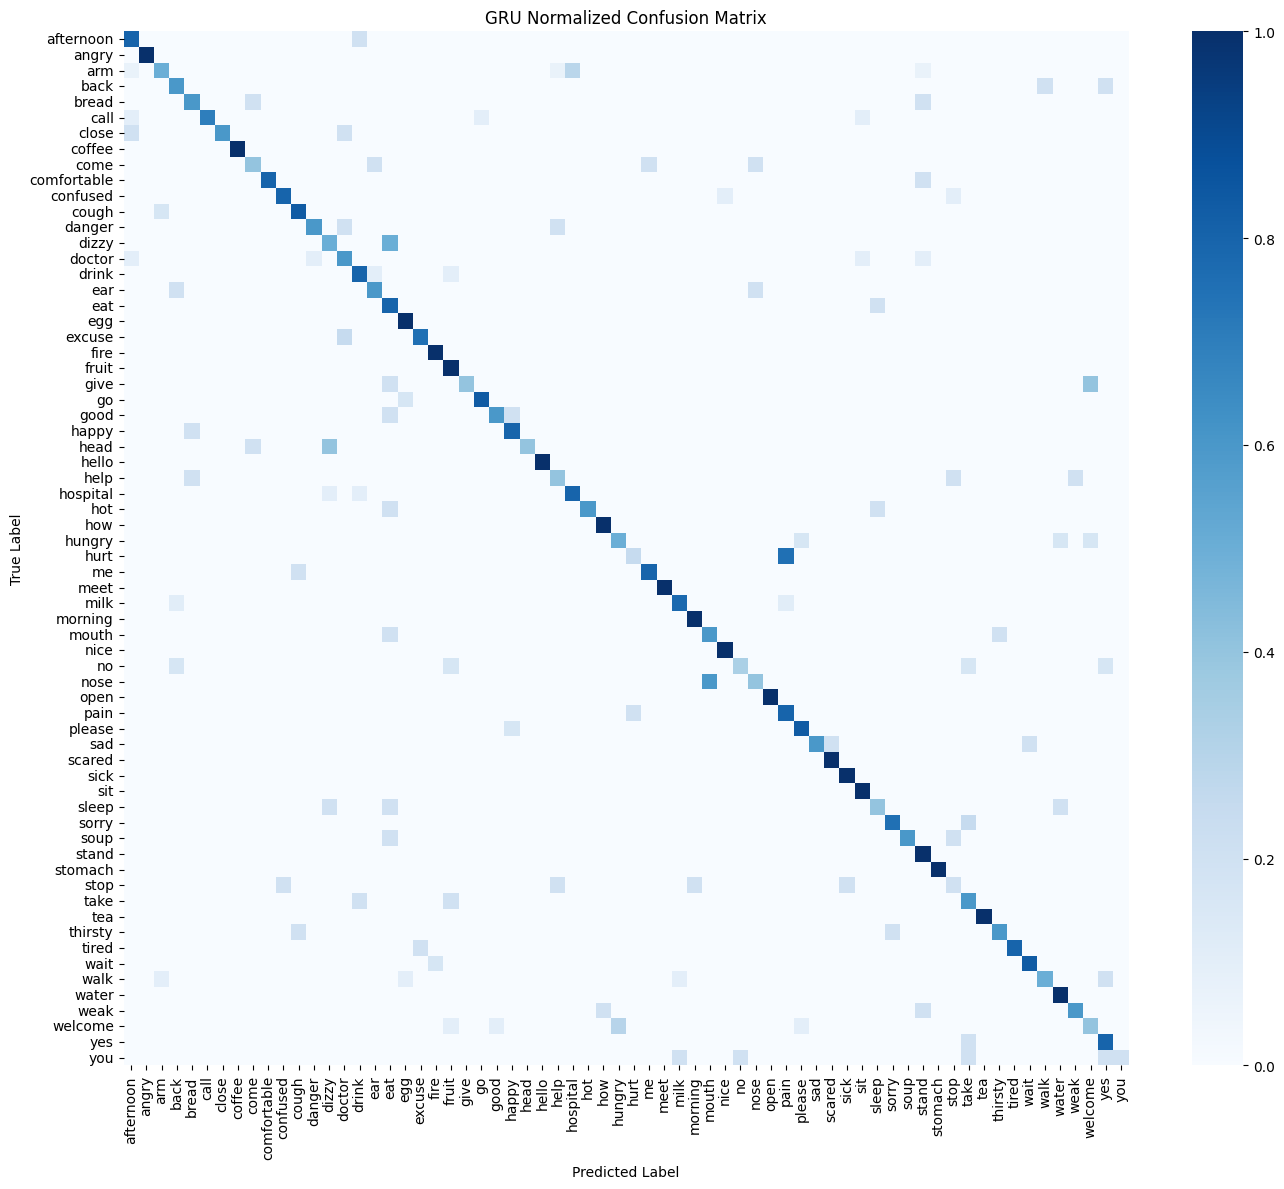

Saved normalized confusion matrix:
/content/drive/MyDrive/SignLanguage_Final_DS/final_model_dataset/gru_confusion_matrix_normalized.png


In [ ]:
# ============================================================
# SECTION 16A: CONFUSION MATRIX
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

print("=" * 80)
print("CONFUSION MATRIX")
print("=" * 80)

# ------------------------------------------------------------
# COMPUTE CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

# NORMALIZED VERSION
cm_normalized = confusion_matrix(
    y_test,
    y_pred,
    normalize="true"
)

# ------------------------------------------------------------
# PLOT RAW CONFUSION MATRIX
# ------------------------------------------------------------

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)

plt.title("GRU Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()

raw_cm_path = FINAL_DATASET_DIR / "gru_confusion_matrix.png"

plt.savefig(raw_cm_path)
plt.show()

print("Saved raw confusion matrix:")
print(raw_cm_path)

# ------------------------------------------------------------
# PLOT NORMALIZED CONFUSION MATRIX
# ------------------------------------------------------------

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm_normalized,
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)

plt.title("GRU Normalized Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()

norm_cm_path = FINAL_DATASET_DIR / "gru_confusion_matrix_normalized.png"

plt.savefig(norm_cm_path)
plt.show()

print("Saved normalized confusion matrix:")
print(norm_cm_path)

print("=" * 80)

#GRU training curves

GRU TRAINING CURVES
GRU training history saved to:
/content/drive/MyDrive/SignLanguage_Final_DS/final_model_dataset/gru_training_history.csv


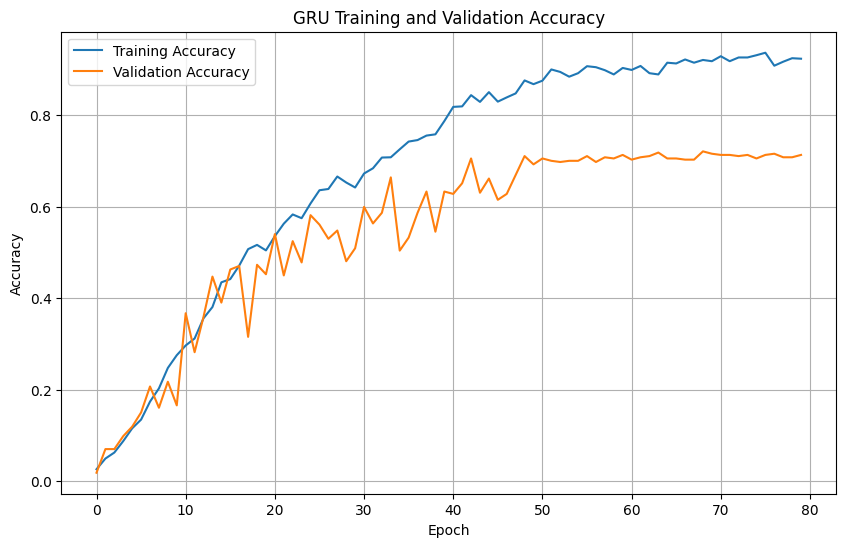

Accuracy curve saved to:
/content/drive/MyDrive/SignLanguage_Final_DS/final_model_dataset/gru_accuracy_curve.png


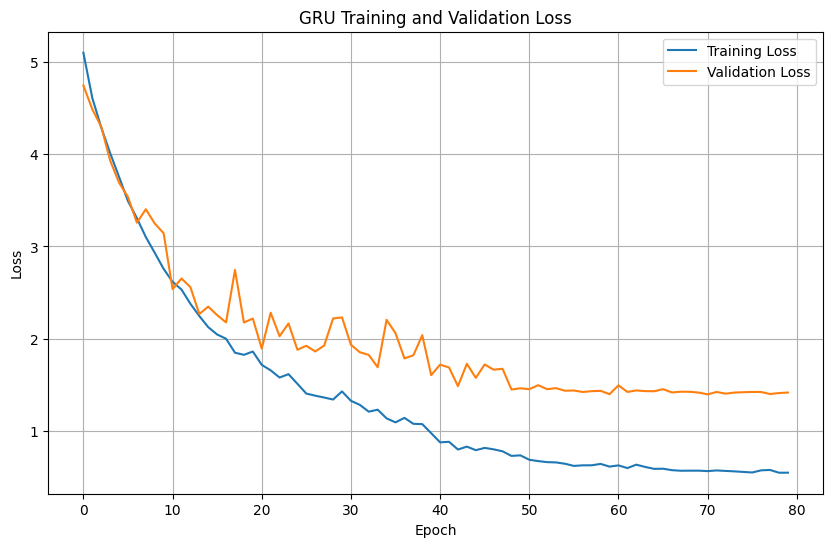

Loss curve saved to:
/content/drive/MyDrive/SignLanguage_Final_DS/final_model_dataset/gru_loss_curve.png
GRU training curve generation completed.


In [ ]:
# ============================================================
# SECTION 17A: GRU TRAINING CURVES
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd

print("=" * 80)
print("GRU TRAINING CURVES")
print("=" * 80)

# ------------------------------------------------------------
# CONVERT HISTORY TO DATAFRAME
# ------------------------------------------------------------

history_df = pd.DataFrame(history_gru.history)

history_csv_path = FINAL_DATASET_DIR / "gru_training_history.csv"
history_df.to_csv(history_csv_path, index=False)

print("GRU training history saved to:")
print(history_csv_path)

# ------------------------------------------------------------
# ACCURACY CURVE
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(history_df["accuracy"], label="Training Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")

plt.title("GRU Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

accuracy_curve_path = FINAL_DATASET_DIR / "gru_accuracy_curve.png"
plt.savefig(accuracy_curve_path, dpi=300, bbox_inches="tight")
plt.show()

print("Accuracy curve saved to:")
print(accuracy_curve_path)

# ------------------------------------------------------------
# LOSS CURVE
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(history_df["loss"], label="Training Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")

plt.title("GRU Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

loss_curve_path = FINAL_DATASET_DIR / "gru_loss_curve.png"
plt.savefig(loss_curve_path, dpi=300, bbox_inches="tight")
plt.show()

print("Loss curve saved to:")
print(loss_curve_path)

print("=" * 80)
print("GRU training curve generation completed.")
print("=" * 80)

# GRU Training Summary

In [ ]:
# ============================================================
# SECTION 17B: GRU TRAINING SUMMARY
# ============================================================

print("=" * 80)
print("GRU TRAINING SUMMARY")
print("=" * 80)

best_val_accuracy = history_df["val_accuracy"].max()
best_val_loss = history_df["val_loss"].min()
best_epoch_accuracy = history_df["val_accuracy"].idxmax() + 1
best_epoch_loss = history_df["val_loss"].idxmin() + 1

final_train_accuracy = history_df["accuracy"].iloc[-1]
final_val_accuracy = history_df["val_accuracy"].iloc[-1]

overfitting_gap = final_train_accuracy - final_val_accuracy

print(f"Best Validation Accuracy: {best_val_accuracy:.4f}")
print(f"Best Validation Accuracy Epoch: {best_epoch_accuracy}")

print(f"\nBest Validation Loss: {best_val_loss:.4f}")
print(f"Best Validation Loss Epoch: {best_epoch_loss}")

print(f"\nFinal Training Accuracy: {final_train_accuracy:.4f}")
print(f"Final Validation Accuracy: {final_val_accuracy:.4f}")

print(f"\nOverfitting Gap: {overfitting_gap:.4f}")

print("=" * 80)

GRU TRAINING SUMMARY
Best Validation Accuracy: 0.7209
Best Validation Accuracy Epoch: 69

Best Validation Loss: 1.3939
Best Validation Loss Epoch: 71

Final Training Accuracy: 0.9236
Final Validation Accuracy: 0.7132

Overfitting Gap: 0.2104


# ST - GCN Model


In [ ]:
# ============================================================
# SECTION 18A: PREPARE DATA FOR ST-GCN MODEL
# ============================================================

import numpy as np

print("=" * 80)
print("PREPARE DATA FOR ST-GCN")
print("=" * 80)

# ------------------------------------------------------------
# LOAD FINAL DATASET
# ------------------------------------------------------------

FINAL_DATASET_DIR = BASE_DIR / "final_model_dataset"

X_train = np.load(FINAL_DATASET_DIR / "X_train.npy")
y_train = np.load(FINAL_DATASET_DIR / "y_train.npy")

X_val = np.load(FINAL_DATASET_DIR / "X_val.npy")
y_val = np.load(FINAL_DATASET_DIR / "y_val.npy")

X_test = np.load(FINAL_DATASET_DIR / "X_test.npy")
y_test = np.load(FINAL_DATASET_DIR / "y_test.npy")

print("Original shapes:")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

# ------------------------------------------------------------
# USE POSITION FEATURES ONLY FOR ST-GCN
# ------------------------------------------------------------
# X shape currently: (samples, 40, 774)
# 0:258   = position
# 258:516 = velocity
# 516:774 = acceleration
#
# ST-GCN works best with skeleton coordinates.
# So we start with position only.

X_train_pos = X_train[:, :, 0:258]
X_val_pos = X_val[:, :, 0:258]
X_test_pos = X_test[:, :, 0:258]

print("\nPosition-only shapes:")
print("X_train_pos:", X_train_pos.shape)
print("X_val_pos:", X_val_pos.shape)
print("X_test_pos:", X_test_pos.shape)

# ------------------------------------------------------------
# EXTRACT X, Y, Z COORDINATES ONLY
# ------------------------------------------------------------
# Pose has 33 landmarks x 4 values = 132
# Hands have 21 x 3 left + 21 x 3 right = 126
#
# For ST-GCN, we keep:
# - pose x,y,z only
# - left hand x,y,z
# - right hand x,y,z
#
# Total joints:
# 33 pose + 21 left hand + 21 right hand = 75 joints
# Channels:
# x, y, z = 3 channels

def convert_to_stgcn_format(X):
    """
    Convert landmark features to ST-GCN format.

    Input shape:
        (samples, 40, 258)

    Output shape:
        (samples, 40, 75, 3)
    """

    all_samples = []

    for sample in X:

        frames = []

        for frame in sample:

            pose_raw = frame[0:132].reshape(33, 4)
            pose_xyz = pose_raw[:, 0:3]

            left_hand = frame[132:195].reshape(21, 3)
            right_hand = frame[195:258].reshape(21, 3)

            joints = np.concatenate(
                [
                    pose_xyz,
                    left_hand,
                    right_hand
                ],
                axis=0
            )

            frames.append(joints)

        all_samples.append(frames)

    return np.array(all_samples, dtype=np.float32)


X_train_stgcn = convert_to_stgcn_format(X_train_pos)
X_val_stgcn = convert_to_stgcn_format(X_val_pos)
X_test_stgcn = convert_to_stgcn_format(X_test_pos)

print("\nST-GCN formatted shapes:")
print("X_train_stgcn:", X_train_stgcn.shape)
print("X_val_stgcn:", X_val_stgcn.shape)
print("X_test_stgcn:", X_test_stgcn.shape)

# ------------------------------------------------------------
# SAVE ST-GCN DATA
# ------------------------------------------------------------

np.save(FINAL_DATASET_DIR / "X_train_stgcn.npy", X_train_stgcn)
np.save(FINAL_DATASET_DIR / "X_val_stgcn.npy", X_val_stgcn)
np.save(FINAL_DATASET_DIR / "X_test_stgcn.npy", X_test_stgcn)

print("\nSaved ST-GCN arrays to:")
print(FINAL_DATASET_DIR)

print("=" * 80)
print("ST-GCN data preparation completed.")
print("=" * 80)

PREPARE DATA FOR ST-GCN
Original shapes:
X_train: (1832, 40, 774)
X_val: (387, 40, 774)
X_test: (393, 40, 774)

Position-only shapes:
X_train_pos: (1832, 40, 258)
X_val_pos: (387, 40, 258)
X_test_pos: (393, 40, 258)

ST-GCN formatted shapes:
X_train_stgcn: (1832, 40, 75, 3)
X_val_stgcn: (387, 40, 75, 3)
X_test_stgcn: (393, 40, 75, 3)

Saved ST-GCN arrays to:
/content/drive/MyDrive/SignLanguage_Final_DS/final_model_dataset
ST-GCN data preparation completed.


In [ ]:
# ============================================================
# SECTION 18B: BUILD ST-GCN ADJACENCY MATRIX
# ============================================================

import numpy as np

print("=" * 80)
print("BUILD ST-GCN ADJACENCY MATRIX")
print("=" * 80)

# ------------------------------------------------------------
# GRAPH SETUP
# ------------------------------------------------------------
# Total joints:
# 0-32   = MediaPipe pose landmarks
# 33-53  = Left hand landmarks
# 54-74  = Right hand landmarks

NUM_JOINTS = 75

A = np.zeros((NUM_JOINTS, NUM_JOINTS), dtype=np.float32)

# ------------------------------------------------------------
# HELPER FUNCTION
# ------------------------------------------------------------

def add_edge(i, j):
    """
    Add undirected graph connection between two joints.
    """
    A[i, j] = 1
    A[j, i] = 1


# ------------------------------------------------------------
# ADD SELF CONNECTIONS
# ------------------------------------------------------------

for i in range(NUM_JOINTS):
    A[i, i] = 1


# ------------------------------------------------------------
# MEDIAPIPE POSE CONNECTIONS
# ------------------------------------------------------------

pose_edges = [
    # Face / head rough structure
    (0, 1), (1, 2), (2, 3), (3, 7),
    (0, 4), (4, 5), (5, 6), (6, 8),

    # Shoulders / torso
    (11, 12),
    (11, 23),
    (12, 24),
    (23, 24),

    # Left arm
    (11, 13),
    (13, 15),

    # Right arm
    (12, 14),
    (14, 16),

    # Left leg
    (23, 25),
    (25, 27),
    (27, 29),
    (29, 31),

    # Right leg
    (24, 26),
    (26, 28),
    (28, 30),
    (30, 32),
]

for i, j in pose_edges:
    add_edge(i, j)


# ------------------------------------------------------------
# MEDIAPIPE HAND CONNECTIONS
# ------------------------------------------------------------

hand_edges = [
    # Thumb
    (0, 1), (1, 2), (2, 3), (3, 4),

    # Index finger
    (0, 5), (5, 6), (6, 7), (7, 8),

    # Middle finger
    (0, 9), (9, 10), (10, 11), (11, 12),

    # Ring finger
    (0, 13), (13, 14), (14, 15), (15, 16),

    # Pinky
    (0, 17), (17, 18), (18, 19), (19, 20),

    # Palm structure
    (5, 9), (9, 13), (13, 17)
]

# Left hand offset = 33
LEFT_HAND_OFFSET = 33

for i, j in hand_edges:
    add_edge(LEFT_HAND_OFFSET + i, LEFT_HAND_OFFSET + j)

# Right hand offset = 54
RIGHT_HAND_OFFSET = 54

for i, j in hand_edges:
    add_edge(RIGHT_HAND_OFFSET + i, RIGHT_HAND_OFFSET + j)


# ------------------------------------------------------------
# CONNECT HANDS TO POSE WRISTS
# ------------------------------------------------------------
# MediaPipe pose:
# Left wrist  = 15
# Right wrist = 16
#
# Hand landmark:
# Wrist = 0

LEFT_POSE_WRIST = 15
RIGHT_POSE_WRIST = 16

LEFT_HAND_WRIST = 33
RIGHT_HAND_WRIST = 54

add_edge(LEFT_POSE_WRIST, LEFT_HAND_WRIST)
add_edge(RIGHT_POSE_WRIST, RIGHT_HAND_WRIST)


# ------------------------------------------------------------
# NORMALIZE ADJACENCY MATRIX
# ------------------------------------------------------------

def normalize_adjacency(A):
    """
    Symmetric adjacency normalization:
    A_norm = D^-1/2 A D^-1/2
    """

    degree = np.sum(A, axis=1)

    degree_inv_sqrt = np.power(degree, -0.5)
    degree_inv_sqrt[np.isinf(degree_inv_sqrt)] = 0.0

    D_inv_sqrt = np.diag(degree_inv_sqrt)

    A_norm = D_inv_sqrt @ A @ D_inv_sqrt

    return A_norm.astype(np.float32)


A_norm = normalize_adjacency(A)

# ------------------------------------------------------------
# SAVE MATRICES
# ------------------------------------------------------------

np.save(FINAL_DATASET_DIR / "stgcn_adjacency_raw.npy", A)
np.save(FINAL_DATASET_DIR / "stgcn_adjacency_normalized.npy", A_norm)

print("Raw adjacency matrix shape:", A.shape)
print("Normalized adjacency matrix shape:", A_norm.shape)

print("\nTotal graph connections:", int(np.sum(A)))
print("Saved raw adjacency matrix to:")
print(FINAL_DATASET_DIR / "stgcn_adjacency_raw.npy")

print("\nSaved normalized adjacency matrix to:")
print(FINAL_DATASET_DIR / "stgcn_adjacency_normalized.npy")

print("=" * 80)
print("ST-GCN adjacency matrix completed.")
print("=" * 80)

BUILD ST-GCN ADJACENCY MATRIX
Raw adjacency matrix shape: (75, 75)
Normalized adjacency matrix shape: (75, 75)

Total graph connections: 219
Saved raw adjacency matrix to:
/content/drive/MyDrive/SignLanguage_Final_DS/final_model_dataset/stgcn_adjacency_raw.npy

Saved normalized adjacency matrix to:
/content/drive/MyDrive/SignLanguage_Final_DS/final_model_dataset/stgcn_adjacency_normalized.npy
ST-GCN adjacency matrix completed.


# BUILD AND TRAIN CNN + BiLSTM MODEL

In [61]:
# ============================================================
# SECTION 19A: TRAIN CNN + BiLSTM MODEL
# ============================================================

import numpy as np
import json
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    Bidirectional,
    LSTM,
    Dense
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)
from tensorflow.keras.regularizers import l2

print("=" * 80)
print("TRAIN CNN + BiLSTM MODEL")
print("=" * 80)

# ------------------------------------------------------------
# LOAD FINAL DATASET
# ------------------------------------------------------------

FINAL_DATASET_DIR = BASE_DIR / "final_model_dataset"
MODEL_SAVE_DIR = BASE_DIR / "models"

X_train = np.load(FINAL_DATASET_DIR / "X_train.npy")
y_train = np.load(FINAL_DATASET_DIR / "y_train.npy")

X_val = np.load(FINAL_DATASET_DIR / "X_val.npy")
y_val = np.load(FINAL_DATASET_DIR / "y_val.npy")

X_test = np.load(FINAL_DATASET_DIR / "X_test.npy")
y_test = np.load(FINAL_DATASET_DIR / "y_test.npy")

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

input_shape = X_train.shape[1:]
num_classes = len(np.unique(y_train))

print("Input shape:", input_shape)
print("Number of classes:", num_classes)

# ------------------------------------------------------------
# LOAD CLASS WEIGHTS
# ------------------------------------------------------------

with open(FINAL_DATASET_DIR / "class_weights.json", "r") as f:
    class_weights = json.load(f)

class_weights = {
    int(k): float(v)
    for k, v in class_weights.items()
}

# ------------------------------------------------------------
# BUILD CNN + BiLSTM MODEL
# ------------------------------------------------------------

cnn_bilstm_model = Sequential([
    Input(shape=input_shape),

    Conv1D(
        filters=128,
        kernel_size=3,
        padding="same",
        activation="relu",
        kernel_regularizer=l2(0.001)
    ),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.30),

    Conv1D(
        filters=128,
        kernel_size=3,
        padding="same",
        activation="relu",
        kernel_regularizer=l2(0.001)
    ),
    BatchNormalization(),
    Dropout(0.30),

    Bidirectional(
        LSTM(
            128,
            return_sequences=True,
            kernel_regularizer=l2(0.001)
        )
    ),
    Dropout(0.35),

    Bidirectional(
        LSTM(
            64,
            return_sequences=False,
            kernel_regularizer=l2(0.001)
        )
    ),
    Dropout(0.35),

    Dense(
        128,
        activation="relu",
        kernel_regularizer=l2(0.001)
    ),
    Dropout(0.40),

    Dense(
        num_classes,
        activation="softmax"
    )
])

cnn_bilstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_bilstm_model.summary()

# ------------------------------------------------------------
# CALLBACKS
# ------------------------------------------------------------

cnn_bilstm_model_path = MODEL_SAVE_DIR / "cnn_bilstm_best_model.keras"

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),

    ModelCheckpoint(
        filepath=str(cnn_bilstm_model_path),
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=6,
        min_lr=1e-6,
        verbose=1
    )
]

# ------------------------------------------------------------
# TRAIN MODEL
# ------------------------------------------------------------

history_cnn_bilstm = cnn_bilstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

print("=" * 80)
print("CNN + BiLSTM training completed.")
print("Best CNN + BiLSTM model saved to:")
print(cnn_bilstm_model_path)
print("=" * 80)

TRAIN CNN + BiLSTM MODEL
X_train: (1832, 40, 774)
X_val: (387, 40, 774)
X_test: (393, 40, 774)
Input shape: (40, 774)
Number of classes: 66


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 40, 128)        │       297,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 40, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 20, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 20, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 20, 256)        │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 20, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 66)             │         8,514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 800,194 (3.05 MB)

 Trainable params: 799,682 (3.05 MB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.0159 - loss: 5.5095
Epoch 1: val_loss improved from None to 5.18786, saving model to /content/drive/MyDrive/SignLanguage_Final_DS/models/cnn_bilstm_best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/SignLanguage_Final_DS/models/cnn_bilstm_best_model.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 37s 257ms/step - accuracy: 0.0246 - loss: 5.3447 - val_accuracy: 0.0258 - val_loss: 5.1879 - learning_rate: 0.0010
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.0494 - loss: 4.7949
Epoch 2: val_loss improved from 5.18786 to 4.47722, saving model to /content/drive/MyDrive/SignLanguage_Final_DS/models/cnn_bilstm_best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/SignLanguage_Final_DS/models/cnn_bilstm_best_model.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 198ms/step - accuracy: 0.0524 - loss: 4.6682 - val_accuracy: 0.1111 - val_loss: 4.4772 - learning_rate: 0.0010
Epoch 3/100
58/58 ━

In [62]:
# ============================================================
# SECTION 19B: EVALUATE CNN + BiLSTM MODEL ON TEST SET
# ============================================================

import numpy as np
import json
import tensorflow as tf

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("=" * 80)
print("EVALUATE CNN + BiLSTM MODEL ON TEST SET")
print("=" * 80)

# ------------------------------------------------------------
# LOAD BEST MODEL
# ------------------------------------------------------------

cnn_bilstm_best_model = tf.keras.models.load_model(
    MODEL_SAVE_DIR / "cnn_bilstm_best_model.keras"
)

# ------------------------------------------------------------
# PREDICT
# ------------------------------------------------------------

y_pred_probs = cnn_bilstm_best_model.predict(X_test)
y_pred_cnn_bilstm = np.argmax(y_pred_probs, axis=1)

# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

test_accuracy = accuracy_score(y_test, y_pred_cnn_bilstm)

macro_precision = precision_score(
    y_test,
    y_pred_cnn_bilstm,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_test,
    y_pred_cnn_bilstm,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_test,
    y_pred_cnn_bilstm,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    y_test,
    y_pred_cnn_bilstm,
    average="weighted",
    zero_division=0
)

print("\nFINAL CNN + BiLSTM TEST METRICS")
print("-" * 50)
print(f"Test Accuracy:      {test_accuracy:.4f}")
print(f"Macro Precision:   {macro_precision:.4f}")
print(f"Macro Recall:      {macro_recall:.4f}")
print(f"Macro F1-score:    {macro_f1:.4f}")
print(f"Weighted F1-score: {weighted_f1:.4f}")

# ------------------------------------------------------------
# CLASSIFICATION REPORT
# ------------------------------------------------------------

with open(METADATA_DIR / "id_to_label.json", "r") as f:
    id_to_label = json.load(f)

target_names = [
    id_to_label[str(i)]
    for i in range(len(id_to_label))
]

report = classification_report(
    y_test,
    y_pred_cnn_bilstm,
    target_names=target_names,
    zero_division=0
)

print("\nClassification Report:")
print(report)

# ------------------------------------------------------------
# SAVE REPORT
# ------------------------------------------------------------

cnn_bilstm_report_path = FINAL_DATASET_DIR / "cnn_bilstm_classification_report.txt"

with open(cnn_bilstm_report_path, "w") as f:
    f.write("CNN + BiLSTM Classification Report\n")
    f.write("=" * 80 + "\n\n")
    f.write(f"Test Accuracy:      {test_accuracy:.4f}\n")
    f.write(f"Macro Precision:   {macro_precision:.4f}\n")
    f.write(f"Macro Recall:      {macro_recall:.4f}\n")
    f.write(f"Macro F1-score:    {macro_f1:.4f}\n")
    f.write(f"Weighted F1-score: {weighted_f1:.4f}\n\n")
    f.write(report)

print("\nCNN + BiLSTM classification report saved to:")
print(cnn_bilstm_report_path)

print("=" * 80)

EVALUATE CNN + BiLSTM MODEL ON TEST SET
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 347ms/step

FINAL CNN + BiLSTM TEST METRICS
--------------------------------------------------
Test Accuracy:      0.6718
Macro Precision:   0.6632
Macro Recall:      0.6531
Macro F1-score:    0.6372
Weighted F1-score: 0.6619

Classification Report:
              precision    recall  f1-score   support

   afternoon       0.43      0.60      0.50         5
       angry       1.00      1.00      1.00         5
         arm       0.92      0.86      0.89        14
        back       0.75      0.60      0.67         5
       bread       0.75      0.60      0.67         5
        call       0.83      0.50      0.62        10
       close       1.00      0.60      0.75         5
      coffee       0.50      0.60      0.55         5
        come       0.33      0.20      0.25         5
 comfortable       0.80      0.80      0.80         5
    confused       0.88      0.70      0.78        10
       cough       1.00      0.

#Confusion Matrix

CNN + BiLSTM CONFUSION MATRIX


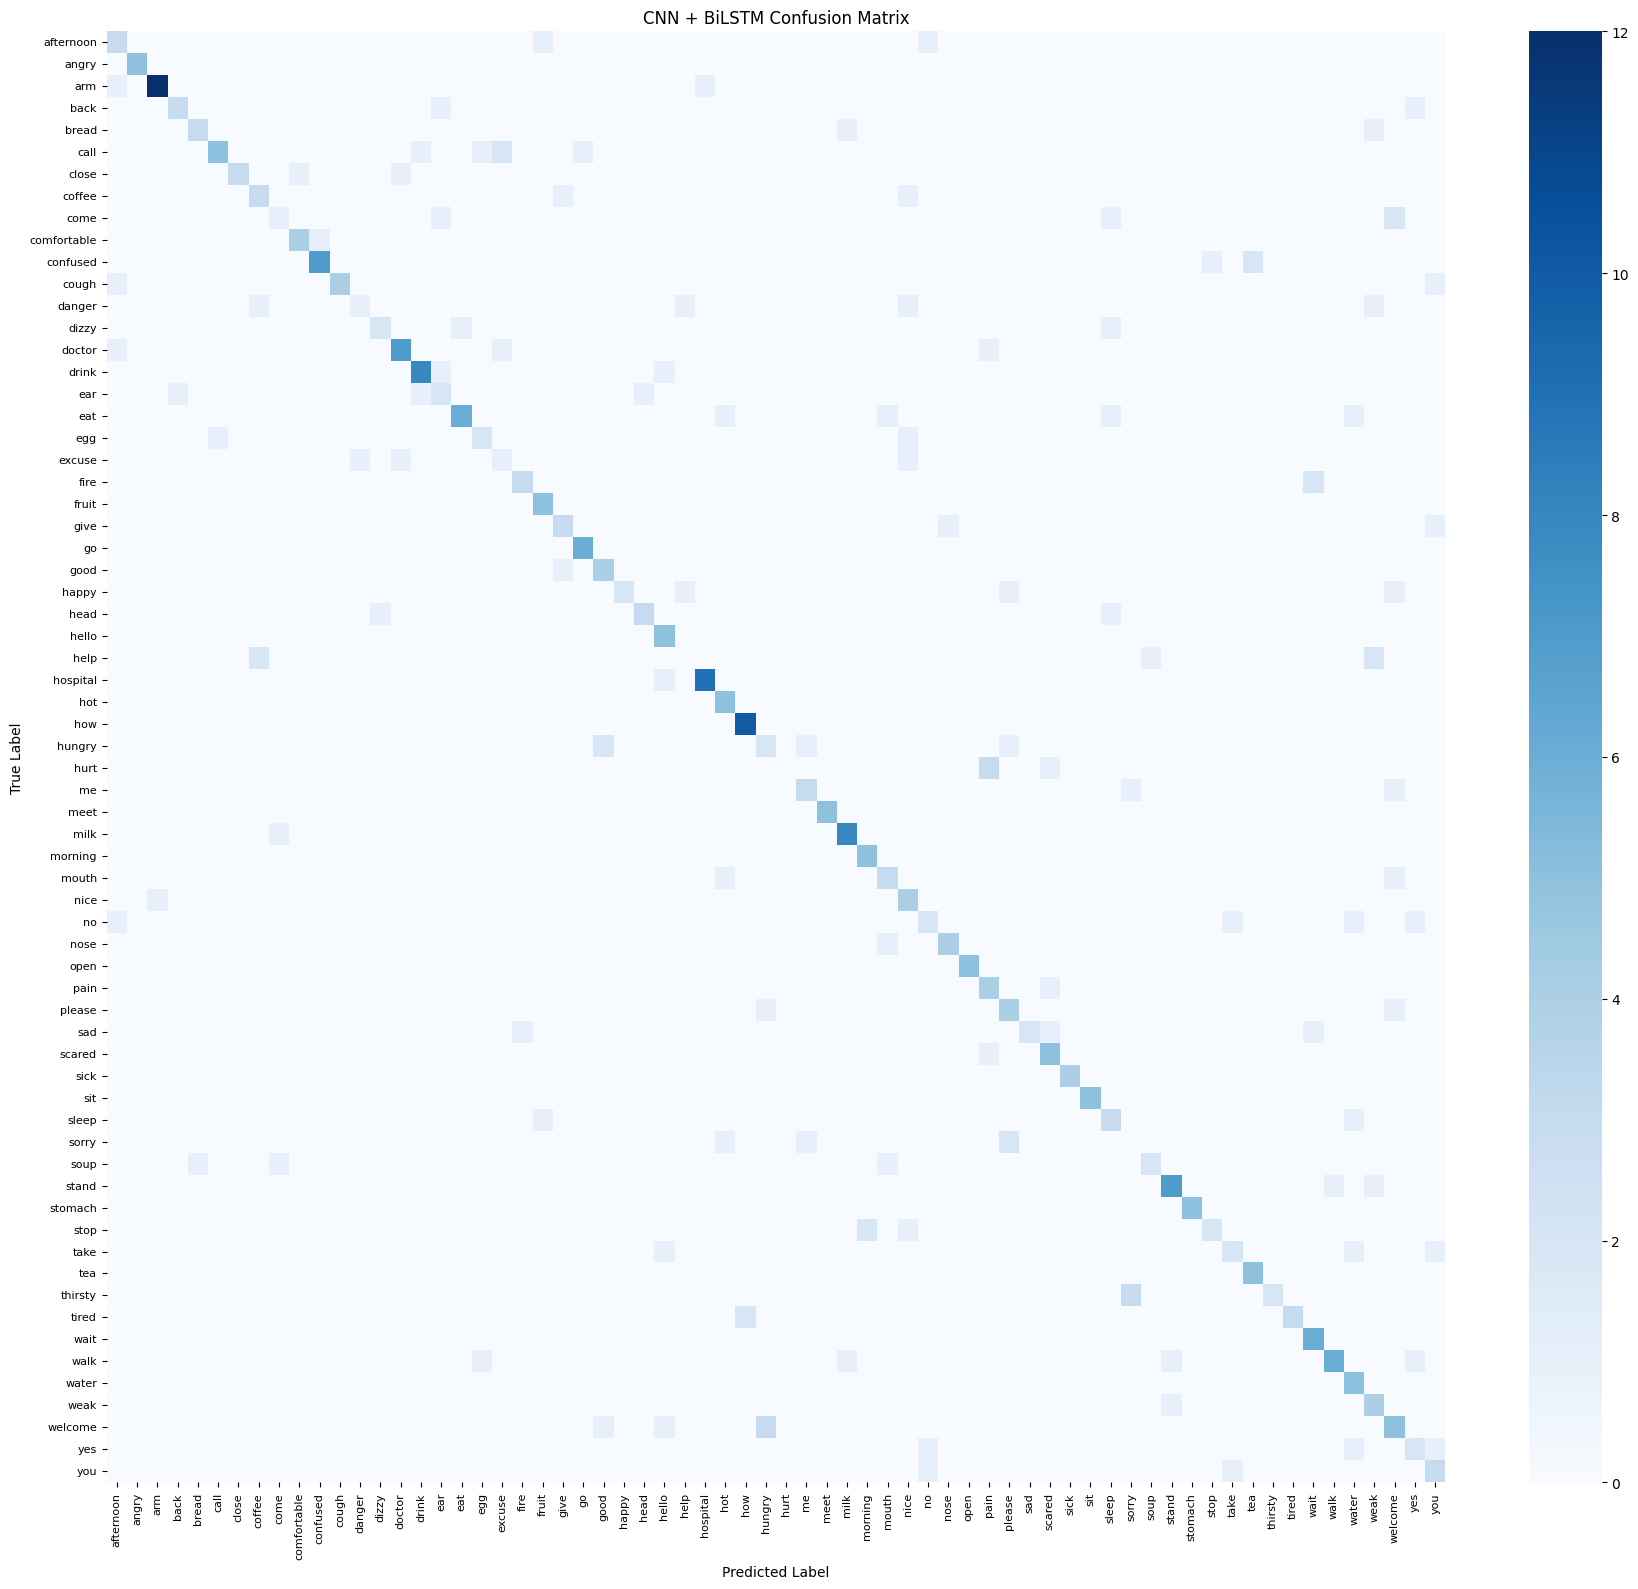

CNN + BiLSTM confusion matrix saved to:
/content/drive/MyDrive/SignLanguage_Final_DS/final_model_dataset/cnn_bilstm_confusion_matrix.png


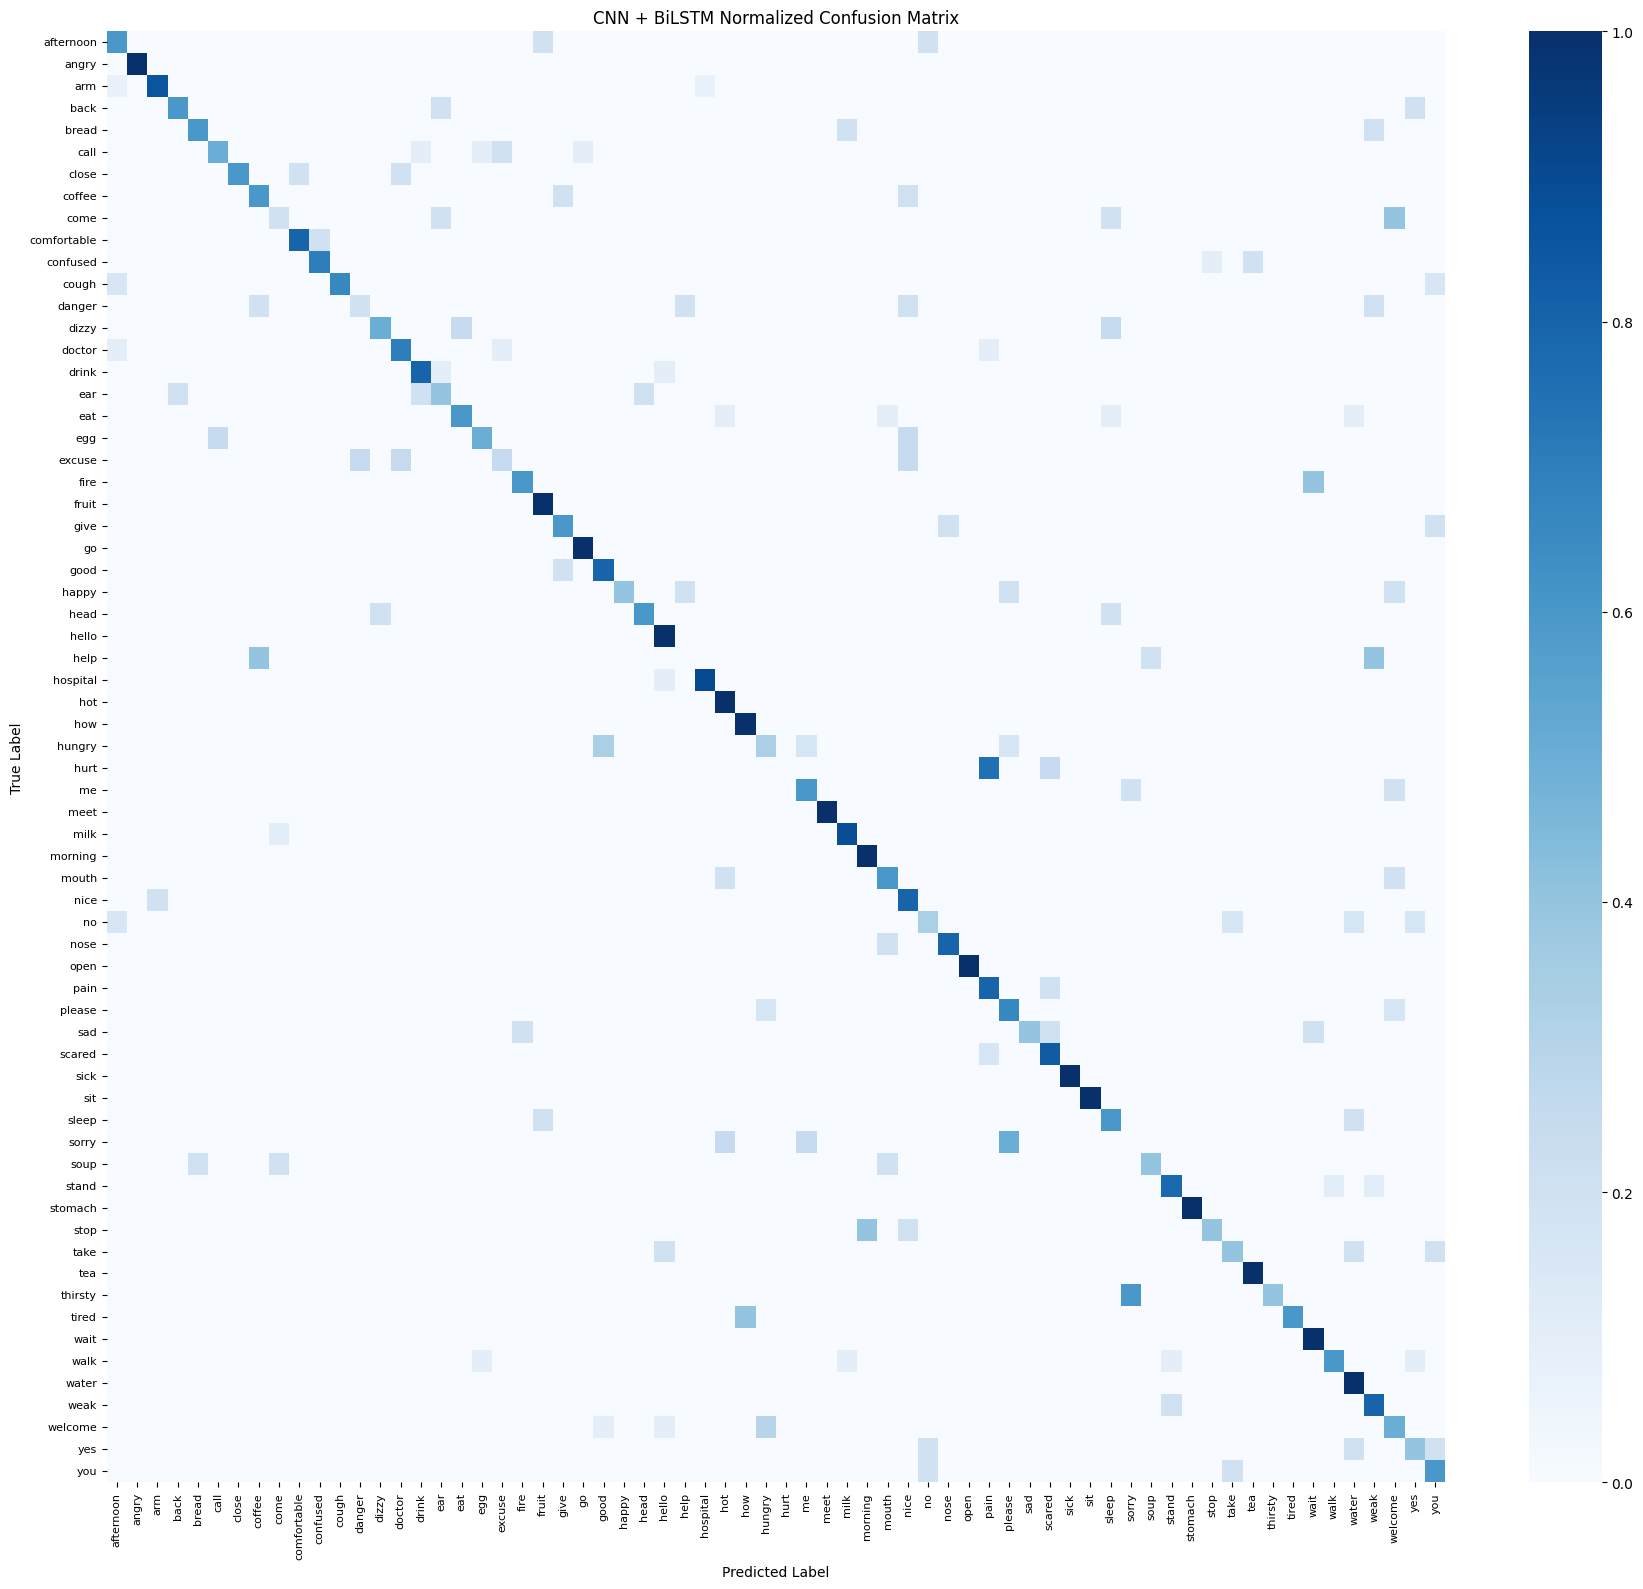

CNN + BiLSTM normalized confusion matrix saved to:
/content/drive/MyDrive/SignLanguage_Final_DS/final_model_dataset/cnn_bilstm_confusion_matrix_normalized.png


In [63]:
# ============================================================
# SECTION 19C: CNN + BiLSTM CONFUSION MATRIX
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("=" * 80)
print("CNN + BiLSTM CONFUSION MATRIX")
print("=" * 80)

cm_cnn_bilstm = confusion_matrix(
    y_test,
    y_pred_cnn_bilstm
)

cm_cnn_bilstm_norm = confusion_matrix(
    y_test,
    y_pred_cnn_bilstm,
    normalize="true"
)

# ------------------------------------------------------------
# RAW CONFUSION MATRIX
# ------------------------------------------------------------

plt.figure(figsize=(18, 16))

sns.heatmap(
    cm_cnn_bilstm,
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)

plt.title("CNN + BiLSTM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.tight_layout()

cnn_bilstm_cm_path = FINAL_DATASET_DIR / "cnn_bilstm_confusion_matrix.png"
plt.savefig(cnn_bilstm_cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("CNN + BiLSTM confusion matrix saved to:")
print(cnn_bilstm_cm_path)

# ------------------------------------------------------------
# NORMALIZED CONFUSION MATRIX
# ------------------------------------------------------------

plt.figure(figsize=(18, 16))

sns.heatmap(
    cm_cnn_bilstm_norm,
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)

plt.title("CNN + BiLSTM Normalized Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.tight_layout()

cnn_bilstm_cm_norm_path = FINAL_DATASET_DIR / "cnn_bilstm_confusion_matrix_normalized.png"
plt.savefig(cnn_bilstm_cm_norm_path, dpi=300, bbox_inches="tight")
plt.show()

print("CNN + BiLSTM normalized confusion matrix saved to:")
print(cnn_bilstm_cm_norm_path)

print("=" * 80)

# Training Curves

CNN + BiLSTM TRAINING CURVES
CNN + BiLSTM training history saved to:
/content/drive/MyDrive/SignLanguage_Final_DS/final_model_dataset/cnn_bilstm_training_history.csv


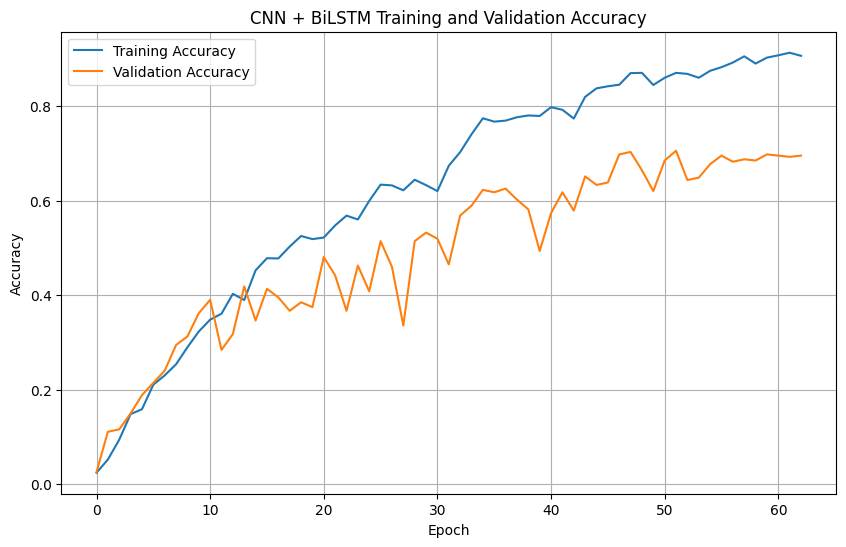

CNN + BiLSTM accuracy curve saved to:
/content/drive/MyDrive/SignLanguage_Final_DS/final_model_dataset/cnn_bilstm_accuracy_curve.png


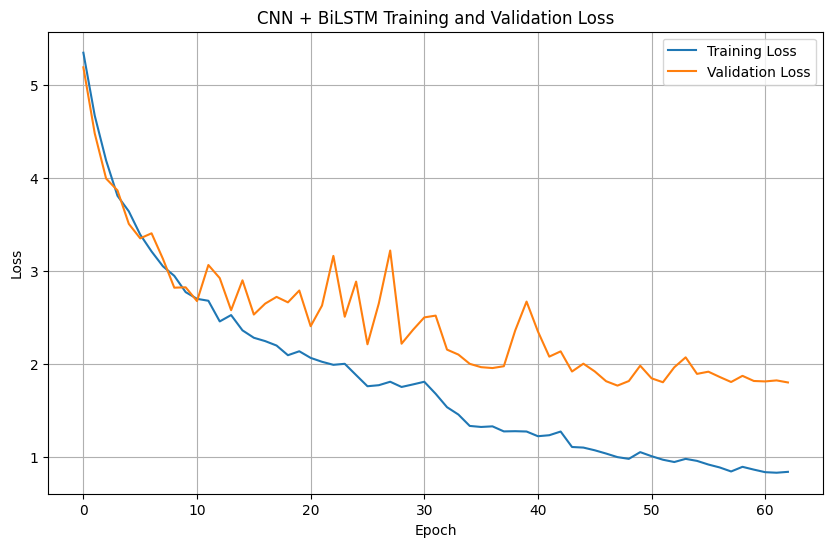

CNN + BiLSTM loss curve saved to:
/content/drive/MyDrive/SignLanguage_Final_DS/final_model_dataset/cnn_bilstm_loss_curve.png


In [64]:
# ============================================================
# SECTION 19D: CNN + BiLSTM TRAINING CURVES
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

print("=" * 80)
print("CNN + BiLSTM TRAINING CURVES")
print("=" * 80)

history_cnn_bilstm_df = pd.DataFrame(history_cnn_bilstm.history)

history_cnn_bilstm_path = FINAL_DATASET_DIR / "cnn_bilstm_training_history.csv"
history_cnn_bilstm_df.to_csv(history_cnn_bilstm_path, index=False)

print("CNN + BiLSTM training history saved to:")
print(history_cnn_bilstm_path)

# ------------------------------------------------------------
# ACCURACY CURVE
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    history_cnn_bilstm_df["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_cnn_bilstm_df["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("CNN + BiLSTM Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

cnn_bilstm_accuracy_curve_path = FINAL_DATASET_DIR / "cnn_bilstm_accuracy_curve.png"
plt.savefig(cnn_bilstm_accuracy_curve_path, dpi=300, bbox_inches="tight")
plt.show()

print("CNN + BiLSTM accuracy curve saved to:")
print(cnn_bilstm_accuracy_curve_path)

# ------------------------------------------------------------
# LOSS CURVE
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    history_cnn_bilstm_df["loss"],
    label="Training Loss"
)

plt.plot(
    history_cnn_bilstm_df["val_loss"],
    label="Validation Loss"
)

plt.title("CNN + BiLSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

cnn_bilstm_loss_curve_path = FINAL_DATASET_DIR / "cnn_bilstm_loss_curve.png"
plt.savefig(cnn_bilstm_loss_curve_path, dpi=300, bbox_inches="tight")
plt.show()

print("CNN + BiLSTM loss curve saved to:")
print(cnn_bilstm_loss_curve_path)

print("=" * 80)

# Final Model Comparison

In [65]:
# ============================================================
# SECTION 20A: FINAL MODEL COMPARISON
# ============================================================

import pandas as pd

print("=" * 80)
print("FINAL MODEL COMPARISON")
print("=" * 80)

# ------------------------------------------------------------
# MODEL RESULTS
# ------------------------------------------------------------

model_results = {
    "Model": [
        "BiLSTM",
        "GRU",
        "CNN + BiLSTM",
        "ST-GCN"
    ],

    "Test Accuracy": [
        0.6158,
        0.7150,
        0.6718,
        None
    ],

    "Macro F1-score": [
        0.6049,
        0.7072,
        0.6372,
        None
    ],

    "Remarks": [
        "Baseline temporal model",
        "Best overall performance",
        "Improved feature extraction but more overfitting",
        "Graph-based comparison model"
    ]
}

comparison_df = pd.DataFrame(model_results)

print(comparison_df)

# ------------------------------------------------------------
# SAVE MODEL COMPARISON
# ------------------------------------------------------------

comparison_csv_path = FINAL_DATASET_DIR / "final_model_comparison.csv"

comparison_df.to_csv(
    comparison_csv_path,
    index=False
)

print("\nModel comparison table saved to:")
print(comparison_csv_path)

print("=" * 80)

# ------------------------------------------------------------
# FINAL MODEL SELECTION
# ------------------------------------------------------------

print("\nFINAL MODEL SELECTION")
print("-" * 50)

print("""
Selected Final Model: GRU

Reasons:
- Highest test accuracy
- Highest Macro F1-score
- Better generalization performance
- Lower overfitting compared to CNN + BiLSTM
- Faster and more efficient than larger architectures
- Most suitable for real-time deployment

Final System Pipeline:
MediaPipe Landmark Extraction
        ↓
Normalization + Feature Engineering
        ↓
GRU Sign Recognition
        ↓
DTW Gesture Quality Evaluation
        ↓
Explainable Corrective Feedback
""")

print("=" * 80)

FINAL MODEL COMPARISON
          Model  Test Accuracy  Macro F1-score  \
0        BiLSTM         0.6158          0.6049   
1           GRU         0.7150          0.7072   
2  CNN + BiLSTM         0.6718          0.6372   
3        ST-GCN            NaN             NaN   

                                            Remarks  
0                           Baseline temporal model  
1                          Best overall performance  
2  Improved feature extraction but more overfitting  
3                      Graph-based comparison model  

Model comparison table saved to:
/content/drive/MyDrive/SignLanguage_Final_DS/final_model_dataset/final_model_comparison.csv

FINAL MODEL SELECTION
--------------------------------------------------

Selected Final Model: GRU

Reasons:
- Highest test accuracy
- Highest Macro F1-score
- Better generalization performance
- Lower overfitting compared to CNN + BiLSTM
- Faster and more efficient than larger architectures
- Most suitable for real-time deplo

# Export Final GRU Model

In [66]:
# ============================================================
# SECTION 21A: EXPORT FINAL GRU MODEL FOR BACKEND INFERENCE
# ============================================================

import shutil
import json
import numpy as np
from pathlib import Path
import tensorflow as tf

print("=" * 80)
print("EXPORT FINAL GRU MODEL FOR BACKEND")
print("=" * 80)

# ------------------------------------------------------------
# EXPORT DIRECTORY
# ------------------------------------------------------------

EXPORT_DIR = BASE_DIR / "backend_export"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print("Export folder:")
print(EXPORT_DIR)

# ------------------------------------------------------------
# COPY FINAL GRU MODEL
# ------------------------------------------------------------

source_gru_model = MODEL_SAVE_DIR / "gru_best_model.keras"
export_gru_model = EXPORT_DIR / "gru_best_model.keras"

shutil.copy(source_gru_model, export_gru_model)

print("\nGRU model exported to:")
print(export_gru_model)

# ------------------------------------------------------------
# COPY LABEL MAPPINGS
# ------------------------------------------------------------

label_to_id_src = METADATA_DIR / "label_to_id.json"
id_to_label_src = METADATA_DIR / "id_to_label.json"

label_to_id_dst = EXPORT_DIR / "label_to_id.json"
id_to_label_dst = EXPORT_DIR / "id_to_label.json"

shutil.copy(label_to_id_src, label_to_id_dst)
shutil.copy(id_to_label_src, id_to_label_dst)

print("\nLabel mappings exported.")

# ------------------------------------------------------------
# SAVE PREPROCESSING CONFIG
# ------------------------------------------------------------

preprocessing_config = {
    "target_frames": 40,
    "raw_feature_size": 258,
    "enhanced_feature_size": 774,
    "pose_landmarks": 33,
    "hand_landmarks_each": 21,
    "total_classes": 66,
    "normalization": "shoulder_center_and_shoulder_width",
    "features": [
        "position",
        "velocity",
        "acceleration"
    ],
    "final_model": "GRU",
    "input_shape": [40, 774]
}

config_path = EXPORT_DIR / "preprocessing_config.json"

with open(config_path, "w") as f:
    json.dump(preprocessing_config, f, indent=4)

print("\nPreprocessing config saved to:")
print(config_path)

# ------------------------------------------------------------
# SAVE MODEL SUMMARY
# ------------------------------------------------------------

summary_path = EXPORT_DIR / "final_model_summary.txt"

with open(summary_path, "w") as f:
    f.write("Final Selected Model: GRU\n")
    f.write("=" * 80 + "\n\n")
    f.write("Reason for selection:\n")
    f.write("- Highest test accuracy\n")
    f.write("- Highest Macro F1-score\n")
    f.write("- Better generalization than CNN + BiLSTM\n")
    f.write("- More efficient for real-time deployment\n\n")
    f.write("Performance:\n")
    f.write("BiLSTM Test Accuracy: 0.6158\n")
    f.write("GRU Test Accuracy: 0.7150\n")
    f.write("CNN + BiLSTM Test Accuracy: 0.6718\n\n")
    f.write("Final pipeline:\n")
    f.write("MediaPipe landmarks -> preprocessing -> GRU prediction -> DTW feedback\n")

print("\nModel summary saved to:")
print(summary_path)

print("=" * 80)
print("Backend export completed successfully.")
print("=" * 80)

EXPORT FINAL GRU MODEL FOR BACKEND
Export folder:
/content/drive/MyDrive/SignLanguage_Final_DS/backend_export

GRU model exported to:
/content/drive/MyDrive/SignLanguage_Final_DS/backend_export/gru_best_model.keras

Label mappings exported.

Preprocessing config saved to:
/content/drive/MyDrive/SignLanguage_Final_DS/backend_export/preprocessing_config.json

Model summary saved to:
/content/drive/MyDrive/SignLanguage_Final_DS/backend_export/final_model_summary.txt
Backend export completed successfully.


# Export DTW

In [67]:
# ============================================================
# SECTION 21B: EXPORT DTW FEEDBACK UTILITIES
# ============================================================

dtw_utils_code = r'''
import numpy as np
from scipy.spatial.distance import euclidean

def dtw_distance(seq1, seq2):
    n, m = len(seq1), len(seq2)

    dtw = np.full((n + 1, m + 1), np.inf)
    dtw[0, 0] = 0

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = euclidean(seq1[i - 1], seq2[j - 1])
            dtw[i, j] = cost + min(
                dtw[i - 1, j],
                dtw[i, j - 1],
                dtw[i - 1, j - 1]
            )

    return float(dtw[n, m] / (n + m))


def calibrated_dtw_score(distance):
    good_distance = 8.0
    bad_distance = 11.0

    x = (distance - good_distance) / (bad_distance - good_distance)
    x = max(0, min(1, x))

    score = 100 - (x * 100)

    return float(round(score, 2))


def interpret_dtw_score(score):
    if score >= 85:
        return "Excellent", "Gesture closely matches the reference."
    elif score >= 70:
        return "Good", "Gesture is mostly accurate with minor adjustments needed."
    elif score >= 50:
        return "Acceptable", "Gesture is understandable but needs improvement."
    else:
        return "Needs Improvement", "Gesture differs noticeably from the reference."


def compute_hand_motion_strength(seq):
    left_velocity = seq[:, 126:189]
    right_velocity = seq[:, 189:252]

    left_motion = np.mean(np.linalg.norm(left_velocity, axis=1))
    right_motion = np.mean(np.linalg.norm(right_velocity, axis=1))

    return left_motion, right_motion


def compute_hand_position_error(reference_seq, learner_seq):
    ref_left = reference_seq[:, 0:63]
    ref_right = reference_seq[:, 63:126]

    learner_left = learner_seq[:, 0:63]
    learner_right = learner_seq[:, 63:126]

    left_error = np.mean(np.linalg.norm(ref_left - learner_left, axis=1))
    right_error = np.mean(np.linalg.norm(ref_right - learner_right, axis=1))

    return left_error, right_error


def generate_dtw_feedback(reference_seq, learner_seq):
    distance = dtw_distance(reference_seq, learner_seq)
    score = calibrated_dtw_score(distance)

    band, base_feedback = interpret_dtw_score(score)

    feedback = [base_feedback]

    ref_left_motion, ref_right_motion = compute_hand_motion_strength(reference_seq)
    learner_left_motion, learner_right_motion = compute_hand_motion_strength(learner_seq)

    left_error, right_error = compute_hand_position_error(reference_seq, learner_seq)

    left_ratio = learner_left_motion / (ref_left_motion + 1e-6)
    right_ratio = learner_right_motion / (ref_right_motion + 1e-6)

    if left_ratio < 0.75:
        feedback.append("Left hand movement is too limited or slow.")
    elif left_ratio > 1.25:
        feedback.append("Left hand movement is too exaggerated or fast.")

    if right_ratio < 0.75:
        feedback.append("Right hand movement is too limited or slow.")
    elif right_ratio > 1.25:
        feedback.append("Right hand movement is too exaggerated or fast.")

    if left_error > 8:
        feedback.append("Left hand position differs from the reference.")

    if right_error > 8:
        feedback.append("Right hand position differs from the reference.")

    return {
        "distance": float(round(distance, 4)),
        "score": float(score),
        "band": band,
        "feedback": feedback
    }
'''

dtw_utils_path = EXPORT_DIR / "dtw_feedback_utils.py"

with open(dtw_utils_path, "w") as f:
    f.write(dtw_utils_code)

print("DTW feedback utilities exported to:")
print(dtw_utils_path)

DTW feedback utilities exported to:
/content/drive/MyDrive/SignLanguage_Final_DS/backend_export/dtw_feedback_utils.py
